# Modeling - Dự báo doanh thu daily

## Mục tiêu

- Chuẩn bị notebook modeling cho bài toán dự báo doanh thu theo ngày.
- Phase 0-2 setup, chốt bài toán và tạo bảng modeling sạch.
- Phase 3 chia train/validation/test theo thời gian.
- Phase 4 xây baseline đơn giản để làm mốc so sánh.
- Phase 5 train model ML đầu tiên và so sánh với baseline.
- Phase 6 chốt metric chính và phân tích sai số validation.
- Phase 7 phân tích lỗi của best model trên validation.
- Phase 8 giải thích best model bằng feature importance.
- Phase 9 cải thiện model có kiểm soát trên validation.
- Phase 10 chọn model cuối và đánh giá một lần trên test.
- Phase 11 chuẩn bị bảng và biểu đồ cho báo cáo model.

## Quy trình hiện tại

- Phase 0: setup và load output từ feature engineering.
- Phase 1: chốt target, grain, feature và kế hoạch split.
- Phase 2: tạo bảng modeling sạch, kiểm tra duplicate, missing, date continuity và leakage.
- Phase 3: chia train, validation, test và kiểm tra chất lượng split.
- Phase 4: xây baseline model và so sánh metric.
- Phase 5: train model ML lần đầu trên train và đánh giá trên validation.
- Phase 6: chốt WAPE làm metric chính và phân tích metric theo tháng.
- Phase 7: phân tích top lỗi, lỗi theo tháng, weekday, nhóm doanh thu và feature bất thường.
- Phase 8: giải thích model bằng feature importance và kiểm tra rủi ro leakage.
- Phase 9: tuning model có kiểm soát, không dùng test để chọn model.
- Phase 10: train lại model cuối trên train + validation và đánh giá test một lần.
- Phase 11: tổng hợp kết quả thành bảng và biểu đồ dùng cho báo cáo.


## Phase 0 - Setup

### Mục tiêu

- Import thư viện cơ bản.
- Khai báo đường dẫn input/output.
- Load các file bàn giao từ feature engineering.


In [1]:
# Phase 0 - Cell 1 - Setup thư viện và đường dẫn
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
#from sklearn.metrics import 

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

DATE_COL = 'Date' 
TARGET_COL = 'Revenue' 
COGS_COL = 'COGS'
TARGET_COLS = [TARGET_COL, COGS_COL]
RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'report_5_6_2026').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

FE_TABLE_DIR = PROJECT_ROOT / 'report_5_6_2026' / 'fe_outputs' / 'tables'
MODEL_TABLE_DIR = PROJECT_ROOT / 'report_8_6_2026' / 'model_outputs' / 'tables'
MODEL_FIG_DIR = PROJECT_ROOT / 'report_8_6_2026' / 'model_outputs' / 'figures'
MODEL_TABLE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_FIG_DIR.mkdir(parents=True, exist_ok=True)

input_files = {
    'modeling_dataset': FE_TABLE_DIR / 'modeling_dataset_final.csv',
    'final_feature_list': FE_TABLE_DIR / 'final_feature_list.csv',
    'final_feature_scores': FE_TABLE_DIR / 'final_feature_scores.csv',
    'modeling_feature_metadata': FE_TABLE_DIR / 'modeling_feature_metadata.csv',
    'feature_selection_summary': FE_TABLE_DIR / 'feature_selection_summary.csv',
}

path_check = pd.DataFrame({
    'file': input_files.keys(),
    'exists': [path.exists() for path in input_files.values()],
    'path': [str(path) for path in input_files.values()],
})

print(path_check.to_string(index=False))


                     file  exists                                                                                        path
         modeling_dataset    True    B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\modeling_dataset_final.csv
       final_feature_list    True        B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\final_feature_list.csv
     final_feature_scores    True      B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\final_feature_scores.csv
modeling_feature_metadata    True B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\modeling_feature_metadata.csv
feature_selection_summary    True B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\feature_selection_summary.csv


In [2]:
# Phase 0 - Cell 2 - Load dữ liệu từ feature engineering
assert path_check['exists'].all(), 'Có file input từ feature engineering đang bị thiếu.'

modeling_dataset_raw = pd.read_csv(input_files['modeling_dataset'], parse_dates=[DATE_COL])
final_feature_list = pd.read_csv(input_files['final_feature_list'])
final_feature_scores = pd.read_csv(input_files['final_feature_scores'])
modeling_feature_metadata = pd.read_csv(input_files['modeling_feature_metadata'])
feature_selection_summary = pd.read_csv(input_files['feature_selection_summary'])

load_summary = pd.DataFrame({
    'table': ['modeling_dataset_raw', 'final_feature_list', 'final_feature_scores', 'modeling_feature_metadata', 'feature_selection_summary'],
    'rows': [len(modeling_dataset_raw), len(final_feature_list), len(final_feature_scores), len(modeling_feature_metadata), len(feature_selection_summary)],
    'columns': [modeling_dataset_raw.shape[1], final_feature_list.shape[1], final_feature_scores.shape[1], modeling_feature_metadata.shape[1], feature_selection_summary.shape[1]],
})

print(load_summary.to_string(index=False))
print(modeling_dataset_raw.head().to_string(index=False))


                    table  rows  columns
     modeling_dataset_raw  3833       24
       final_feature_list    21        2
     final_feature_scores    21       38
modeling_feature_metadata    21        9
feature_selection_summary     7        3
      Date    Revenue       COGS  Gross_Profit_rolling_7d_mean  Gross_Margin_rolling_7d_mean  Revenue_rolling_28d_mean  Revenue_lag_1d  Revenue_pct_change_7d  page_views_lag_14d  cos_month  Gross_Profit_rolling_28d_mean  year  is_month_start  Revenue_rolling_7d_mean  Gross_Margin_rolling_28d_mean  Gross_Margin_lag_7d  Gross_Margin_lag_1d  Gross_Profit_lag_1d  Revenue_diff_1d  is_month_end  day_of_month  Gross_Profit_lag_7d  Revenue_lag_28d  quarter
2012-07-04 5123547.94 3982991.19                           NaN                           NaN                       NaN             NaN                    NaN                 NaN  -0.866025                            NaN  2012               0                      NaN                            NaN    

## Kết luận Phase 0

- Notebook đã setup môi trường modeling và load được các input từ bước feature engineering.
- Đây là bước chuẩn bị, chưa đánh giá model hay thay đổi dữ liệu.
- Sau Phase 0, các bảng dữ liệu, metadata feature và cấu hình đường dẫn đã sẵn sàng cho các phase tiếp theo.


## Phase 1 - Chốt bài toán model

### Mục tiêu

- Bài toán là dự đoán doanh thu (sử dụng phương pháp regression).
- Target là `Revenue` theo ngày.
- Grain là **1 dòng = 1 ngày**.
- Feature được lấy từ kết quả thu được trong quá trình feature engineering.
- Xác định khoảng thời gian trên train/ test


In [3]:
#  Chốt target, feature và kế hoạch split
selected_features = final_feature_list.sort_values('selected_order')['feature'].tolist()

problem_definition = pd.DataFrame([
    {'item': 'business_goal', 'value': 'Dự báo doanh thu theo ngày'},
    {'item': 'problem_type', 'value': 'Regression'},
    {'item': 'target', 'value': TARGET_COL},
    {'item': 'grain', 'value': '1 dòng = 1 ngày'},
    {'item': 'selected_feature_count', 'value': len(selected_features)},
])

feature_group_summary = (
    final_feature_scores
    .groupby(['source_table', 'family', 'type'], dropna=False)
    .agg(
        feature_count=('feature', 'nunique'),
        avg_missing_pct=('missing_pct', 'mean'),
        avg_abs_corr_target=('max_abs_spearman', 'mean'),
    )
    .reset_index()
    .sort_values(['source_table', 'feature_count', 'family'], ascending=[True, False, True])
)

split_plan = pd.DataFrame([
    {'dataset': 'train', 'start_date': '2012-07-04', 'end_date': '2020-11-24'},
    {'dataset': 'validation', 'start_date': '2020-11-25', 'end_date': '2021-12-12'},
    {'dataset': 'test', 'start_date': '2021-12-13', 'end_date': '2022-12-31'},
])
split_plan['note'] = 'Chỉ là kế hoạch, chưa split ở Phase 0-2'

problem_definition.to_csv(MODEL_TABLE_DIR / 'phase1_problem_definition.csv', index=False, encoding='utf-8-sig')
feature_group_summary.to_csv(MODEL_TABLE_DIR / 'phase1_feature_group_summary.csv', index=False, encoding='utf-8-sig')
split_plan.to_csv(MODEL_TABLE_DIR / 'phase1_split_plan.csv', index=False, encoding='utf-8-sig')

print("Thông tin cơ bản về dữ liệu")
print(problem_definition.to_string(index=False))
print("\ntóm tắt thông tin về dữ liệu")
print(feature_group_summary.to_string(index=False))
print("\nMốc thời gian dự kiến cho huấn luyện và đánh giá dữ liệu")
print(split_plan.to_string(index=False))


Thông tin cơ bản về dữ liệu
                  item                      value
         business_goal Dự báo doanh thu theo ngày
          problem_type                 Regression
                target                    Revenue
                 grain            1 dòng = 1 ngày
selected_feature_count                         21

tóm tắt thông tin về dữ liệu
source_table         family     type  feature_count  avg_missing_pct  avg_abs_corr_target
        Date      cos_month calendar              1            0.000             0.541619
        Date   day_of_month calendar              1            0.000             0.303698
        Date   is_month_end calendar              1            0.000             0.150929
        Date is_month_start calendar              1            0.000             0.109133
        Date        quarter calendar              1            0.000             0.248234
        Date           year calendar              1            0.000             0.340973
       sales

In [4]:
# Kiểm tra feature list có khớp bảng điểm và metadata không
feature_check = pd.DataFrame([
    {'check': 'feature_list_count', 'value': len(selected_features)},
    {'check': 'feature_scores_count', 'value': final_feature_scores['feature'].nunique()},
    {'check': 'metadata_count', 'value': modeling_feature_metadata['feature'].nunique()},
    {'check': 'missing_in_scores', 'value': len(set(selected_features) - set(final_feature_scores['feature']))},
    {'check': 'missing_in_metadata', 'value': len(set(selected_features) - set(modeling_feature_metadata['feature']))},
])

assert len(selected_features) == 21, 'Số feature cuối phải là 21.'
assert set(selected_features) <= set(final_feature_scores['feature']), 'Có feature thiếu trong final_feature_scores.'
assert set(selected_features) <= set(modeling_feature_metadata['feature']), 'Có feature thiếu trong modeling_feature_metadata.'
print("Kiểm tra feature có đủ số lượng, missing\n")
print(feature_check.to_string(index=False))
review_cols = ['selected_order', 'feature', 'source_table', 'type', 'leakage_risk', 'stable_flag']
print("Thông tin chi tiết về feature")
print(final_feature_scores.sort_values('selected_order')[review_cols].to_string(index=False))


Kiểm tra feature có đủ số lượng, missing

               check  value
  feature_list_count     21
feature_scores_count     21
      metadata_count     21
   missing_in_scores      0
 missing_in_metadata      0
Thông tin chi tiết về feature
 selected_order                       feature source_table     type   leakage_risk stable_flag
            1.0  Gross_Profit_rolling_7d_mean        sales  rolling low if shifted        PASS
            2.0  Gross_Margin_rolling_7d_mean        sales  rolling low if shifted        PASS
            3.0      Revenue_rolling_28d_mean        sales  rolling low if shifted        PASS
            4.0                Revenue_lag_1d        sales      lag low if shifted        PASS
            5.0         Revenue_pct_change_7d        sales   change low if shifted        PASS
            6.0            page_views_lag_14d  web_traffic      lag  low if lagged        PASS
            7.0                     cos_month         Date calendar  low known-now        PASS


## Kết luận Phase 1

- Bài toán được xác định là **Regression**: dự báo giá trị số liên tục.
- Target cần dự báo là **`Revenue`**.
- Grain của bảng model là **1 dòng = 1 ngày**.
- Bộ feature ban đầu có **21 selected features**.
- Ý nghĩa: từ phase này trở đi, toàn bộ notebook tập trung vào dự báo doanh thu hằng ngày, không phải dự báo theo đơn hàng hay theo tháng.


## Phase 2 - Chuẩn bị dữ liệu modeling

### Mục tiêu

- Tạo `model_df` gồm Target và feature.
- Kiểm tra duplicate, missing, date continuity và leakage (nếu cần thì xử lý)
- Kiểm tra thời gian của dữ liệu có bị gãy không.


In [5]:
# Tạo model_df
model_columns = [DATE_COL] + TARGET_COLS + selected_features
missing_columns = [col for col in model_columns if col not in modeling_dataset_raw.columns]
assert not missing_columns, f'Thiếu cột trong modeling_dataset_final.csv: {missing_columns}'

model_df = modeling_dataset_raw[model_columns].copy()
model_df[DATE_COL] = pd.to_datetime(model_df[DATE_COL]).dt.normalize()
model_df = model_df.sort_values(DATE_COL).reset_index(drop=True)

for col in TARGET_COLS + selected_features:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df.to_csv(MODEL_TABLE_DIR / 'phase2_modeling_table.csv', index=False, encoding='utf-8-sig')

print(model_df.head().to_string(index=False))


      Date    Revenue       COGS  Gross_Profit_rolling_7d_mean  Gross_Margin_rolling_7d_mean  Revenue_rolling_28d_mean  Revenue_lag_1d  Revenue_pct_change_7d  page_views_lag_14d  cos_month  Gross_Profit_rolling_28d_mean  year  is_month_start  Revenue_rolling_7d_mean  Gross_Margin_rolling_28d_mean  Gross_Margin_lag_7d  Gross_Margin_lag_1d  Gross_Profit_lag_1d  Revenue_diff_1d  is_month_end  day_of_month  Gross_Profit_lag_7d  Revenue_lag_28d  quarter
2012-07-04 5123547.94 3982991.19                           NaN                           NaN                       NaN             NaN                    NaN                 NaN  -0.866025                            NaN  2012               0                      NaN                            NaN                  NaN                  NaN                  NaN              NaN             0             4                  NaN              NaN        3
2012-07-05 2751773.45 2150580.23                  1.140557e+06                      0.222611  

In [6]:
# Khám phá dữ liệu 
date_count = model_df.groupby(DATE_COL).size().reset_index(name='row_count')
duplicate_dates = date_count[date_count['row_count'] > 1]
expected_dates = pd.date_range(model_df[DATE_COL].min(), model_df[DATE_COL].max(), freq='D')
missing_dates = pd.Index(expected_dates).difference(pd.Index(model_df[DATE_COL]))

quality_report = pd.DataFrame([
    {'metric': 'row_count', 'value': len(model_df)},
    {'metric': 'column_count', 'value': model_df.shape[1]},
    {'metric': 'selected_feature_count', 'value': len(selected_features)},
    {'metric': 'min_date', 'value': model_df[DATE_COL].min()},
    {'metric': 'max_date', 'value': model_df[DATE_COL].max()},
    {'metric': 'unique_dates', 'value': model_df[DATE_COL].nunique()},
    {'metric': 'duplicate_date_count', 'value': len(duplicate_dates)},
    {'metric': 'missing_calendar_dates', 'value': len(missing_dates)},
    {'metric': 'target_missing_rows', 'value': model_df[TARGET_COL].isna().sum()},
    {'metric': 'target_negative_rows', 'value': (model_df[TARGET_COL] < 0).sum()},
    {'metric': 'feature_missing_cells', 'value': model_df[selected_features].isna().sum().sum()},
])

quality_report.to_csv(MODEL_TABLE_DIR / 'phase2_quality_report.csv', index=False, encoding='utf-8-sig')
print(quality_report.to_string(index=False))
print(duplicate_dates.head().to_string(index=False))


                metric               value
             row_count                3833
          column_count                  24
selected_feature_count                  21
              min_date 2012-07-04 00:00:00
              max_date 2022-12-31 00:00:00
          unique_dates                3833
  duplicate_date_count                   0
missing_calendar_dates                   0
   target_missing_rows                   0
  target_negative_rows                   0
 feature_missing_cells                 255
Empty DataFrame
Columns: [Date, row_count]
Index: []


In [7]:
# Kiểm tra date 
date_continuity_report = pd.DataFrame([
    {'metric': 'expected_daily_dates', 'value': len(expected_dates)},
    {'metric': 'actual_unique_dates', 'value': model_df[DATE_COL].nunique()},
    {'metric': 'missing_calendar_dates', 'value': len(missing_dates)},
    {'metric': 'first_missing_date', 'value': missing_dates.min() if len(missing_dates) else pd.NaT},
    {'metric': 'last_missing_date', 'value': missing_dates.max() if len(missing_dates) else pd.NaT},
])

date_continuity_report.to_csv(MODEL_TABLE_DIR / 'phase2_date_continuity_report.csv', index=False, encoding='utf-8-sig')
print(date_continuity_report.to_string(index=False))


                metric value
  expected_daily_dates  3833
   actual_unique_dates  3833
missing_calendar_dates     0
    first_missing_date   NaT
     last_missing_date   NaT


In [8]:
# check missing của feature
missing_feature_report = pd.DataFrame({
    'feature': selected_features,
    'missing_count': [model_df[col].isna().sum() for col in selected_features],
    'missing_pct': [model_df[col].isna().mean() * 100 for col in selected_features],
    'nunique': [model_df[col].nunique(dropna=True) for col in selected_features],
    'dtype': [str(model_df[col].dtype) for col in selected_features],
}).sort_values('missing_pct', ascending=False).reset_index(drop=True)

missing_feature_report.to_csv(MODEL_TABLE_DIR / 'phase2_missing_feature_report.csv', index=False, encoding='utf-8-sig')
print(missing_feature_report.to_string(index=False))


                      feature  missing_count  missing_pct  nunique   dtype
           page_views_lag_14d            195     5.087399     3606 float64
              Revenue_lag_28d             28     0.730498     3805 float64
          Gross_Profit_lag_7d              7     0.182625     3826 float64
          Gross_Margin_lag_7d              7     0.182625     3826 float64
        Revenue_pct_change_7d              7     0.182625     3826 float64
              Revenue_diff_1d              2     0.052178     3831 float64
     Revenue_rolling_28d_mean              1     0.026089     3832 float64
 Gross_Margin_rolling_7d_mean              1     0.026089     3832 float64
 Gross_Profit_rolling_7d_mean              1     0.026089     3832 float64
               Revenue_lag_1d              1     0.026089     3832 float64
Gross_Margin_rolling_28d_mean              1     0.026089     3832 float64
      Revenue_rolling_7d_mean              1     0.026089     3832 float64
Gross_Profit_rolling_28d_

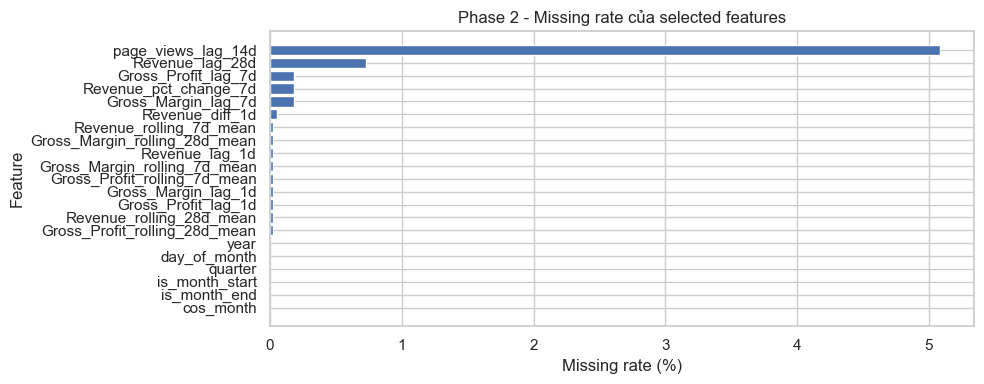

In [9]:
# Biểu đồ missing rate của feature
fig, ax = plt.subplots(figsize=(10, 4))
plot_missing = missing_feature_report.sort_values('missing_pct', ascending=True)
ax.barh(plot_missing['feature'], plot_missing['missing_pct'])
ax.set_title('Phase 2 - Missing rate của selected features')
ax.set_xlabel('Missing rate (%)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase2_selected_feature_missing_rate.png', dpi=150)
plt.show()


In [10]:
# Xử lý missing sau khi đã xem lý do thiếu

model_df_before_missing = model_df.copy()

rows_before = len(model_df)
missing_mask = model_df[selected_features].isna().any(axis=1)

dropped_missing_rows = model_df.loc[missing_mask, [DATE_COL, TARGET_COL] + selected_features].copy()
model_df = model_df.loc[~missing_mask].copy()

rows_after = len(model_df)

missing_handling_report = pd.DataFrame([
    {'metric': 'rows_before_missing_handling', 'value': rows_before},
    {'metric': 'rows_dropped_due_to_missing_feature', 'value': missing_mask.sum()},
    {'metric': 'rows_after_missing_handling', 'value': rows_after},
    {'metric': 'missing_values_after_handling', 'value': model_df[selected_features].isna().sum().sum()},
    {'metric': 'first_date_after_handling', 'value': model_df[DATE_COL].min()},
    {'metric': 'last_date_after_handling', 'value': model_df[DATE_COL].max()},
])

missing_handling_report.to_csv(MODEL_TABLE_DIR / 'phase2_missing_handling_report.csv', index=False, encoding='utf-8-sig')
dropped_missing_rows.to_csv(MODEL_TABLE_DIR / 'phase2_dropped_missing_rows.csv', index=False, encoding='utf-8-sig')

model_df.to_csv(MODEL_TABLE_DIR / 'phase2_modeling_table.csv', index=False, encoding='utf-8-sig')

print(missing_handling_report.to_string(index=False))
print('model_df shape:', model_df.shape)

                             metric               value
       rows_before_missing_handling                3833
rows_dropped_due_to_missing_feature                 195
        rows_after_missing_handling                3638
      missing_values_after_handling                   0
          first_date_after_handling 2013-01-15 00:00:00
           last_date_after_handling 2022-12-31 00:00:00
model_df shape: (3638, 24)


In [11]:
#  Kiểm tra leakage theo metadata
history_tokens = ['lag', 'rolling', 'diff', 'pct_change']
target_like_words = ['Revenue', 'COGS', 'Gross_Profit', 'Gross_Margin']

leakage_review = final_feature_scores[[
    'selected_order', 'feature', 'source_table', 'family', 'type', 'leakage_risk',
    'quality_action', 'relevance_action', 'stable_flag', 'family_wrapper_decision', 'handoff_note'
]].copy()

leakage_review['is_in_model_df'] = leakage_review['feature'].isin(model_df.columns)
leakage_review['name_based_warning'] = leakage_review['feature'].apply(
    lambda name: any(word in str(name) for word in target_like_words) and not any(token in str(name) for token in history_tokens)
)
leakage_review['metadata_warning'] = ~leakage_review['leakage_risk'].astype(str).str.lower().str.contains('low|known-now', na=False)
leakage_review['needs_review'] = ~leakage_review['is_in_model_df'] | leakage_review['name_based_warning'] | leakage_review['metadata_warning']

leakage_review.to_csv(MODEL_TABLE_DIR / 'phase2_feature_leakage_review.csv', index=False, encoding='utf-8-sig')
print(leakage_review.sort_values(['needs_review', 'selected_order'], ascending=[False, True]).to_string(index=False))
print('Số feature cần review leakage:', leakage_review['needs_review'].sum())


 selected_order                       feature source_table         family     type   leakage_risk quality_action relevance_action stable_flag family_wrapper_decision                         handoff_note  is_in_model_df  name_based_warning  metadata_warning  needs_review
            1.0  Gross_Profit_rolling_7d_mean        sales   Gross_Profit  rolling low if shifted           KEEP             KEEP        PASS                     NaN Được chọn vào dataset modeling cuối.            True               False             False         False
            2.0  Gross_Margin_rolling_7d_mean        sales   Gross_Margin  rolling low if shifted           KEEP           REVIEW        PASS                     NaN Được chọn vào dataset modeling cuối.            True               False             False         False
            3.0      Revenue_rolling_28d_mean        sales        Revenue  rolling low if shifted           KEEP             KEEP        PASS                     NaN Được chọn vào dataset

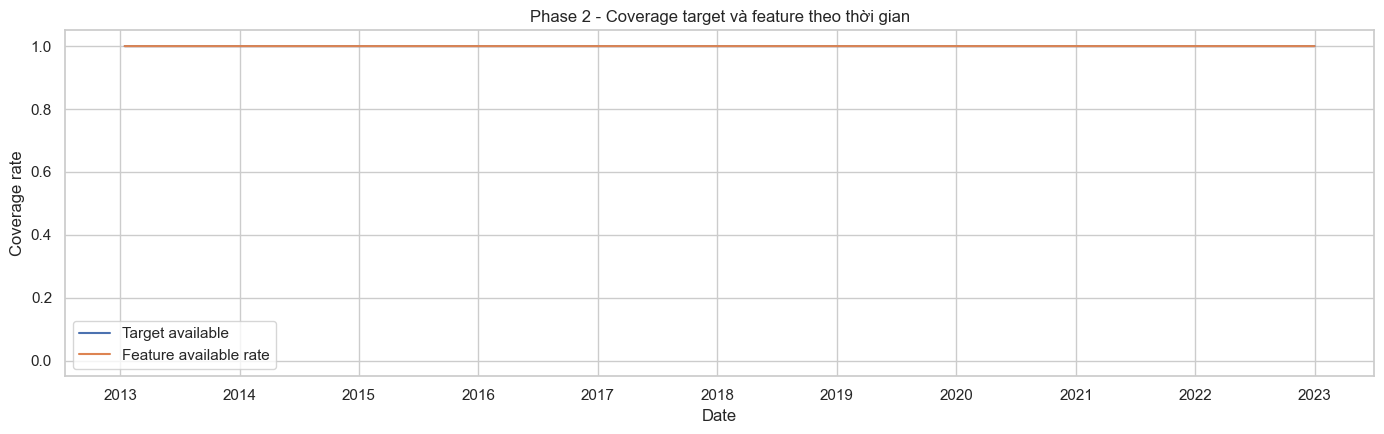

In [12]:
# Biểu đồ coverage target và feature
coverage_df = model_df.copy()
coverage_df['target_available'] = coverage_df[TARGET_COL].notna()
coverage_df['feature_available_rate'] = coverage_df[selected_features].notna().mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(coverage_df[DATE_COL], coverage_df['target_available'].astype(int), label='Target available')
ax.plot(coverage_df[DATE_COL], coverage_df['feature_available_rate'], label='Feature available rate')
ax.set_title('Phase 2 - Coverage target và feature theo thời gian')
ax.set_xlabel('Date')
ax.set_ylabel('Coverage rate')
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase2_target_feature_coverage.png', dpi=150)
plt.show()


In [13]:
# Kết quả chuẩn bị dữ liệu cho modeling
final_duplicate_dates = model_df.loc[model_df[DATE_COL].duplicated(), DATE_COL]
final_expected_dates = pd.date_range(model_df[DATE_COL].min(), model_df[DATE_COL].max(), freq='D')
final_missing_dates = pd.Index(final_expected_dates).difference(pd.Index(model_df[DATE_COL]))

assert model_df.shape == (3638, 24), f'model_df phải là (3638, 24), hiện tại {model_df.shape}'
assert len(selected_features) == 21, 'Số selected feature phải là 21.'
assert len(final_duplicate_dates) == 0, 'Date bị duplicate sau xử lý missing.'
assert len(final_missing_dates) == 0, 'Chuỗi ngày bị đứt gãy sau xử lý missing.'
assert model_df[selected_features].isna().sum().sum() == 0, 'Feature vẫn còn missing sau xử lý.'
assert leakage_review['needs_review'].sum() == 0, 'Có feature cần review leakage.'

phase2_done = pd.DataFrame([
    {'item': 'model_df_shape', 'value': str(model_df.shape)},
    {'item': 'selected_features', 'value': len(selected_features)},
    {'item': 'duplicate_dates_after_missing_handling', 'value': len(final_duplicate_dates)},
    {'item': 'missing_calendar_dates_after_missing_handling', 'value': len(final_missing_dates)},
    {'item': 'feature_missing_after_missing_handling', 'value': int(model_df[selected_features].isna().sum().sum())},
    {'item': 'leakage_features_need_review', 'value': leakage_review['needs_review'].sum()},
])

print(phase2_done.to_string(index=False))


                                         item      value
                               model_df_shape (3638, 24)
                            selected_features         21
       duplicate_dates_after_missing_handling          0
missing_calendar_dates_after_missing_handling          0
       feature_missing_after_missing_handling          0
                 leakage_features_need_review          0


## Kết luận Phase 2

- Bảng modeling ban đầu có **3,833 dòng** và **24 cột**, từ **2012-07-04** đến **2022-12-31**.
- Không có duplicate date, không thiếu ngày lịch, target `Revenue` không missing và không âm.
- Selected features ban đầu còn **255 ô missing**, nên đã loại **195 dòng** có missing feature.
- Sau xử lý, bảng sạch còn **3,638 dòng**, từ **2013-01-15** đến **2022-12-31**.
- `missing_values_after_handling = 0`, nghĩa là dữ liệu dùng để split/train sau Phase 2 đã sạch ở các feature đầu vào.


## Phase 3 - Chia train, validation, test

### Mục tiêu

- Dùng bảng sạch từ Phase 2 để chia dữ liệu theo thời gian.
- Không random split vì đây là bài toán dự báo theo ngày.
- Kiểm tra split không trùng ngày, không mất dòng và vẫn đủ target/feature.


In [14]:
# Phase 3 - Cell 1 - Load bảng sạch từ Phase 2
phase2_modeling_path = MODEL_TABLE_DIR / 'phase2_modeling_table.csv'
assert phase2_modeling_path.exists(), 'Chưa có phase2_modeling_table.csv. Cần chạy xong Phase 2 trước.'

model_df = pd.read_csv(phase2_modeling_path, parse_dates=[DATE_COL])
model_df[DATE_COL] = pd.to_datetime(model_df[DATE_COL]).dt.normalize()
model_df = model_df.sort_values(DATE_COL).reset_index(drop=True)

needed_columns = [DATE_COL, TARGET_COL, COGS_COL] + selected_features
missing_columns = [col for col in needed_columns if col not in model_df.columns]
assert not missing_columns, f'Thiếu cột trong bảng modeling sạch: {missing_columns}'

print('model_df shape:', model_df.shape)
print('Ngày bắt đầu:', model_df[DATE_COL].min())
print('Ngày kết thúc:', model_df[DATE_COL].max())


model_df shape: (3638, 24)
Ngày bắt đầu: 2013-01-15 00:00:00
Ngày kết thúc: 2022-12-31 00:00:00


In [15]:
# Phase 3 - Cell 2 - Chia dữ liệu theo thời gian
split_periods = pd.DataFrame([
    {'dataset': 'train', 'start_date': '2012-07-04', 'end_date': '2020-11-24'},
    {'dataset': 'validation', 'start_date': '2020-11-25', 'end_date': '2021-12-12'},
    {'dataset': 'test', 'start_date': '2021-12-13', 'end_date': '2022-12-31'},
])

split_periods['start_date'] = pd.to_datetime(split_periods['start_date'])
split_periods['end_date'] = pd.to_datetime(split_periods['end_date'])

train_df = model_df[model_df[DATE_COL].between(split_periods.loc[0, 'start_date'], split_periods.loc[0, 'end_date'])].copy()
validation_df = model_df[model_df[DATE_COL].between(split_periods.loc[1, 'start_date'], split_periods.loc[1, 'end_date'])].copy()
test_df = model_df[model_df[DATE_COL].between(split_periods.loc[2, 'start_date'], split_periods.loc[2, 'end_date'])].copy()

train_df.to_csv(MODEL_TABLE_DIR / 'modeling_train_dataset.csv', index=False, encoding='utf-8-sig')
validation_df.to_csv(MODEL_TABLE_DIR / 'modeling_validation_dataset.csv', index=False, encoding='utf-8-sig')
test_df.to_csv(MODEL_TABLE_DIR / 'modeling_test_dataset.csv', index=False, encoding='utf-8-sig')

print('train:', train_df.shape)
print('validation:', validation_df.shape)
print('test:', test_df.shape)


train: (2871, 24)
validation: (383, 24)
test: (384, 24)


In [16]:
# Phase 3 - Cell 3 - Tóm tắt và kiểm tra split
split_dfs = {
    'train': train_df,
    'validation': validation_df,
    'test': test_df,
}

summary_rows = []
for dataset, data in split_dfs.items():
    planned = split_periods[split_periods['dataset'] == dataset].iloc[0]
    expected_dates = pd.date_range(data[DATE_COL].min(), data[DATE_COL].max(), freq='D')
    missing_dates = pd.Index(expected_dates).difference(pd.Index(data[DATE_COL]))
    summary_rows.append({
        'dataset': dataset,
        'planned_start': planned['start_date'],
        'planned_end': planned['end_date'],
        'actual_start': data[DATE_COL].min(),
        'actual_end': data[DATE_COL].max(),
        'row_count': len(data),
        'duplicate_date_count': int(data[DATE_COL].duplicated().sum()),
        'missing_calendar_dates': len(missing_dates),
        'target_missing_rows': int(data[TARGET_COL].isna().sum()),
        'feature_missing_cells': int(data[selected_features].isna().sum().sum()),
    })

split_summary = pd.DataFrame(summary_rows)
all_split_dates = pd.concat([data[[DATE_COL]].assign(dataset=name) for name, data in split_dfs.items()])
overlap_date_count = int(all_split_dates[DATE_COL].duplicated().sum())
total_split_rows = sum(len(data) for data in split_dfs.values())

split_summary.to_csv(MODEL_TABLE_DIR / 'phase3_split_summary.csv', index=False, encoding='utf-8-sig')

assert overlap_date_count == 0, 'Train/validation/test đang bị trùng ngày.'
assert total_split_rows == len(model_df), 'Tổng dòng sau split không bằng bảng modeling.'
assert split_summary['duplicate_date_count'].sum() == 0, 'Có duplicate Date trong một tập.'
assert split_summary['missing_calendar_dates'].sum() == 0, 'Có tập bị đứt gãy ngày.'
assert split_summary['target_missing_rows'].sum() == 0, 'Có tập thiếu target.'
assert split_summary['feature_missing_cells'].sum() == 0, 'Có tập thiếu feature.'

print(split_summary.to_string(index=False))
print('overlap_date_count:', overlap_date_count)
print('total_split_rows:', total_split_rows)


   dataset planned_start planned_end actual_start actual_end  row_count  duplicate_date_count  missing_calendar_dates  target_missing_rows  feature_missing_cells
     train    2012-07-04  2020-11-24   2013-01-15 2020-11-24       2871                     0                       0                    0                      0
validation    2020-11-25  2021-12-12   2020-11-25 2021-12-12        383                     0                       0                    0                      0
      test    2021-12-13  2022-12-31   2021-12-13 2022-12-31        384                     0                       0                    0                      0
overlap_date_count: 0
total_split_rows: 3638


In [17]:
# Phase 3 - Cell 4 - Kiểm tra phân phối Revenue giữa các tập
split_df = pd.concat([
    train_df.assign(dataset='train'),
    validation_df.assign(dataset='validation'),
    test_df.assign(dataset='test'),
], ignore_index=True)

phase3_target_distribution = (
    split_df
    .groupby('dataset')[TARGET_COL]
    .agg(row_count='count', mean='mean', median='median', std='std', min='min', max='max')
    .reset_index()
)

phase3_target_distribution.to_csv(MODEL_TABLE_DIR / 'phase3_target_distribution.csv', index=False, encoding='utf-8-sig')
print(phase3_target_distribution.to_string(index=False))


   dataset  row_count         mean      median          std       min         max
      test        384 3.142208e+06 2899981.775 1.667614e+06 545563.72 11643208.73
     train       2871 4.662166e+06 3981191.660 2.764718e+06 279813.94 20905271.35
validation        383 2.765307e+06 2405871.450 1.653595e+06 370653.23 10795905.35


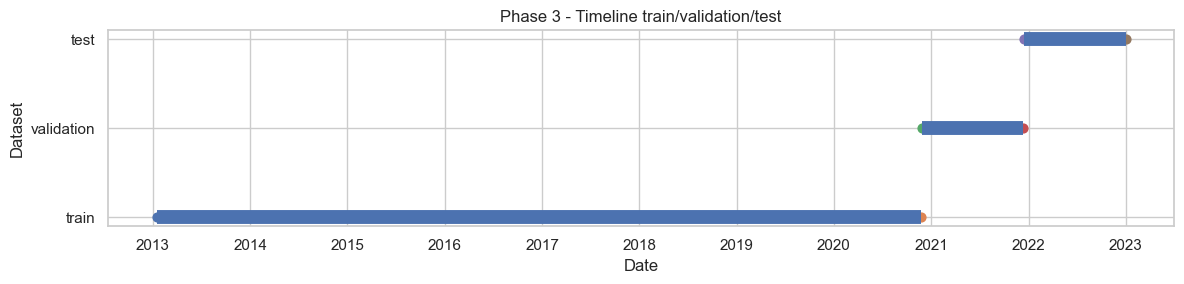

In [18]:
# Phase 3 - Cell 5 - Biểu đồ timeline split
fig, ax = plt.subplots(figsize=(12, 3))

for i, row in split_summary.iterrows():
    ax.hlines(row['dataset'], row['actual_start'], row['actual_end'], linewidth=10)
    ax.scatter(row['actual_start'], row['dataset'], s=40)
    ax.scatter(row['actual_end'], row['dataset'], s=40)

ax.set_title('Phase 3 - Timeline train/validation/test')
ax.set_xlabel('Date')
ax.set_ylabel('Dataset')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase3_timeline_split.png', dpi=150)
plt.show()


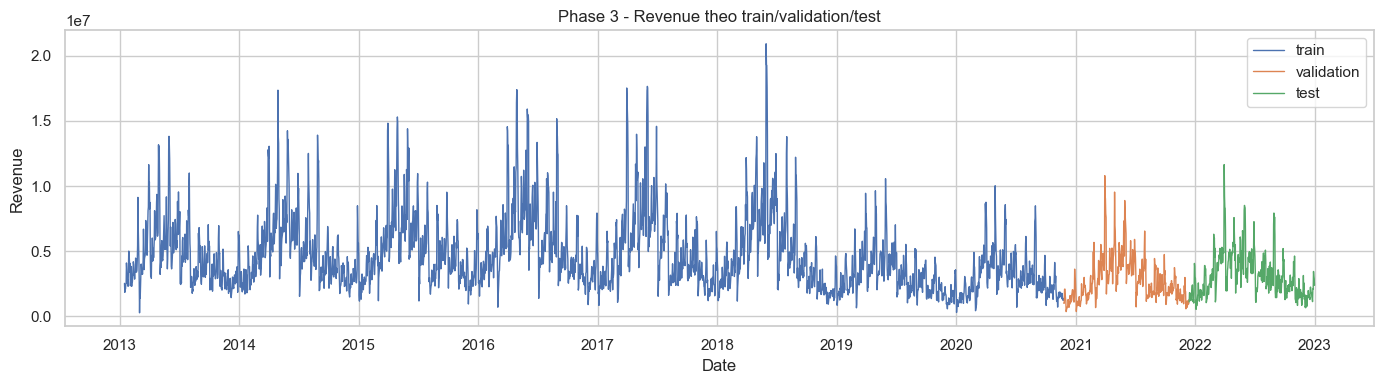

In [19]:
# Phase 3 - Cell 6 - Biểu đồ Revenue theo thời gian
fig, ax = plt.subplots(figsize=(14, 4))

for dataset, data in split_dfs.items():
    ax.plot(data[DATE_COL], data[TARGET_COL], label=dataset, linewidth=1)

ax.set_title('Phase 3 - Revenue theo train/validation/test')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase3_revenue_timeline.png', dpi=150)
plt.show()


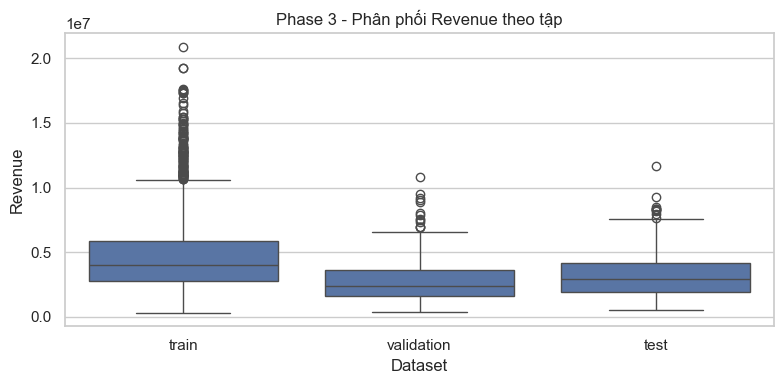

In [20]:
# Phase 3 - Cell 7 - Biểu đồ phân phối Revenue theo tập
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=split_df, x='dataset', y=TARGET_COL, ax=ax)
ax.set_title('Phase 3 - Phân phối Revenue theo tập')
ax.set_xlabel('Dataset')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase3_revenue_boxplot.png', dpi=150)
plt.show()


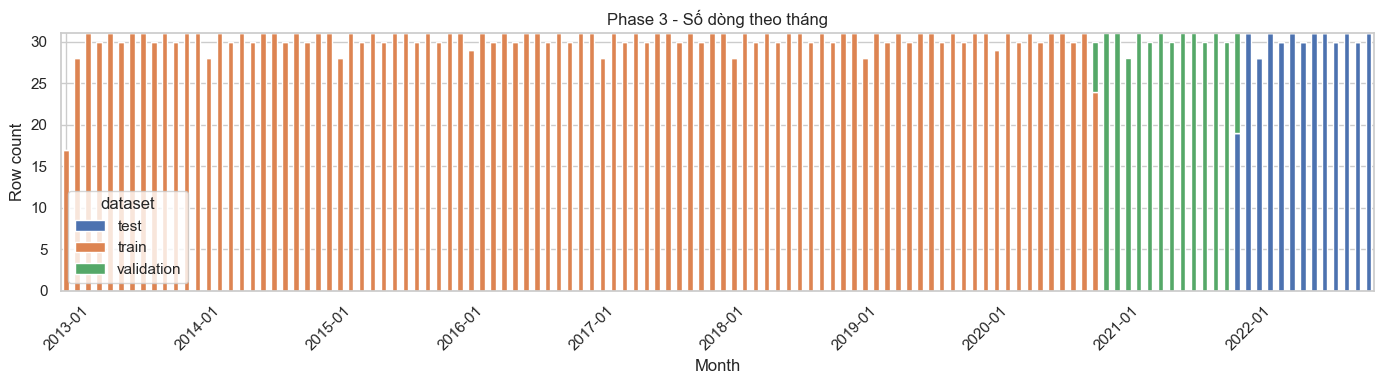

In [21]:
# Phase 3 - Cell 8 - Biểu đồ số dòng theo tháng
monthly_row_count = (
    split_df
    .assign(month=split_df[DATE_COL].dt.to_period('M').astype(str))
    .groupby(['month', 'dataset'])
    .size()
    .reset_index(name='row_count')
)

monthly_pivot = monthly_row_count.pivot(index='month', columns='dataset', values='row_count').fillna(0)

fig, ax = plt.subplots(figsize=(14, 4))
monthly_pivot.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Phase 3 - Số dòng theo tháng')
ax.set_xlabel('Month')
ax.set_ylabel('Row count')
ax.set_xticks(range(0, len(monthly_pivot), 12))
ax.set_xticklabels(monthly_pivot.index[::12], rotation=45)
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase3_monthly_row_count.png', dpi=150)
plt.show()


## Kết luận Phase 3

- Dữ liệu sạch từ Phase 2 được chia theo thời gian, không random split.
- Train: **2,871 dòng**, từ **2013-01-15** đến **2020-11-24**.
- Validation: **383 dòng**, từ **2020-11-25** đến **2021-12-12**.
- Test: **384 dòng**, từ **2021-12-13** đến **2022-12-31**.
- Cả 3 tập đều không duplicate date, không thiếu ngày, không missing target và không missing feature.
- Ý nghĩa: model chỉ học từ quá khứ và được đánh giá trên giai đoạn tương lai, phù hợp với bài toán forecasting.


## Phase 4 - Xây baseline model

### Mục tiêu

- Tạo các cách dự báo đơn giản để làm mốc so sánh.
- Baseline chưa phải model ML, chỉ là quy tắc dự báo dễ hiểu.
- Đánh giá baseline trên validation và test.


In [22]:
# Phase 4 - Cell 1 - Load train/validation/test từ Phase 3
train_path = MODEL_TABLE_DIR / 'modeling_train_dataset.csv'
validation_path = MODEL_TABLE_DIR / 'modeling_validation_dataset.csv'
test_path = MODEL_TABLE_DIR / 'modeling_test_dataset.csv'

assert train_path.exists(), 'Thiếu modeling_train_dataset.csv. Cần chạy Phase 3 trước.'
assert validation_path.exists(), 'Thiếu modeling_validation_dataset.csv. Cần chạy Phase 3 trước.'
assert test_path.exists(), 'Thiếu modeling_test_dataset.csv. Cần chạy Phase 3 trước.'

train_df = pd.read_csv(train_path, parse_dates=[DATE_COL])
validation_df = pd.read_csv(validation_path, parse_dates=[DATE_COL])
test_df = pd.read_csv(test_path, parse_dates=[DATE_COL])

for data in [train_df, validation_df, test_df]:
    data[DATE_COL] = pd.to_datetime(data[DATE_COL]).dt.normalize()
    data.sort_values(DATE_COL, inplace=True)
    data.reset_index(drop=True, inplace=True)

print('train:', train_df.shape)
print('validation:', validation_df.shape)
print('test:', test_df.shape)


train: (2871, 24)
validation: (383, 24)
test: (384, 24)


In [23]:
# Phase 4 - Cell 2 - Tạo dự báo baseline
train_mean_revenue = train_df[TARGET_COL].mean()

history_df = pd.concat([train_df, validation_df, test_df], ignore_index=True)
history_revenue = history_df.set_index(DATE_COL)[TARGET_COL]

eval_df = pd.concat([
    validation_df.assign(dataset='validation'),
    test_df.assign(dataset='test'),
], ignore_index=True)

eval_df['mean_baseline'] = train_mean_revenue
eval_df['yesterday_baseline'] = eval_df['Revenue_lag_1d']
eval_df['same_weekday_baseline'] = (eval_df[DATE_COL] - pd.Timedelta(days=7)).map(history_revenue)

baseline_columns = ['mean_baseline', 'yesterday_baseline', 'same_weekday_baseline']

phase4_baseline_predictions = eval_df[[DATE_COL, 'dataset', TARGET_COL] + baseline_columns].copy()
phase4_baseline_predictions.to_csv(MODEL_TABLE_DIR / 'phase4_baseline_predictions.csv', index=False, encoding='utf-8-sig')

print(phase4_baseline_predictions.head().to_string(index=False))
print('Số prediction missing theo baseline:')
print(phase4_baseline_predictions[baseline_columns].isna().sum().to_string())


      Date    dataset    Revenue  mean_baseline  yesterday_baseline  same_weekday_baseline
2020-11-25 validation 1016787.85   4.662166e+06          1234768.03             1708292.62
2020-11-26 validation 1003033.14   4.662166e+06          1016787.85             1389140.38
2020-11-27 validation 2064673.72   4.662166e+06          1003033.14             1761075.99
2020-11-28 validation 2102733.52   4.662166e+06          2064673.72             1277317.49
2020-11-29 validation 1696662.48   4.662166e+06          2102733.52             1402812.95
Số prediction missing theo baseline:
mean_baseline            0
yesterday_baseline       0
same_weekday_baseline    0


In [24]:
# Phase 4 - Cell 3 - Tính metric baseline
metric_rows = []

for dataset in ['validation', 'test']:
    dataset_data = phase4_baseline_predictions[phase4_baseline_predictions['dataset'] == dataset]
    for baseline in baseline_columns:
        metric_data = dataset_data.dropna(subset=[baseline]).copy()
        error = metric_data[TARGET_COL] - metric_data[baseline]
        abs_error = error.abs()
        metric_rows.append({
            'dataset': dataset,
            'baseline': baseline,
            'row_count': len(metric_data),
            'mae': abs_error.mean(),
            'rmse': np.sqrt((error ** 2).mean()),
            'wape': abs_error.sum() / metric_data[TARGET_COL].sum(),
        })

phase4_baseline_metrics = pd.DataFrame(metric_rows)
phase4_baseline_metrics = phase4_baseline_metrics.sort_values(['dataset', 'wape', 'mae']).reset_index(drop=True)
phase4_baseline_metrics.to_csv(MODEL_TABLE_DIR / 'phase4_baseline_metrics.csv', index=False, encoding='utf-8-sig')

print(phase4_baseline_metrics.to_string(index=False))


   dataset              baseline  row_count          mae         rmse     wape
      test    yesterday_baseline        384 7.105480e+05 1.060668e+06 0.226130
      test same_weekday_baseline        384 1.303382e+06 1.864110e+06 0.414798
      test         mean_baseline        384 1.950468e+06 2.254765e+06 0.620732
validation    yesterday_baseline        383 6.285299e+05 9.779895e+05 0.227291
validation same_weekday_baseline        383 1.136144e+06 1.708545e+06 0.410856
validation         mean_baseline        383 2.242061e+06 2.515017e+06 0.810782


In [25]:
# Phase 4 - Cell 4 - Chọn baseline tốt nhất theo validation WAPE
validation_metrics = phase4_baseline_metrics[phase4_baseline_metrics['dataset'] == 'validation'].copy()
validation_metrics = validation_metrics.sort_values(['wape', 'mae']).reset_index(drop=True)
best_baseline = validation_metrics.loc[0, 'baseline']

test_result = phase4_baseline_metrics[
    (phase4_baseline_metrics['dataset'] == 'test') &
    (phase4_baseline_metrics['baseline'] == best_baseline)
]

phase4_best_baseline_summary = pd.DataFrame([
    {'item': 'best_baseline_by_validation_wape', 'value': best_baseline},
    {'item': 'validation_wape', 'value': validation_metrics.loc[0, 'wape']},
    {'item': 'validation_mae', 'value': validation_metrics.loc[0, 'mae']},
    {'item': 'test_wape_of_best_baseline', 'value': test_result['wape'].iloc[0]},
    {'item': 'test_mae_of_best_baseline', 'value': test_result['mae'].iloc[0]},
])

phase4_best_baseline_summary.to_csv(MODEL_TABLE_DIR / 'phase4_best_baseline_summary.csv', index=False, encoding='utf-8-sig')
print(phase4_best_baseline_summary.to_string(index=False))


                            item              value
best_baseline_by_validation_wape yesterday_baseline
                 validation_wape           0.227291
                  validation_mae      628529.946005
      test_wape_of_best_baseline            0.22613
       test_mae_of_best_baseline      710548.024557


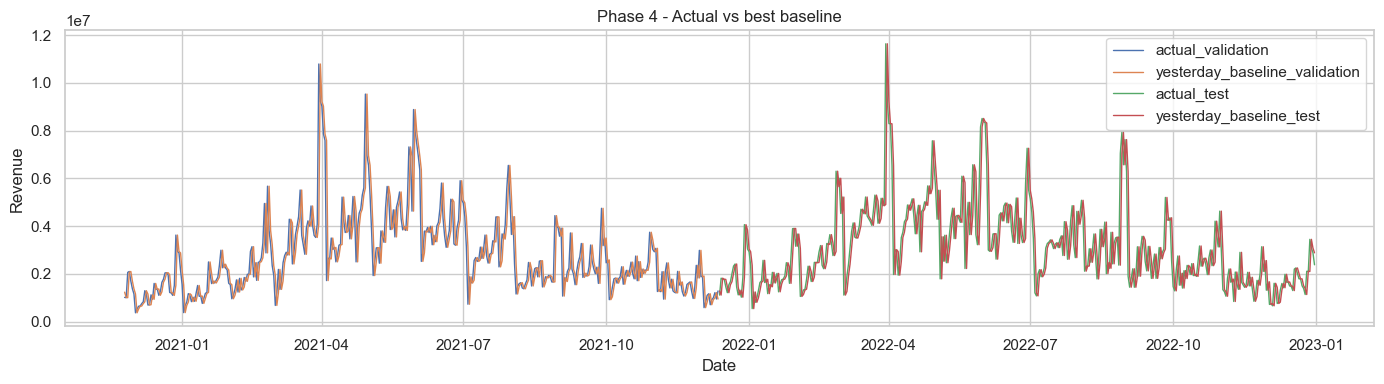

In [26]:
# Phase 4 - Cell 5 - Biểu đồ actual vs baseline tốt nhất
fig, ax = plt.subplots(figsize=(14, 4))

for dataset in ['validation', 'test']:
    plot_data = phase4_baseline_predictions[phase4_baseline_predictions['dataset'] == dataset]
    ax.plot(plot_data[DATE_COL], plot_data[TARGET_COL], label=f'actual_{dataset}', linewidth=1)
    ax.plot(plot_data[DATE_COL], plot_data[best_baseline], label=f'{best_baseline}_{dataset}', linewidth=1)

ax.set_title('Phase 4 - Actual vs best baseline')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase4_actual_vs_best_baseline.png', dpi=150)
plt.show()


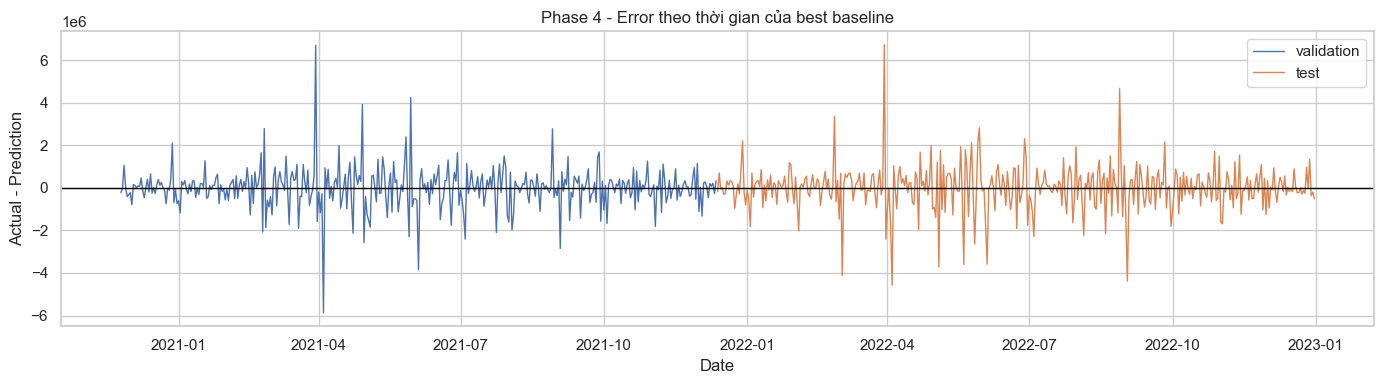

In [27]:
# Phase 4 - Cell 6 - Biểu đồ error của baseline tốt nhất
error_plot = phase4_baseline_predictions.dropna(subset=[best_baseline]).copy()
error_plot['error'] = error_plot[TARGET_COL] - error_plot[best_baseline]

fig, ax = plt.subplots(figsize=(14, 4))
for dataset in ['validation', 'test']:
    plot_data = error_plot[error_plot['dataset'] == dataset]
    ax.plot(plot_data[DATE_COL], plot_data['error'], label=dataset, linewidth=1)

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Phase 4 - Error theo thời gian của best baseline')
ax.set_xlabel('Date')
ax.set_ylabel('Actual - Prediction')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase4_best_baseline_error_timeline.png', dpi=150)
plt.show()


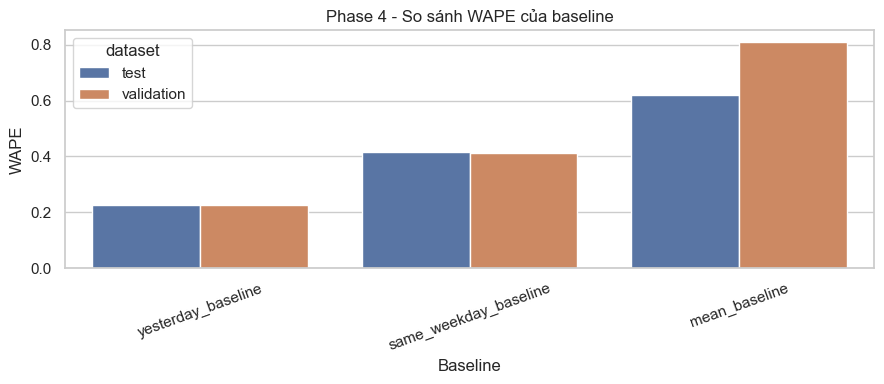

In [28]:
# Phase 4 - Cell 7 - Biểu đồ so sánh WAPE baseline
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=phase4_baseline_metrics, x='baseline', y='wape', hue='dataset', ax=ax)
ax.set_title('Phase 4 - So sánh WAPE của baseline')
ax.set_xlabel('Baseline')
ax.set_ylabel('WAPE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase4_baseline_wape_comparison.png', dpi=150)
plt.show()


In [29]:
# Phase 4 - Cell 8 - Kiểm tra kết quả Phase 4
assert (MODEL_TABLE_DIR / 'phase4_baseline_predictions.csv').exists(), 'Thiếu phase4_baseline_predictions.csv'
assert (MODEL_TABLE_DIR / 'phase4_baseline_metrics.csv').exists(), 'Thiếu phase4_baseline_metrics.csv'
assert (MODEL_TABLE_DIR / 'phase4_best_baseline_summary.csv').exists(), 'Thiếu phase4_best_baseline_summary.csv'
assert set(phase4_baseline_metrics['baseline']) == set(baseline_columns), 'Chưa đủ 3 baseline.'
assert set(phase4_baseline_metrics['dataset']) == {'validation', 'test'}, 'Metric phải có validation và test.'

phase4_done = pd.DataFrame([
    {'item': 'baseline_count', 'value': len(baseline_columns)},
    {'item': 'metric_rows', 'value': len(phase4_baseline_metrics)},
    {'item': 'best_baseline', 'value': best_baseline},
    {'item': 'best_validation_wape', 'value': validation_metrics.loc[0, 'wape']},
])

print(phase4_done.to_string(index=False))


                item              value
      baseline_count                  3
         metric_rows                  6
       best_baseline yesterday_baseline
best_validation_wape           0.227291


## Kết luận Phase 4

- Baseline tốt nhất trên validation là **`yesterday_baseline`**.
- Validation: `yesterday_baseline` đạt **WAPE 22.73%**, MAE khoảng **628,530**.
- Test: `yesterday_baseline` đạt **WAPE 22.61%**, MAE khoảng **710,548**.
- `same_weekday_baseline` và `mean_baseline` kém hơn rõ rệt trên validation, lần lượt khoảng **41.09%** và **81.08% WAPE**.
- Ý nghĩa: từ Phase 5 trở đi, model ML cần thắng `yesterday_baseline` thì mới chứng minh được giá trị.


## Phase 5 - Train model lần đầu

### Mục tiêu

- Train các model ML đầu tiên bằng 21 selected features.
- Fit model trên train, đánh giá trên validation.
- So sánh model ML với baseline tốt nhất ở Phase 4.
- Chưa dùng test để chọn model.


In [30]:
# Phase 5 - Cell 1 - Import thư viện model
# Nếu cell này lỗi, cần cài scikit-learn trước khi chạy Phase 5.
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


In [31]:
# Phase 5 - Cell 2 - Load dữ liệu train/validation và baseline
train_df = pd.read_csv(MODEL_TABLE_DIR / 'modeling_train_dataset.csv', parse_dates=[DATE_COL])
validation_df = pd.read_csv(MODEL_TABLE_DIR / 'modeling_validation_dataset.csv', parse_dates=[DATE_COL])
phase4_baseline_predictions = pd.read_csv(MODEL_TABLE_DIR / 'phase4_baseline_predictions.csv', parse_dates=[DATE_COL])
phase4_baseline_metrics = pd.read_csv(MODEL_TABLE_DIR / 'phase4_baseline_metrics.csv')

X_train = train_df[selected_features].copy()
y_train = train_df[TARGET_COL].copy()
X_validation = validation_df[selected_features].copy()
y_validation = validation_df[TARGET_COL].copy()

assert DATE_COL not in selected_features, 'Date không được nằm trong feature đầu vào.'
assert COGS_COL not in selected_features, 'COGS không được nằm trong feature đầu vào.'
assert X_train.isna().sum().sum() == 0, 'Train feature còn missing.'
assert X_validation.isna().sum().sum() == 0, 'Validation feature còn missing.'

print('X_train:', X_train.shape)
print('X_validation:', X_validation.shape)
print('Số feature:', len(selected_features))


X_train: (2871, 21)
X_validation: (383, 21)
Số feature: 21


In [32]:
# Phase 5 - Cell 3 - Train model và dự báo validation
models = {
    'linear_regression_scaled': make_pipeline(StandardScaler(), LinearRegression()),
    'ridge_regression_scaled': make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'lightgbm': LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
}

phase5_predictions = validation_df[[DATE_COL, TARGET_COL]].copy()
validation_baseline = phase4_baseline_predictions[phase4_baseline_predictions['dataset'] == 'validation']
phase5_predictions = phase5_predictions.merge(
    validation_baseline[[DATE_COL, 'yesterday_baseline']],
    on=DATE_COL,
    how='left'
)

for model_name, model in models.items():
    model.fit(X_train, y_train)
    phase5_predictions[model_name] = model.predict(X_validation)

phase5_predictions.to_csv(MODEL_TABLE_DIR / 'phase5_model_predictions_validation.csv', index=False, encoding='utf-8-sig')
print(phase5_predictions.head().to_string(index=False))


      Date    Revenue  yesterday_baseline  linear_regression_scaled  ridge_regression_scaled     lightgbm
2020-11-25 1016787.85          1234768.03              1.789056e+06             1.792464e+06 1.848601e+06
2020-11-26 1003033.14          1016787.85              1.468024e+06             1.476607e+06 1.666183e+06
2020-11-27 2064673.72          1003033.14              1.718901e+06             1.720355e+06 1.888213e+06
2020-11-28 2102733.52          2064673.72              2.165751e+06             2.172702e+06 2.160380e+06
2020-11-29 1696662.48          2102733.52              2.398885e+06             2.399011e+06 1.851543e+06


In [33]:
# Phase 5 - Cell 4 - Tính metric model trên validation
metric_rows = []
model_columns = list(models.keys())

for model_name in model_columns:
    error = phase5_predictions[TARGET_COL] - phase5_predictions[model_name]
    abs_error = error.abs()
    metric_rows.append({
        'model_type': 'ml_model',
        'model_name': model_name,
        'dataset': 'validation',
        'row_count': len(phase5_predictions),
        'mae': abs_error.mean(),
        'rmse': np.sqrt((error ** 2).mean()),
        'wape': abs_error.sum() / phase5_predictions[TARGET_COL].sum(),
    })

baseline_metric = phase4_baseline_metrics[
    (phase4_baseline_metrics['dataset'] == 'validation') &
    (phase4_baseline_metrics['baseline'] == 'yesterday_baseline')
].iloc[0]

metric_rows.append({
    'model_type': 'baseline',
    'model_name': 'yesterday_baseline',
    'dataset': 'validation',
    'row_count': int(baseline_metric['row_count']),
    'mae': baseline_metric['mae'],
    'rmse': baseline_metric['rmse'],
    'wape': baseline_metric['wape'],
})

phase5_model_metrics = pd.DataFrame(metric_rows)
phase5_model_metrics = phase5_model_metrics.sort_values(['wape', 'mae']).reset_index(drop=True)
phase5_model_metrics.to_csv(MODEL_TABLE_DIR / 'phase5_model_metrics.csv', index=False, encoding='utf-8-sig')
print(phase5_model_metrics.to_string(index=False))


model_type               model_name    dataset  row_count           mae          rmse     wape
  ml_model                 lightgbm validation        383 490332.437051 696490.047757 0.177316
  ml_model  ridge_regression_scaled validation        383 615410.831368 861526.685922 0.222547
  ml_model linear_regression_scaled validation        383 615738.030369 861684.861047 0.222665
  baseline       yesterday_baseline validation        383 628529.946005 977989.453730 0.227291


In [34]:
# Phase 5 - Cell 5 - Kiểm tra prediction của model
check_rows = []
actual_std = phase5_predictions[TARGET_COL].std()

for model_name in model_columns:
    prediction = phase5_predictions[model_name]
    error = phase5_predictions[TARGET_COL] - prediction
    check_rows.append({
        'model_name': model_name,
        'negative_prediction_count': int((prediction < 0).sum()),
        'prediction_mean': prediction.mean(),
        'actual_mean': phase5_predictions[TARGET_COL].mean(),
        'prediction_std': prediction.std(),
        'actual_std': actual_std,
        'std_ratio_pred_vs_actual': prediction.std() / actual_std,
        'bias_mean_actual_minus_pred': error.mean(),
        'max_abs_error': error.abs().max(),
    })

phase5_prediction_check = pd.DataFrame(check_rows)
phase5_prediction_check.to_csv(MODEL_TABLE_DIR / 'phase5_prediction_check.csv', index=False, encoding='utf-8-sig')
print(phase5_prediction_check.to_string(index=False))


              model_name  negative_prediction_count  prediction_mean  actual_mean  prediction_std   actual_std  std_ratio_pred_vs_actual  bias_mean_actual_minus_pred  max_abs_error
linear_regression_scaled                          0     2.780863e+06 2.765307e+06    1.576228e+06 1.653595e+06                  0.953212                -15556.274589   6.216996e+06
 ridge_regression_scaled                          0     2.781424e+06 2.765307e+06    1.575594e+06 1.653595e+06                  0.952829                -16117.235957   6.217788e+06
                lightgbm                          0     2.791754e+06 2.765307e+06    1.513924e+06 1.653595e+06                  0.915535                -26446.716073   4.407687e+06


In [35]:
# Phase 5 - Cell 6 - Chọn model ML tốt nhất theo validation WAPE
ml_metrics = phase5_model_metrics[phase5_model_metrics['model_type'] == 'ml_model'].copy()
ml_metrics = ml_metrics.sort_values(['wape', 'mae']).reset_index(drop=True)

best_model_name = ml_metrics.loc[0, 'model_name']
best_model_wape = ml_metrics.loc[0, 'wape']
best_model_mae = ml_metrics.loc[0, 'mae']
baseline_wape = baseline_metric['wape']
baseline_mae = baseline_metric['mae']

phase5_best_model_summary = pd.DataFrame([
    {'item': 'best_model_by_validation_wape', 'value': best_model_name},
    {'item': 'best_model_validation_wape', 'value': best_model_wape},
    {'item': 'best_model_validation_mae', 'value': best_model_mae},
    {'item': 'baseline_to_beat', 'value': 'yesterday_baseline'},
    {'item': 'baseline_validation_wape', 'value': baseline_wape},
    {'item': 'baseline_validation_mae', 'value': baseline_mae},
    {'item': 'beats_baseline_by_wape', 'value': bool(best_model_wape < baseline_wape)},
    {'item': 'wape_improvement_vs_baseline', 'value': baseline_wape - best_model_wape},
])

phase5_best_model_summary.to_csv(MODEL_TABLE_DIR / 'phase5_best_model_summary.csv', index=False, encoding='utf-8-sig')
print(phase5_best_model_summary.to_string(index=False))


                         item              value
best_model_by_validation_wape           lightgbm
   best_model_validation_wape           0.177316
    best_model_validation_mae      490332.437051
             baseline_to_beat yesterday_baseline
     baseline_validation_wape           0.227291
      baseline_validation_mae      628529.946005
       beats_baseline_by_wape               True
 wape_improvement_vs_baseline           0.049975


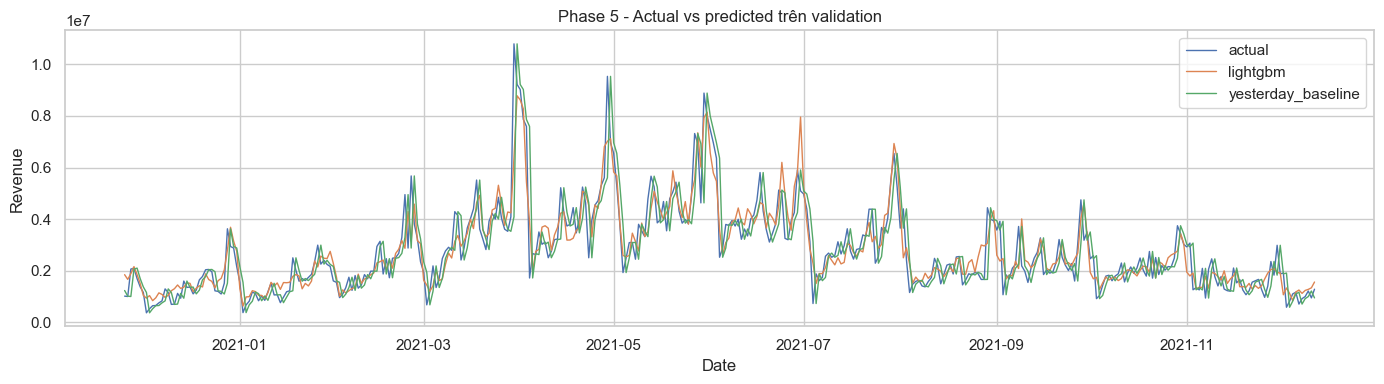

In [36]:
# Phase 5 - Cell 7 - Biểu đồ actual vs predicted của model tốt nhất
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(phase5_predictions[DATE_COL], phase5_predictions[TARGET_COL], label='actual', linewidth=1)
ax.plot(phase5_predictions[DATE_COL], phase5_predictions[best_model_name], label=best_model_name, linewidth=1)
ax.plot(phase5_predictions[DATE_COL], phase5_predictions['yesterday_baseline'], label='yesterday_baseline', linewidth=1)
ax.set_title('Phase 5 - Actual vs predicted trên validation')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase5_actual_vs_predicted_validation.png', dpi=150)
plt.show()


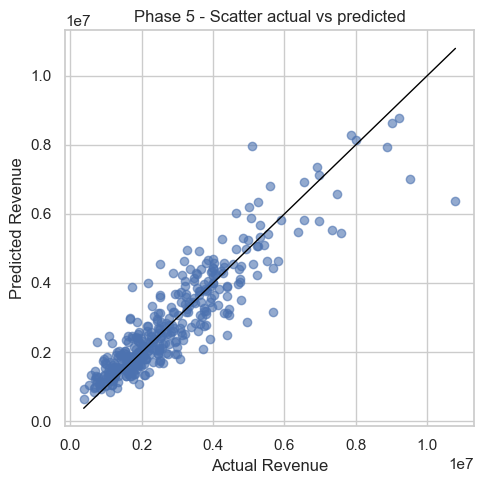

In [37]:
# Phase 5 - Cell 8 - Scatter actual vs predicted
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(phase5_predictions[TARGET_COL], phase5_predictions[best_model_name], alpha=0.6)
min_value = min(phase5_predictions[TARGET_COL].min(), phase5_predictions[best_model_name].min())
max_value = max(phase5_predictions[TARGET_COL].max(), phase5_predictions[best_model_name].max())
ax.plot([min_value, max_value], [min_value, max_value], color='black', linewidth=1)
ax.set_title('Phase 5 - Scatter actual vs predicted')
ax.set_xlabel('Actual Revenue')
ax.set_ylabel('Predicted Revenue')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase5_scatter_actual_predicted.png', dpi=150)
plt.show()


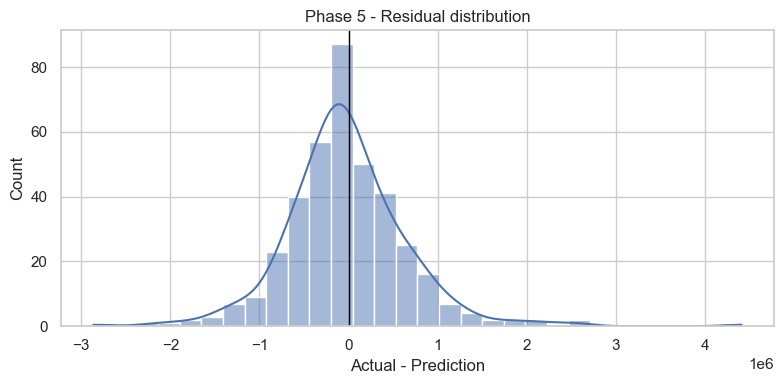

In [38]:
# Phase 5 - Cell 9 - Phân phối residual của model tốt nhất
phase5_residual = phase5_predictions[TARGET_COL] - phase5_predictions[best_model_name]

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(phase5_residual, bins=30, kde=True, ax=ax)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Phase 5 - Residual distribution')
ax.set_xlabel('Actual - Prediction')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase5_residual_distribution.png', dpi=150)
plt.show()


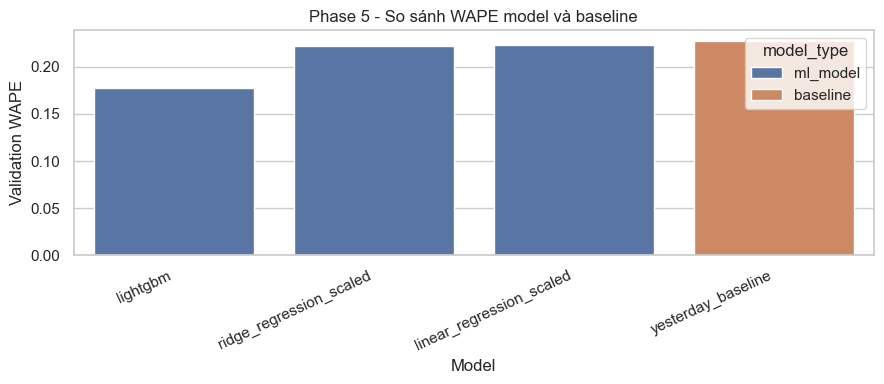

In [39]:
# Phase 5 - Cell 10 - Bar chart so sánh WAPE
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=phase5_model_metrics, x='model_name', y='wape', hue='model_type', ax=ax)
ax.set_title('Phase 5 - So sánh WAPE model và baseline')
ax.set_xlabel('Model')
ax.set_ylabel('Validation WAPE')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase5_wape_comparison.png', dpi=150)
plt.show()


In [40]:
# Phase 5 - Cell 11 - Kiểm tra kết quả Phase 5
assert (MODEL_TABLE_DIR / 'phase5_model_predictions_validation.csv').exists(), 'Thiếu phase5_model_predictions_validation.csv'
assert (MODEL_TABLE_DIR / 'phase5_model_metrics.csv').exists(), 'Thiếu phase5_model_metrics.csv'
assert (MODEL_TABLE_DIR / 'phase5_best_model_summary.csv').exists(), 'Thiếu phase5_best_model_summary.csv'
assert (MODEL_TABLE_DIR / 'phase5_prediction_check.csv').exists(), 'Thiếu phase5_prediction_check.csv'
assert set(model_columns).issubset(set(phase5_predictions.columns)), 'Thiếu prediction của model.'
assert 'test' not in phase5_model_metrics['dataset'].unique(), 'Phase 5 chưa dùng test để chọn model.'

phase5_done = pd.DataFrame([
    {'item': 'trained_model_count', 'value': len(model_columns)},
    {'item': 'baseline_to_beat', 'value': 'yesterday_baseline'},
    {'item': 'best_model', 'value': best_model_name},
    {'item': 'best_model_validation_wape', 'value': best_model_wape},
    {'item': 'beats_baseline_by_wape', 'value': bool(best_model_wape < baseline_wape)},
])

print(phase5_done.to_string(index=False))


                      item              value
       trained_model_count                  3
          baseline_to_beat yesterday_baseline
                best_model           lightgbm
best_model_validation_wape           0.177316
    beats_baseline_by_wape               True


## Kết luận Phase 5

- Model tốt nhất lần đầu là **LightGBM**.
- LightGBM validation WAPE **17.73%**, MAE khoảng **490,332**.
- Baseline `yesterday_baseline` validation WAPE **22.73%**, MAE khoảng **628,530**.
- LightGBM cải thiện khoảng **5.00 điểm phần trăm WAPE** so với baseline.
- Model không có prediction âm; prediction mean khoảng **2.79M**, gần actual mean **2.77M**.
- Ý nghĩa: model ML đã tốt hơn cách dự báo đơn giản bằng doanh thu hôm qua.


## Phase 6 - Chọn metric đánh giá

### Mục tiêu

- Chốt WAPE làm metric chính để so sánh model.
- Dùng MAE và RMSE làm metric phụ.
- Phân tích sai số validation của best model và baseline.


In [41]:
# Phase 6 - Cell 1 - Load kết quả Phase 5
phase5_predictions_path = MODEL_TABLE_DIR / 'phase5_model_predictions_validation.csv'
phase5_metrics_path = MODEL_TABLE_DIR / 'phase5_model_metrics.csv'
phase5_best_summary_path = MODEL_TABLE_DIR / 'phase5_best_model_summary.csv'

assert phase5_predictions_path.exists(), 'Thiếu phase5_model_predictions_validation.csv. Cần chạy Phase 5 trước.'
assert phase5_metrics_path.exists(), 'Thiếu phase5_model_metrics.csv. Cần chạy Phase 5 trước.'
assert phase5_best_summary_path.exists(), 'Thiếu phase5_best_model_summary.csv. Cần chạy Phase 5 trước.'

phase5_predictions = pd.read_csv(phase5_predictions_path, parse_dates=[DATE_COL])
phase5_model_metrics = pd.read_csv(phase5_metrics_path)
phase5_best_model_summary = pd.read_csv(phase5_best_summary_path)

best_model_name = phase5_best_model_summary.loc[
    phase5_best_model_summary['item'] == 'best_model_by_validation_wape', 'value'
].iloc[0]
baseline_name = 'yesterday_baseline'

assert best_model_name in phase5_predictions.columns, f'Thiếu prediction của best model: {best_model_name}'
assert baseline_name in phase5_predictions.columns, 'Thiếu yesterday_baseline trong prediction.'

print('best_model:', best_model_name)
print('baseline:', baseline_name)
print('prediction shape:', phase5_predictions.shape)


best_model: lightgbm
baseline: yesterday_baseline
prediction shape: (383, 6)


In [42]:
# Phase 6 - Cell 2 - Ghi chính sách metric
phase6_metric_policy = pd.DataFrame([
    {'metric': 'WAPE', 'role': 'main', 'reason': 'Dễ hiểu theo tỷ lệ tổng doanh thu, phù hợp báo cáo kinh doanh.', 'used_for_selection': True},
    {'metric': 'MAE', 'role': 'supporting', 'reason': 'Cho biết trung bình mỗi ngày sai bao nhiêu tiền.', 'used_for_selection': False},
    {'metric': 'RMSE', 'role': 'supporting', 'reason': 'Phạt mạnh các ngày sai rất lớn.', 'used_for_selection': False},
    {'metric': 'MAPE', 'role': 'not_main', 'reason': 'Không dùng chính vì doanh thu có thể thấp hoặc gần 0.', 'used_for_selection': False},
])

phase6_metric_policy.to_csv(MODEL_TABLE_DIR / 'phase6_metric_policy.csv', index=False, encoding='utf-8-sig')
print(phase6_metric_policy.to_string(index=False))


metric       role                                                         reason  used_for_selection
  WAPE       main Dễ hiểu theo tỷ lệ tổng doanh thu, phù hợp báo cáo kinh doanh.                True
   MAE supporting               Cho biết trung bình mỗi ngày sai bao nhiêu tiền.               False
  RMSE supporting                                Phạt mạnh các ngày sai rất lớn.               False
  MAPE   not_main          Không dùng chính vì doanh thu có thể thấp hoặc gần 0.               False


In [43]:
# Phase 6 - Cell 3 - Metric tổng của best model và baseline
phase6_metric_by_model = phase5_model_metrics[
    phase5_model_metrics['model_name'].isin([best_model_name, baseline_name])
].copy()

phase6_metric_by_model = phase6_metric_by_model.sort_values(['wape', 'mae']).reset_index(drop=True)
phase6_metric_by_model.to_csv(MODEL_TABLE_DIR / 'phase6_metric_by_model.csv', index=False, encoding='utf-8-sig')
print(phase6_metric_by_model.to_string(index=False))


model_type         model_name    dataset  row_count           mae          rmse     wape
  ml_model           lightgbm validation        383 490332.437051 696490.047757 0.177316
  baseline yesterday_baseline validation        383 628529.946005 977989.453730 0.227291


In [44]:
# Phase 6 - Cell 4 - WAPE theo tháng trên validation
monthly_rows = []
metric_targets = [best_model_name, baseline_name]

for model_name in metric_targets:
    temp = phase5_predictions[[DATE_COL, TARGET_COL, model_name]].copy()
    temp['month'] = temp[DATE_COL].dt.to_period('M').astype(str)
    temp['error'] = temp[TARGET_COL] - temp[model_name]
    temp['abs_error'] = temp['error'].abs()

    for month, data in temp.groupby('month'):
        monthly_rows.append({
            'month': month,
            'model_name': model_name,
            'row_count': len(data),
            'mae': data['abs_error'].mean(),
            'rmse': np.sqrt((data['error'] ** 2).mean()),
            'wape': data['abs_error'].sum() / data[TARGET_COL].sum(),
            'mean_error': data['error'].mean(),
        })

phase6_monthly_wape = pd.DataFrame(monthly_rows)
phase6_monthly_wape.to_csv(MODEL_TABLE_DIR / 'phase6_monthly_wape.csv', index=False, encoding='utf-8-sig')
print(phase6_monthly_wape.head(12).to_string(index=False))


  month model_name  row_count           mae          rmse     wape     mean_error
2020-11   lightgbm          6 335612.816158 448508.583903 0.217455 -276792.700999
2020-12   lightgbm         31 353085.076083 404806.426210 0.250635 -148618.782958
2021-01   lightgbm         31 290520.792376 362236.773479 0.193793  -90324.903653
2021-02   lightgbm         28 506577.094021 777822.424827 0.214659  107269.819424
2021-03   lightgbm         31 615834.320317 978255.376322 0.168537  163923.362961
2021-04   lightgbm         30 698092.174205 979879.218809 0.155319   50379.335724
2021-05   lightgbm         31 559259.972674 712782.217332 0.121178   25131.784216
2021-06   lightgbm         30 706087.433613 915791.716154 0.164910 -193973.080058
2021-07   lightgbm         31 466954.675677 586250.199460 0.143321   43488.032261
2021-08   lightgbm         31 445001.619615 650936.193504 0.202036 -159628.651611
2021-09   lightgbm         30 550697.534457 772529.358728 0.220744  -81805.895861
2021-10   lightg

In [45]:
# Phase 6 - Cell 5 - Tóm tắt sai số và ngày sai lớn
summary_rows = []

for model_name in metric_targets:
    temp = phase5_predictions[[DATE_COL, TARGET_COL, model_name]].copy()
    temp['error'] = temp[TARGET_COL] - temp[model_name]
    temp['abs_error'] = temp['error'].abs()
    worst_row = temp.sort_values('abs_error', ascending=False).iloc[0]

    summary_rows.append({
        'model_name': model_name,
        'mean_error_actual_minus_pred': temp['error'].mean(),
        'mean_abs_error': temp['abs_error'].mean(),
        'median_abs_error': temp['abs_error'].median(),
        'max_abs_error': temp['abs_error'].max(),
        'worst_error_date': worst_row[DATE_COL],
        'worst_error_actual': worst_row[TARGET_COL],
        'worst_error_prediction': worst_row[model_name],
    })

phase6_error_summary = pd.DataFrame(summary_rows)
phase6_error_summary.to_csv(MODEL_TABLE_DIR / 'phase6_error_summary.csv', index=False, encoding='utf-8-sig')
print(phase6_error_summary.to_string(index=False))


        model_name  mean_error_actual_minus_pred  mean_abs_error  median_abs_error  max_abs_error worst_error_date  worst_error_actual  worst_error_prediction
          lightgbm                 -26446.716073   490332.437051     359138.852601   4.407687e+06       2021-03-30         10795905.35            6.388218e+06
yesterday_baseline                    131.321462   628529.946005     397125.970000   6.705815e+06       2021-03-30         10795905.35            4.090091e+06


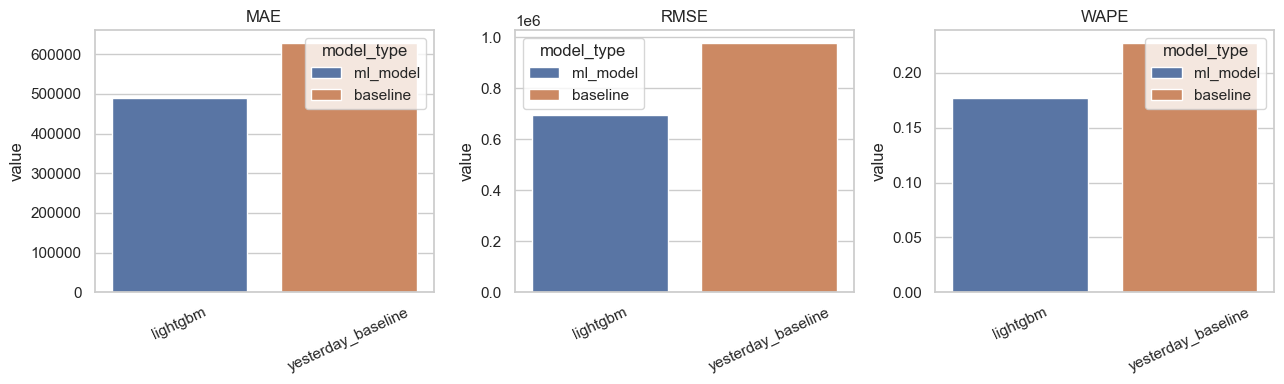

In [46]:
# Phase 6 - Cell 6 - Bar chart metric tổng
plot_metric = phase6_metric_by_model.melt(
    id_vars=['model_type', 'model_name'],
    value_vars=['mae', 'rmse', 'wape'],
    var_name='metric',
    value_name='value'
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['mae', 'rmse', 'wape']):
    data = plot_metric[plot_metric['metric'] == metric]
    sns.barplot(data=data, x='model_name', y='value', hue='model_type', ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase6_metric_bar_chart.png', dpi=150)
plt.show()


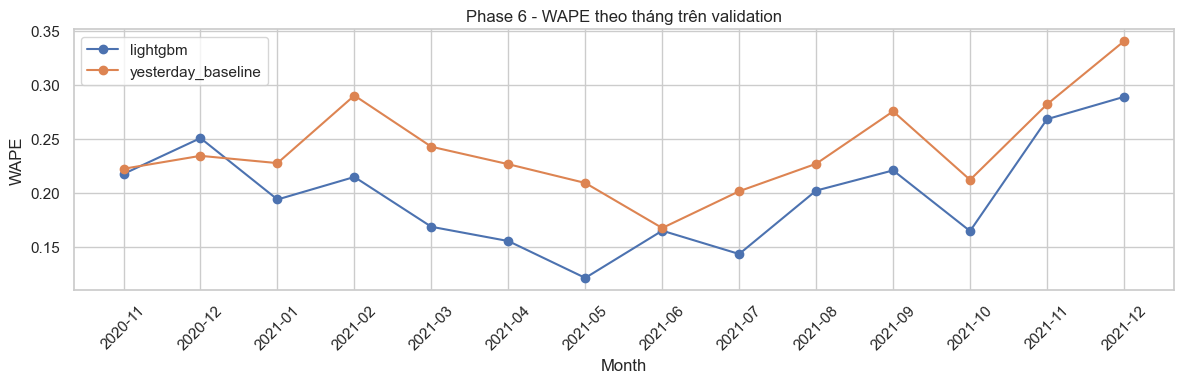

In [47]:
# Phase 6 - Cell 7 - Line chart WAPE theo tháng
fig, ax = plt.subplots(figsize=(12, 4))
for model_name in metric_targets:
    data = phase6_monthly_wape[phase6_monthly_wape['model_name'] == model_name]
    ax.plot(data['month'], data['wape'], marker='o', label=model_name)

ax.set_title('Phase 6 - WAPE theo tháng trên validation')
ax.set_xlabel('Month')
ax.set_ylabel('WAPE')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase6_monthly_wape.png', dpi=150)
plt.show()


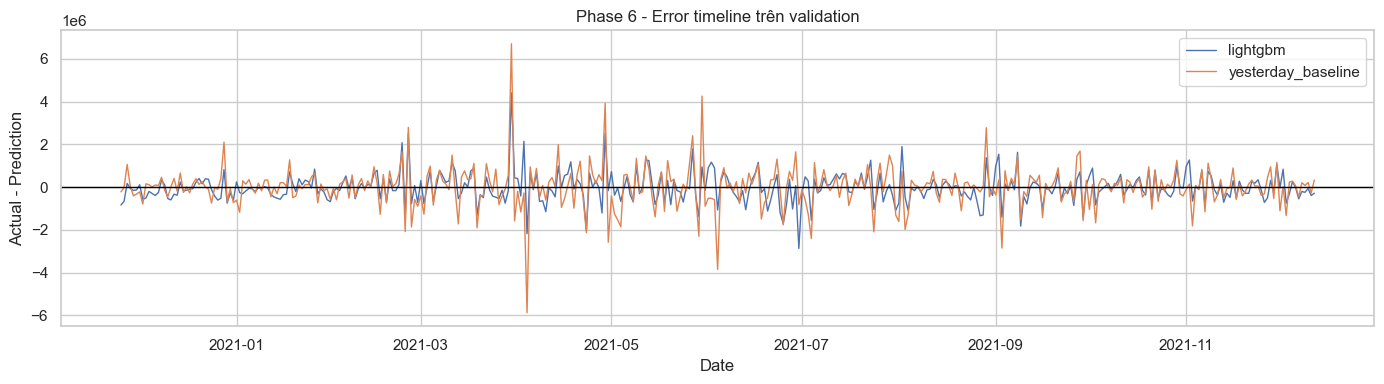

In [48]:
# Phase 6 - Cell 8 - Error timeline của best model và baseline
fig, ax = plt.subplots(figsize=(14, 4))

for model_name in metric_targets:
    error = phase5_predictions[TARGET_COL] - phase5_predictions[model_name]
    ax.plot(phase5_predictions[DATE_COL], error, label=model_name, linewidth=1)

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Phase 6 - Error timeline trên validation')
ax.set_xlabel('Date')
ax.set_ylabel('Actual - Prediction')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase6_error_timeline.png', dpi=150)
plt.show()


In [49]:
# Phase 6 - Cell 9 - Kiểm tra kết quả Phase 6
assert (MODEL_TABLE_DIR / 'phase6_metric_policy.csv').exists(), 'Thiếu phase6_metric_policy.csv'
assert (MODEL_TABLE_DIR / 'phase6_metric_by_model.csv').exists(), 'Thiếu phase6_metric_by_model.csv'
assert (MODEL_TABLE_DIR / 'phase6_monthly_wape.csv').exists(), 'Thiếu phase6_monthly_wape.csv'
assert (MODEL_TABLE_DIR / 'phase6_error_summary.csv').exists(), 'Thiếu phase6_error_summary.csv'
assert phase6_metric_policy.loc[phase6_metric_policy['metric'] == 'WAPE', 'used_for_selection'].iloc[0] == True, 'WAPE phải là metric chính.'

phase6_done = pd.DataFrame([
    {'item': 'main_metric', 'value': 'WAPE'},
    {'item': 'best_model', 'value': best_model_name},
    {'item': 'baseline', 'value': baseline_name},
    {'item': 'monthly_metric_rows', 'value': len(phase6_monthly_wape)},
])

print(phase6_done.to_string(index=False))


               item              value
        main_metric               WAPE
         best_model           lightgbm
           baseline yesterday_baseline
monthly_metric_rows                 28


## Kết luận Phase 6

- Chọn **WAPE** làm metric chính vì dễ hiểu theo kinh doanh: tổng sai số chiếm bao nhiêu phần trăm tổng doanh thu.
- Trên validation, LightGBM đạt **WAPE 17.73%**, tốt hơn baseline **22.73%**.
- MAE dùng để hiểu trung bình mỗi ngày sai bao nhiêu tiền; RMSE dùng để phát hiện ngày sai rất nặng.
- Ngày lỗi lớn nhất là **2021-03-30**: model sai khoảng **4.41M**, baseline sai khoảng **6.71M**.
- Theo tháng, model yếu nhất ở **2021-12** với WAPE khoảng **28.88%**.
- Ý nghĩa: từ đây việc chọn/cải thiện model ưu tiên WAPE validation, nhưng vẫn kiểm tra MAE/RMSE để tránh bỏ qua lỗi lớn.


## Phase 7 - Phân tích lỗi model

### Mục tiêu

- Tìm ngày và nhóm dữ liệu mà best model dự báo sai nhiều nhất.
- So sánh lỗi của best model với baseline tốt nhất.
- Ghi nhận nguyên nhân nghi ngờ, chưa sửa model ở phase này.


In [50]:
# Phase 7 - Cell 1 - Load kết quả prediction và best model
phase5_predictions = pd.read_csv(MODEL_TABLE_DIR / 'phase5_model_predictions_validation.csv', parse_dates=[DATE_COL])
phase5_best_model_summary = pd.read_csv(MODEL_TABLE_DIR / 'phase5_best_model_summary.csv')
phase2_modeling_table = pd.read_csv(MODEL_TABLE_DIR / 'phase2_modeling_table.csv', parse_dates=[DATE_COL])

best_model_name = phase5_best_model_summary.loc[
    phase5_best_model_summary['item'] == 'best_model_by_validation_wape', 'value'
].iloc[0]
baseline_name = 'yesterday_baseline'

assert best_model_name in phase5_predictions.columns, f'Thiếu prediction của best model: {best_model_name}'
assert baseline_name in phase5_predictions.columns, 'Thiếu yesterday_baseline.'

print('best_model:', best_model_name)
print('baseline:', baseline_name)
print('validation rows:', len(phase5_predictions))


best_model: lightgbm
baseline: yesterday_baseline
validation rows: 383


In [51]:
# Phase 7 - Cell 2 - Tạo bảng lỗi từng ngày
error_detail = phase5_predictions[[DATE_COL, TARGET_COL, best_model_name, baseline_name]].copy()
error_detail['model_error'] = error_detail[TARGET_COL] - error_detail[best_model_name]
error_detail['model_abs_error'] = error_detail['model_error'].abs()
error_detail['baseline_error'] = error_detail[TARGET_COL] - error_detail[baseline_name]
error_detail['baseline_abs_error'] = error_detail['baseline_error'].abs()
error_detail['model_better_than_baseline'] = error_detail['model_abs_error'] < error_detail['baseline_abs_error']
error_detail['month'] = error_detail[DATE_COL].dt.to_period('M').astype(str)
error_detail['weekday'] = error_detail[DATE_COL].dt.day_name()

error_detail.to_csv(MODEL_TABLE_DIR / 'phase7_error_detail.csv', index=False, encoding='utf-8-sig')
print(error_detail.head().to_string(index=False))


      Date    Revenue     lightgbm  yesterday_baseline    model_error  model_abs_error  baseline_error  baseline_abs_error  model_better_than_baseline   month   weekday
2020-11-25 1016787.85 1.848601e+06          1234768.03 -831813.162920    831813.162920      -217980.18           217980.18                       False 2020-11 Wednesday
2020-11-26 1003033.14 1.666183e+06          1016787.85 -663150.307874    663150.307874       -13754.71            13754.71                       False 2020-11  Thursday
2020-11-27 2064673.72 1.888213e+06          1003033.14  176460.345477    176460.345477      1061640.58          1061640.58                        True 2020-11    Friday
2020-11-28 2102733.52 2.160380e+06          2064673.72  -57646.292085     57646.292085        38059.80            38059.80                       False 2020-11  Saturday
2020-11-29 1696662.48 1.851543e+06          2102733.52 -154880.548130    154880.548130      -406071.04           406071.04                        True 2020

In [52]:
# Phase 7 - Cell 3 - Top ngày lỗi lớn nhất
top_n = 20
phase7_top_error_days = error_detail.sort_values('model_abs_error', ascending=False).head(top_n).copy()
phase7_top_error_days.to_csv(MODEL_TABLE_DIR / 'phase7_top_error_days.csv', index=False, encoding='utf-8-sig')
print(phase7_top_error_days.to_string(index=False))


      Date     Revenue     lightgbm  yesterday_baseline   model_error  model_abs_error  baseline_error  baseline_abs_error  model_better_than_baseline   month   weekday
2021-03-30 10795905.35 6.388218e+06          4090090.60  4.407687e+06     4.407687e+06      6705814.75          6705814.75                        True 2021-03   Tuesday
2021-06-30  5094915.79 7.958328e+06          5907160.01 -2.863413e+06     2.863413e+06      -812244.22           812244.22                       False 2021-06 Wednesday
2021-02-25  5675843.97 3.152149e+06          2880648.13  2.523695e+06     2.523695e+06      2795195.84          2795195.84                        True 2021-02  Thursday
2021-04-29  9535515.05 7.019608e+06          5606431.49  2.515907e+06     2.515907e+06      3929083.56          3929083.56                        True 2021-04  Thursday
2021-04-04  1720555.46 3.894856e+06          7594752.42 -2.174300e+06     2.174300e+06     -5874196.96          5874196.96                        True 2021

In [53]:
# Phase 7 - Cell 4 - Lỗi theo tháng
phase7_error_by_month = (
    error_detail
    .groupby('month')
    .agg(
        row_count=(TARGET_COL, 'count'),
        mean_revenue=(TARGET_COL, 'mean'),
        model_mae=('model_abs_error', 'mean'),
        baseline_mae=('baseline_abs_error', 'mean'),
        model_wape=('model_abs_error', lambda s: s.sum() / error_detail.loc[s.index, TARGET_COL].sum()),
        baseline_wape=('baseline_abs_error', lambda s: s.sum() / error_detail.loc[s.index, TARGET_COL].sum()),
        model_mean_error=('model_error', 'mean'),
        model_win_rate=('model_better_than_baseline', 'mean'),
    )
    .reset_index()
)

phase7_error_by_month.to_csv(MODEL_TABLE_DIR / 'phase7_error_by_month.csv', index=False, encoding='utf-8-sig')
print(phase7_error_by_month.to_string(index=False))


  month  row_count  mean_revenue     model_mae  baseline_mae  model_wape  baseline_wape  model_mean_error  model_win_rate
2020-11          6  1.543365e+06 335612.816158  3.429783e+05    0.217455       0.222228    -276792.700999        0.500000
2020-12         31  1.408760e+06 353085.076083  3.299607e+05    0.250635       0.234221    -148618.782958        0.451613
2021-01         31  1.499132e+06 290520.792376  3.410214e+05    0.193793       0.227479     -90324.903653        0.483871
2021-02         28  2.359916e+06 506577.094021  6.845653e+05    0.214659       0.290080     107269.819424        0.714286
2021-03         31  3.654000e+06 615834.320317  8.866328e+05    0.168537       0.242647     163923.362961        0.709677
2021-04         30  4.494563e+06 698092.174205  1.017929e+06    0.155319       0.226480      50379.335724        0.600000
2021-05         31  4.615184e+06 559259.972674  9.650356e+05    0.121178       0.209100      25131.784216        0.709677
2021-06         30  4.28

In [54]:
# Phase 7 - Cell 5 - Lỗi theo ngày trong tuần
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

phase7_error_by_weekday = (
    error_detail
    .groupby('weekday')
    .agg(
        row_count=(TARGET_COL, 'count'),
        mean_revenue=(TARGET_COL, 'mean'),
        model_mae=('model_abs_error', 'mean'),
        baseline_mae=('baseline_abs_error', 'mean'),
        model_wape=('model_abs_error', lambda s: s.sum() / error_detail.loc[s.index, TARGET_COL].sum()),
        baseline_wape=('baseline_abs_error', lambda s: s.sum() / error_detail.loc[s.index, TARGET_COL].sum()),
        model_mean_error=('model_error', 'mean'),
        model_win_rate=('model_better_than_baseline', 'mean'),
    )
    .reindex(weekday_order)
    .reset_index()
)

phase7_error_by_weekday.to_csv(MODEL_TABLE_DIR / 'phase7_error_by_weekday.csv', index=False, encoding='utf-8-sig')
print(phase7_error_by_weekday.to_string(index=False))


  weekday  row_count  mean_revenue     model_mae  baseline_mae  model_wape  baseline_wape  model_mean_error  model_win_rate
   Monday         54  2.766618e+06 387931.103933 522634.998889    0.140219       0.188908     127875.438133        0.611111
  Tuesday         54  2.907861e+06 475841.951352 645044.813333    0.163640       0.221828     133886.202067        0.611111
Wednesday         55  2.902982e+06 509769.106962 627330.689818    0.175602       0.216099     -42256.224379        0.600000
 Thursday         55  3.135903e+06 602756.924151 663139.734909    0.192212       0.211467     110855.843451        0.618182
   Friday         55  2.724525e+06 494168.364455 692241.962000    0.181378       0.254078    -208054.051077        0.636364
 Saturday         55  2.450292e+06 456623.392555 527045.236545    0.186355       0.215095    -170428.179984        0.581818
   Sunday         55  2.471584e+06 503110.910151 720647.094182    0.203558       0.291573    -131285.039406        0.563636


In [55]:
# Phase 7 - Cell 6 - Lỗi theo nhóm doanh thu
error_detail['revenue_group'] = pd.qcut(
    error_detail[TARGET_COL],
    q=3,
    labels=['low_revenue', 'mid_revenue', 'high_revenue']
)

phase7_error_by_revenue_group = (
    error_detail
    .groupby('revenue_group', observed=False)
    .agg(
        row_count=(TARGET_COL, 'count'),
        min_revenue=(TARGET_COL, 'min'),
        max_revenue=(TARGET_COL, 'max'),
        model_mae=('model_abs_error', 'mean'),
        baseline_mae=('baseline_abs_error', 'mean'),
        model_wape=('model_abs_error', lambda s: s.sum() / error_detail.loc[s.index, TARGET_COL].sum()),
        baseline_wape=('baseline_abs_error', lambda s: s.sum() / error_detail.loc[s.index, TARGET_COL].sum()),
        model_mean_error=('model_error', 'mean'),
        model_win_rate=('model_better_than_baseline', 'mean'),
    )
    .reset_index()
)

phase7_error_by_revenue_group.to_csv(MODEL_TABLE_DIR / 'phase7_error_by_revenue_group.csv', index=False, encoding='utf-8-sig')
print(phase7_error_by_revenue_group.to_string(index=False))


revenue_group  row_count  min_revenue  max_revenue     model_mae  baseline_mae  model_wape  baseline_wape  model_mean_error  model_win_rate
  low_revenue        128    370653.23   1830856.99 365211.210774 430840.585469    0.283156       0.334039    -277314.042201        0.546875
  mid_revenue        127   1836322.27   3132513.38 422983.319936 553144.814409    0.177005       0.231473       2005.179686        0.622047
 high_revenue        128   3142099.08  10795905.35 682276.615464 901015.491797    0.147886       0.195299     196190.994731        0.640625


In [56]:
# Phase 7 - Cell 7 - Review feature tại top ngày lỗi lớn
review_features = [
    'Revenue_lag_1d',
    'Revenue_lag_28d',
    'Revenue_rolling_7d_mean',
    'Revenue_rolling_28d_mean',
    'Revenue_pct_change_7d',
    'Gross_Profit_lag_1d',
    'Gross_Margin_lag_1d',
    'page_views_lag_14d',
]
review_features = [col for col in review_features if col in phase2_modeling_table.columns]

feature_context = phase2_modeling_table[[DATE_COL] + review_features].copy()
phase7_error_feature_review = phase7_top_error_days.merge(feature_context, on=DATE_COL, how='left')
phase7_error_feature_review.to_csv(MODEL_TABLE_DIR / 'phase7_error_feature_review.csv', index=False, encoding='utf-8-sig')

print(phase7_error_feature_review[[DATE_COL, TARGET_COL, best_model_name, 'model_error', 'model_abs_error'] + review_features].head(10).to_string(index=False))


      Date     Revenue     lightgbm   model_error  model_abs_error  Revenue_lag_1d  Revenue_lag_28d  Revenue_rolling_7d_mean  Revenue_rolling_28d_mean  Revenue_pct_change_7d  Gross_Profit_lag_1d  Gross_Margin_lag_1d  page_views_lag_14d
2021-03-30 10795905.35 6.388218e+06  4.407687e+06     4.407687e+06      4090090.60        679248.37             4.048624e+06              3.261269e+06              -0.031386            354866.66             0.086763            159810.0
2021-06-30  5094915.79 7.958328e+06 -2.863413e+06     2.863413e+06      5907160.01       6960798.21             4.386313e+06              4.138398e+06               0.151530             -4591.10            -0.000777            229232.0
2021-02-25  5675843.97 3.152149e+06  2.523695e+06     2.523695e+06      2880648.13       2405871.45             2.932490e+06              2.122296e+06               0.665884            503152.63             0.174666            120219.0
2021-04-29  9535515.05 7.019608e+06  2.515907e+06     2.

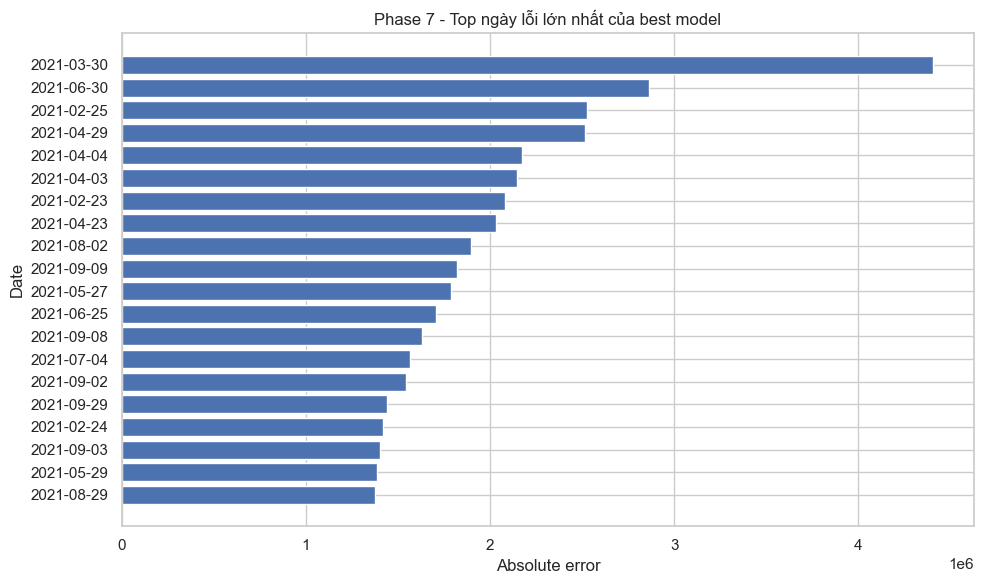

In [57]:
# Phase 7 - Cell 8 - Biểu đồ top error days
plot_top_error = phase7_top_error_days.sort_values('model_abs_error')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_top_error[DATE_COL].dt.strftime('%Y-%m-%d'), plot_top_error['model_abs_error'])
ax.set_title('Phase 7 - Top ngày lỗi lớn nhất của best model')
ax.set_xlabel('Absolute error')
ax.set_ylabel('Date')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase7_top_error_days.png', dpi=150)
plt.show()


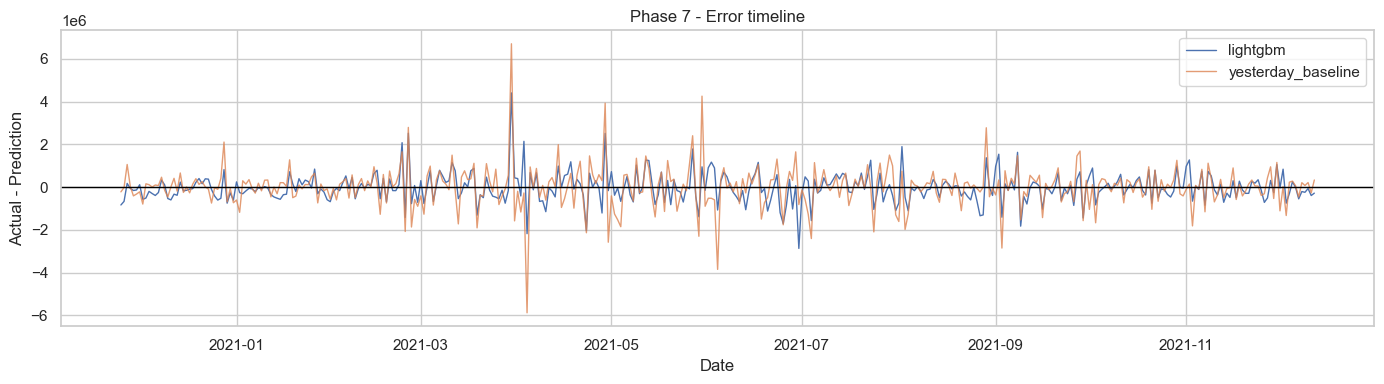

In [58]:
# Phase 7 - Cell 9 - Biểu đồ error timeline
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(error_detail[DATE_COL], error_detail['model_error'], label=best_model_name, linewidth=1)
ax.plot(error_detail[DATE_COL], error_detail['baseline_error'], label=baseline_name, linewidth=1, alpha=0.8)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Phase 7 - Error timeline')
ax.set_xlabel('Date')
ax.set_ylabel('Actual - Prediction')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase7_error_timeline.png', dpi=150)
plt.show()


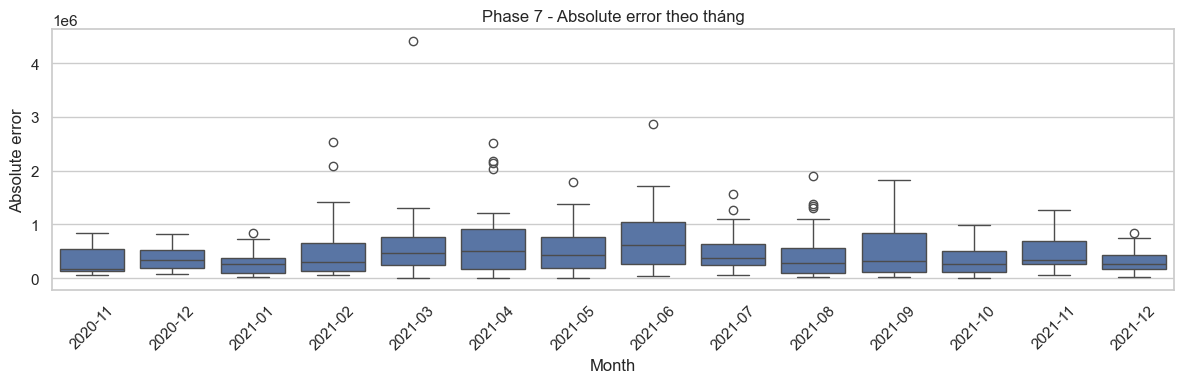

In [59]:
# Phase 7 - Cell 10 - Boxplot absolute error theo tháng
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=error_detail, x='month', y='model_abs_error', ax=ax)
ax.set_title('Phase 7 - Absolute error theo tháng')
ax.set_xlabel('Month')
ax.set_ylabel('Absolute error')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase7_abs_error_by_month.png', dpi=150)
plt.show()


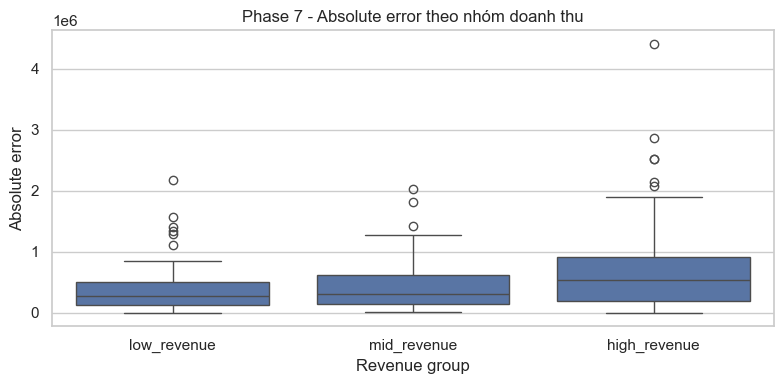

In [60]:
# Phase 7 - Cell 11 - Boxplot absolute error theo nhóm doanh thu
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=error_detail, x='revenue_group', y='model_abs_error', ax=ax)
ax.set_title('Phase 7 - Absolute error theo nhóm doanh thu')
ax.set_xlabel('Revenue group')
ax.set_ylabel('Absolute error')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase7_abs_error_by_revenue_group.png', dpi=150)
plt.show()


In [61]:
# Phase 7 - Cell 12 - Kiểm tra kết quả Phase 7
assert (MODEL_TABLE_DIR / 'phase7_top_error_days.csv').exists(), 'Thiếu phase7_top_error_days.csv'
assert (MODEL_TABLE_DIR / 'phase7_error_by_month.csv').exists(), 'Thiếu phase7_error_by_month.csv'
assert (MODEL_TABLE_DIR / 'phase7_error_by_weekday.csv').exists(), 'Thiếu phase7_error_by_weekday.csv'
assert (MODEL_TABLE_DIR / 'phase7_error_by_revenue_group.csv').exists(), 'Thiếu phase7_error_by_revenue_group.csv'
assert (MODEL_TABLE_DIR / 'phase7_error_feature_review.csv').exists(), 'Thiếu phase7_error_feature_review.csv'

phase7_done = pd.DataFrame([
    {'item': 'best_model', 'value': best_model_name},
    {'item': 'top_error_days', 'value': len(phase7_top_error_days)},
    {'item': 'model_win_rate_vs_baseline', 'value': error_detail['model_better_than_baseline'].mean()},
    {'item': 'max_abs_error', 'value': error_detail['model_abs_error'].max()},
    {'item': 'mean_error_actual_minus_pred', 'value': error_detail['model_error'].mean()},
])

print(phase7_done.to_string(index=False))


                        item           value
                  best_model        lightgbm
              top_error_days              20
  model_win_rate_vs_baseline        0.603133
               max_abs_error  4407687.088309
mean_error_actual_minus_pred   -26446.716073


## Kết luận Phase 7 - Phân tích lỗi model

### 1. Phase này trả lời câu hỏi gì?

Phase 7 không train thêm model mới. Mục tiêu của phase này là đọc kỹ phần sai của model tốt nhất từ Phase 5 để hiểu model đang yếu ở đâu. Nếu chỉ nhìn một con số WAPE tổng, ta biết model tốt hay xấu trung bình, nhưng chưa biết model sai vào ngày nào, sai theo nhóm nào, và sai theo kiểu nào.

Trong phase này, lỗi được hiểu như sau:

- `error = Revenue thực tế - Revenue dự báo`. Nếu error dương, model dự báo thấp hơn thực tế. Nếu error âm, model dự báo cao hơn thực tế.
- `absolute error = |error|`. Chỉ đo độ lớn sai số, không quan tâm sai cao hay sai thấp.
- `WAPE = tổng absolute error / tổng Revenue thực tế`. Metric này cho biết tổng sai số chiếm bao nhiêu phần trăm tổng doanh thu.
- `win rate` là tỷ lệ ngày model ML sai ít hơn baseline `yesterday_baseline`.

### 2. Kết quả tổng quan

Trên validation, LightGBM vẫn tốt hơn baseline rõ ràng:

- Model thắng baseline ở khoảng **60.31% số ngày validation**.
- MAE của model khoảng **490,332/ngày**, thấp hơn baseline khoảng **628,530/ngày**.
- Điều này có nghĩa là nếu nhìn trung bình từng ngày, model ML giảm được sai số đáng kể so với cách dự báo đơn giản bằng doanh thu ngày hôm trước.

Tuy nhiên, model không thắng baseline ở mọi ngày. Một số ngày biến động mạnh vẫn làm model sai lớn. Vì vậy Phase 7 không kết luận rằng model đã hoàn hảo; phase này chỉ kết luận rằng model tốt hơn baseline nhưng vẫn có vùng yếu cần hiểu rõ.

### 3. Ngày sai lớn nhất

Ngày model sai lớn nhất là **2021-03-30**:

- Revenue thực tế khoảng **10.80M**.
- Model dự báo khoảng **6.39M**.
- Sai số tuyệt đối khoảng **4.41M**.

Đây là kiểu lỗi rất quan trọng với bài toán doanh thu: model không bắt được một ngày doanh thu tăng vọt. Các feature lag/rolling thường học theo lịch sử gần đây, nên nếu một ngày có spike do khuyến mãi, campaign, mùa vụ đặc biệt hoặc yếu tố vận hành mà feature chưa mô tả được, model dễ dự báo thấp hơn thực tế.

### 4. Lỗi theo thứ trong tuần

Theo weekday, **Sunday** là nhóm yếu nhất:

- Sunday WAPE khoảng **20.36%**.
- Monday WAPE thấp nhất, khoảng **14.02%**.

Điều này cho thấy model có học được pattern theo tuần, nhưng chưa xử lý đều mọi ngày trong tuần. Sunday có thể có hành vi mua hàng khác các ngày thường, hoặc có nhiều ngày doanh thu thấp/bất thường hơn. Vì vậy Phase 9 có lý do để thử thêm calendar features như `is_sunday`, `is_monday`, `dow_sin`, `dow_cos`.

### 5. Lỗi theo nhóm doanh thu

Theo nhóm doanh thu, `low_revenue` là nhóm có WAPE cao nhất:

- `low_revenue` WAPE khoảng **28.32%**.
- `high_revenue` có MAE lớn nhất, khoảng **682,277**, nhưng WAPE thấp hơn vì mẫu số doanh thu lớn.

Điểm này cần đọc cẩn thận. Với ngày doanh thu cao, sai số tiền tuyệt đối có thể lớn nhưng tỷ lệ sai so với doanh thu vẫn chấp nhận được hơn. Ngược lại, ngày doanh thu thấp chỉ cần sai vài trăm nghìn cũng làm WAPE tăng mạnh. Vì vậy nếu mục tiêu kinh doanh quan tâm nhiều đến ngày thấp doanh thu, cần kiểm tra riêng nhóm `low_revenue`, không chỉ nhìn WAPE tổng.

### 6. Ý nghĩa cho phase sau

Kết luận quan trọng của Phase 7 là: model hiện tại đủ tốt để làm candidate chính, nhưng hướng cải thiện nên tập trung vào các lỗi có pattern rõ:

- Ngày doanh thu spike/drop mạnh.
- Sunday hoặc nhóm weekday yếu.
- Nhóm `low_revenue`, nơi WAPE cao nhất.
- Các ngày mà baseline đơn giản lại thắng model ML.

Phase 8 sẽ giải thích model đang dựa vào feature nào. Sau đó Phase 9 mới thử cải thiện có kiểm soát, thay vì tuning mù hoặc thêm feature quá rộng.


## Phase 8 - Giải thích model

### Mục tiêu

- Hiểu best model đang dựa nhiều vào feature nào.
- Kiểm tra top feature có hợp lý và có rủi ro leakage không.
- Ghi nhận rủi ro để Phase 9 xử lý, chưa sửa model ở phase này.


In [62]:
# Phase 8 - Cell 1 - Load best model và dữ liệu cần giải thích
phase5_best_model_summary = pd.read_csv(MODEL_TABLE_DIR / 'phase5_best_model_summary.csv')
phase7_top_error_days = pd.read_csv(MODEL_TABLE_DIR / 'phase7_top_error_days.csv', parse_dates=[DATE_COL])
modeling_feature_metadata = pd.read_csv(input_files['modeling_feature_metadata'])
final_feature_scores = pd.read_csv(input_files['final_feature_scores'])

best_model_name = phase5_best_model_summary.loc[
    phase5_best_model_summary['item'] == 'best_model_by_validation_wape', 'value'
].iloc[0]

print('best_model:', best_model_name)
print('selected feature count:', len(selected_features))


best_model: lightgbm
selected feature count: 21


In [63]:
# Phase 8 - Cell 2 - Lấy lại model để tính feature importance
# Nếu chạy notebook liền mạch từ Phase 5 thì dùng model đã train.
# Nếu chỉ chạy riêng Phase 8, cell này train lại lightgbm bằng train set để lấy importance.
if 'models' in globals() and best_model_name in models:
    best_model = models[best_model_name]
else:
    from lightgbm import LGBMRegressor
    from sklearn.linear_model import LinearRegression, Ridge
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler

    train_df = pd.read_csv(MODEL_TABLE_DIR / 'modeling_train_dataset.csv', parse_dates=[DATE_COL])
    X_train = train_df[selected_features].copy()
    y_train = train_df[TARGET_COL].copy()

    if best_model_name == 'lightgbm':
        best_model = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
    elif best_model_name == 'ridge_regression_scaled':
        best_model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    else:
        best_model = make_pipeline(StandardScaler(), LinearRegression())

    best_model.fit(X_train, y_train)

print(best_model)


LGBMRegressor(learning_rate=0.05, n_estimators=300, n_jobs=-1, random_state=42,
              verbosity=-1)


In [64]:
# Phase 8 - Cell 3 - Tính feature importance
if hasattr(best_model, 'feature_importances_'):
    importance_values = best_model.feature_importances_
elif hasattr(best_model, 'named_steps') and hasattr(best_model.named_steps[list(best_model.named_steps.keys())[-1]], 'coef_'):
    last_step = best_model.named_steps[list(best_model.named_steps.keys())[-1]]
    importance_values = np.abs(last_step.coef_)
else:
    raise ValueError('Model hiện tại chưa hỗ trợ feature importance đơn giản.')

phase8_feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': importance_values,
})

phase8_feature_importance['importance_share'] = phase8_feature_importance['importance'] / phase8_feature_importance['importance'].sum()
phase8_feature_importance = phase8_feature_importance.sort_values('importance', ascending=False).reset_index(drop=True)
phase8_feature_importance['rank'] = phase8_feature_importance.index + 1

phase8_feature_importance.to_csv(MODEL_TABLE_DIR / 'phase8_feature_importance.csv', index=False, encoding='utf-8-sig')
print(phase8_feature_importance.to_string(index=False))


                      feature  importance  importance_share  rank
                 day_of_month         914          0.101556     1
        Revenue_pct_change_7d         800          0.088889     2
               Revenue_lag_1d         712          0.079111     3
              Revenue_lag_28d         687          0.076333     4
              Revenue_diff_1d         620          0.068889     5
          Gross_Profit_lag_1d         502          0.055778     6
           page_views_lag_14d         486          0.054000     7
     Revenue_rolling_28d_mean         478          0.053111     8
Gross_Margin_rolling_28d_mean         461          0.051222     9
          Gross_Margin_lag_7d         453          0.050333    10
      Revenue_rolling_7d_mean         446          0.049556    11
Gross_Profit_rolling_28d_mean         428          0.047556    12
          Gross_Profit_lag_7d         416          0.046222    13
          Gross_Margin_lag_1d         398          0.044222    14
 Gross_Pro

In [65]:
# Phase 8 - Cell 4 - Importance tích lũy
phase8_cumulative_importance = phase8_feature_importance.copy()
phase8_cumulative_importance['cumulative_importance_share'] = phase8_cumulative_importance['importance_share'].cumsum()
phase8_cumulative_importance.to_csv(MODEL_TABLE_DIR / 'phase8_cumulative_importance.csv', index=False, encoding='utf-8-sig')

print(phase8_cumulative_importance[['rank', 'feature', 'importance_share', 'cumulative_importance_share']].to_string(index=False))


 rank                       feature  importance_share  cumulative_importance_share
    1                  day_of_month          0.101556                     0.101556
    2         Revenue_pct_change_7d          0.088889                     0.190444
    3                Revenue_lag_1d          0.079111                     0.269556
    4               Revenue_lag_28d          0.076333                     0.345889
    5               Revenue_diff_1d          0.068889                     0.414778
    6           Gross_Profit_lag_1d          0.055778                     0.470556
    7            page_views_lag_14d          0.054000                     0.524556
    8      Revenue_rolling_28d_mean          0.053111                     0.577667
    9 Gross_Margin_rolling_28d_mean          0.051222                     0.628889
   10           Gross_Margin_lag_7d          0.050333                     0.679222
   11       Revenue_rolling_7d_mean          0.049556                     0.728778
   1

In [66]:
# Phase 8 - Cell 5 - Review top feature theo metadata và leakage
metadata_cols = [
    'feature', 'source_table', 'family', 'type', 'leakage_risk',
    'quality_action', 'relevance_action', 'stable_flag', 'handoff_note'
]
metadata_cols = [col for col in metadata_cols if col in modeling_feature_metadata.columns]

score_cols = ['feature', 'max_abs_spearman', 'missing_pct']
score_cols = [col for col in score_cols if col in final_feature_scores.columns]

top_feature_count = 10
phase8_top_feature_review = phase8_feature_importance.head(top_feature_count).merge(
    modeling_feature_metadata[metadata_cols],
    on='feature',
    how='left'
).merge(
    final_feature_scores[score_cols],
    on='feature',
    how='left'
)

phase8_top_feature_review['review_note'] = np.where(
    phase8_top_feature_review['leakage_risk'].astype(str).str.contains('low', case=False, na=False),
    'Rủi ro leakage thấp theo metadata, vẫn cần đảm bảo lag/rolling dùng quá khứ.',
    'Cần review kỹ leakage hoặc thời điểm có dữ liệu.'
)

phase8_top_feature_review.to_csv(MODEL_TABLE_DIR / 'phase8_top_feature_review.csv', index=False, encoding='utf-8-sig')
print(phase8_top_feature_review.to_string(index=False))


                      feature  importance  importance_share  rank source_table       family     type   leakage_risk stable_flag                         handoff_note  max_abs_spearman  missing_pct                                                                  review_note
                 day_of_month         914          0.101556     1         Date day_of_month calendar  low known-now        PASS Được chọn vào dataset modeling cuối.          0.303698         0.00 Rủi ro leakage thấp theo metadata, vẫn cần đảm bảo lag/rolling dùng quá khứ.
        Revenue_pct_change_7d         800          0.088889     2        sales      Revenue   change low if shifted        PASS Được chọn vào dataset modeling cuối.          0.257466         0.18 Rủi ro leakage thấp theo metadata, vẫn cần đảm bảo lag/rolling dùng quá khứ.
               Revenue_lag_1d         712          0.079111     3        sales      Revenue      lag low if shifted        PASS Được chọn vào dataset modeling cuối.          0.86225

In [67]:
# Phase 8 - Cell 6 - Đối chiếu top feature với các ngày lỗi lớn
error_review_features = phase8_feature_importance.head(8)['feature'].tolist()
phase2_modeling_table = pd.read_csv(MODEL_TABLE_DIR / 'phase2_modeling_table.csv', parse_dates=[DATE_COL])

phase8_top_error_feature_context = phase7_top_error_days[[DATE_COL, TARGET_COL, 'model_error', 'model_abs_error']].merge(
    phase2_modeling_table[[DATE_COL] + error_review_features],
    on=DATE_COL,
    how='left'
)

phase8_top_error_feature_context.to_csv(MODEL_TABLE_DIR / 'phase8_top_error_feature_context.csv', index=False, encoding='utf-8-sig')
print(phase8_top_error_feature_context.head(10).to_string(index=False))


      Date     Revenue   model_error  model_abs_error  day_of_month  Revenue_pct_change_7d  Revenue_lag_1d  Revenue_lag_28d  Revenue_diff_1d  Gross_Profit_lag_1d  page_views_lag_14d  Revenue_rolling_28d_mean
2021-03-30 10795905.35  4.407687e+06     4.407687e+06            30              -0.031386      4090090.60        679248.37        561160.71            354866.66            159810.0              3.261269e+06
2021-06-30  5094915.79 -2.863413e+06     2.863413e+06            30               0.151530      5907160.01       6960798.21       1651616.05             -4591.10            229232.0              4.138398e+06
2021-02-25  5675843.97  2.523695e+06     2.523695e+06            25               0.665884      2880648.13       2405871.45      -2071416.71            503152.63            120219.0              2.122296e+06
2021-04-29  9535515.05  2.515907e+06     2.515907e+06            29               0.209553      5606431.49       9027075.84        302888.62           1270948.50       

In [68]:
# Phase 8 - Cell 7 - Kết luận giải thích model
importance_top_3_share = phase8_feature_importance.head(3)['importance_share'].sum()
importance_top_5_share = phase8_feature_importance.head(5)['importance_share'].sum()
importance_top_10_share = phase8_feature_importance.head(10)['importance_share'].sum()

top_features_text = ', '.join(phase8_feature_importance.head(5)['feature'].tolist())
low_leakage_mask = phase8_top_feature_review['leakage_risk'].astype(str).str.contains('low', case=False, na=False)
leakage_review_count = int((~low_leakage_mask).sum())

phase8_model_explanation_summary = pd.DataFrame([
    {'item': 'best_model', 'value': best_model_name},
    {'item': 'top_5_features', 'value': top_features_text},
    {'item': 'top_3_importance_share', 'value': importance_top_3_share},
    {'item': 'top_5_importance_share', 'value': importance_top_5_share},
    {'item': 'top_10_importance_share', 'value': importance_top_10_share},
    {'item': 'top_feature', 'value': phase8_feature_importance.loc[0, 'feature']},
    {'item': 'top_feature_importance_share', 'value': phase8_feature_importance.loc[0, 'importance_share']},
    {'item': 'top_feature_review_count', 'value': top_feature_count},
    {'item': 'top_feature_possible_leakage_review_count', 'value': leakage_review_count},
])

phase8_model_explanation_summary.to_csv(MODEL_TABLE_DIR / 'phase8_model_explanation_summary.csv', index=False, encoding='utf-8-sig')
print(phase8_model_explanation_summary.to_string(index=False))


                                     item                                                                                 value
                               best_model                                                                              lightgbm
                           top_5_features day_of_month, Revenue_pct_change_7d, Revenue_lag_1d, Revenue_lag_28d, Revenue_diff_1d
                   top_3_importance_share                                                                              0.269556
                   top_5_importance_share                                                                              0.414778
                  top_10_importance_share                                                                              0.679222
                              top_feature                                                                          day_of_month
             top_feature_importance_share                                                               

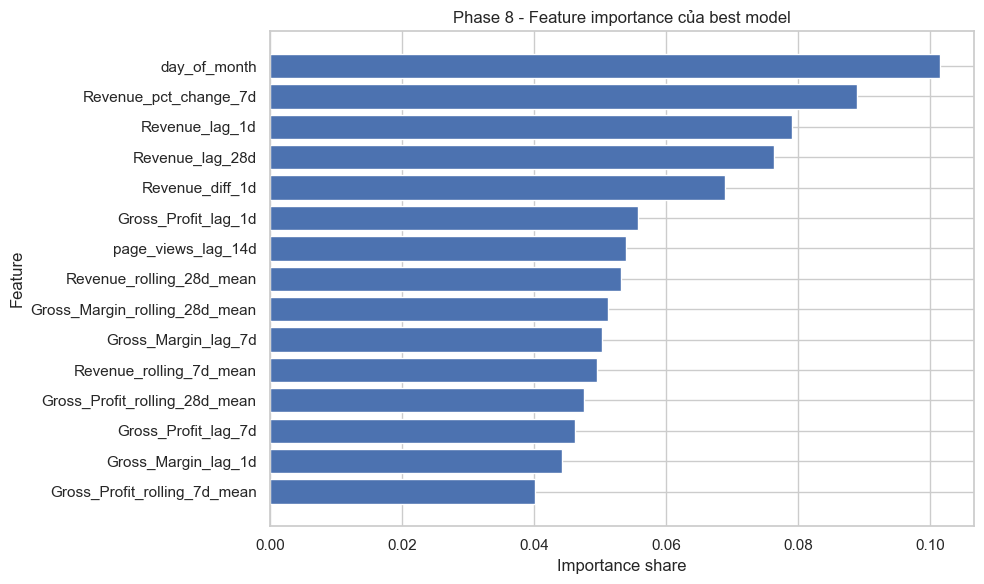

In [69]:
# Phase 8 - Cell 8 - Biểu đồ feature importance
plot_importance = phase8_feature_importance.head(15).sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_importance['feature'], plot_importance['importance_share'])
ax.set_title('Phase 8 - Feature importance của best model')
ax.set_xlabel('Importance share')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase8_feature_importance.png', dpi=150)
plt.show()


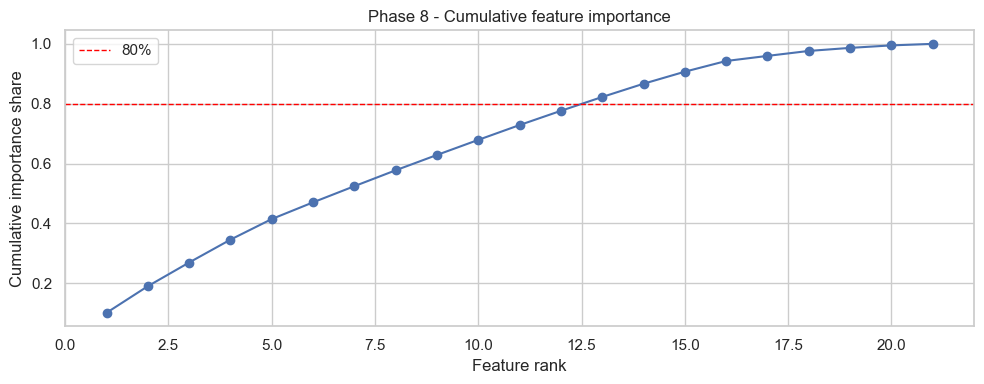

In [70]:
# Phase 8 - Cell 9 - Biểu đồ cumulative importance
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(phase8_cumulative_importance['rank'], phase8_cumulative_importance['cumulative_importance_share'], marker='o')
ax.axhline(0.8, color='red', linestyle='--', linewidth=1, label='80%')
ax.set_title('Phase 8 - Cumulative feature importance')
ax.set_xlabel('Feature rank')
ax.set_ylabel('Cumulative importance share')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase8_cumulative_importance.png', dpi=150)
plt.show()


In [71]:
# Phase 8 - Cell 10 - Kiểm tra kết quả Phase 8
assert (MODEL_TABLE_DIR / 'phase8_feature_importance.csv').exists(), 'Thiếu phase8_feature_importance.csv'
assert (MODEL_TABLE_DIR / 'phase8_top_feature_review.csv').exists(), 'Thiếu phase8_top_feature_review.csv'
assert (MODEL_TABLE_DIR / 'phase8_cumulative_importance.csv').exists(), 'Thiếu phase8_cumulative_importance.csv'
assert (MODEL_TABLE_DIR / 'phase8_model_explanation_summary.csv').exists(), 'Thiếu phase8_model_explanation_summary.csv'
assert len(phase8_feature_importance) == len(selected_features), 'Importance phải đủ 21 feature.'
assert np.isclose(phase8_feature_importance['importance_share'].sum(), 1.0), 'Importance share phải cộng lại gần 1.'

phase8_done = pd.DataFrame([
    {'item': 'best_model', 'value': best_model_name},
    {'item': 'feature_importance_rows', 'value': len(phase8_feature_importance)},
    {'item': 'top_feature', 'value': phase8_feature_importance.loc[0, 'feature']},
    {'item': 'top_feature_importance_share', 'value': phase8_feature_importance.loc[0, 'importance_share']},
    {'item': 'top_5_importance_share', 'value': importance_top_5_share},
])

print(phase8_done.to_string(index=False))


                        item        value
                  best_model     lightgbm
     feature_importance_rows           21
                 top_feature day_of_month
top_feature_importance_share     0.101556
      top_5_importance_share     0.414778


## Kết luận Phase 8 - Giải thích model

### 1. Phase này trả lời câu hỏi gì?

Phase 8 dùng feature importance để hiểu LightGBM đang dựa nhiều vào những biến nào khi dự báo doanh thu. Đây là bước giải thích model, không phải bước chọn model mới.

Feature importance cho biết feature nào được model sử dụng nhiều trong các split của cây. Tuy nhiên, cần hiểu đúng: importance cao không có nghĩa là feature đó là nguyên nhân trực tiếp làm doanh thu tăng hoặc giảm. Nó chỉ cho biết feature đó hữu ích cho model trong việc tách dữ liệu và giảm lỗi dự báo.

### 2. Feature quan trọng nhất

Feature quan trọng nhất là **`day_of_month`**, chiếm khoảng **10.16%** tổng importance.

Điều này hợp lý với bài toán daily revenue forecasting vì doanh thu thường có pattern theo ngày trong tháng. Ví dụ, đầu tháng, giữa tháng, cuối tháng có thể khác nhau do lương, campaign, hành vi mua hàng, hoặc hoạt động vận hành.

### 3. Top feature model đang dùng

Top 5 feature gồm:

- `day_of_month`
- `Revenue_pct_change_7d`
- `Revenue_lag_1d`
- `Revenue_lag_28d`
- `Revenue_diff_1d`

Top 5 feature chiếm khoảng **41.48%** tổng importance, còn top 10 chiếm khoảng **67.92%**. Như vậy model không phụ thuộc vào đúng một feature duy nhất, nhưng phần lớn sức mạnh dự báo vẫn đến từ một nhóm feature khá rõ.

### 4. Model đang học từ những nhóm tín hiệu nào?

Có thể gom các feature quan trọng thành ba nhóm chính:

- **Calendar pattern**: ví dụ `day_of_month`, `cos_month`, `quarter`, `is_month_start`, `is_month_end`. Nhóm này giúp model biết vị trí của ngày trong tháng/năm.
- **Lịch sử doanh thu gần đây**: ví dụ `Revenue_lag_1d`, `Revenue_lag_28d`, `Revenue_rolling_7d_mean`, `Revenue_rolling_28d_mean`. Nhóm này giúp model bám theo mức doanh thu gần nhất.
- **Biến động và tín hiệu liên quan**: ví dụ `Revenue_pct_change_7d`, `Revenue_diff_1d`, gross profit/margin lag/rolling, `page_views_lag_14d`. Nhóm này giúp model nhận biết xu hướng tăng/giảm và tín hiệu nhu cầu từ web traffic.

Cách học này phù hợp với bài toán dự báo doanh thu theo ngày: model chủ yếu dựa vào lịch thời gian và lịch sử doanh thu.

### 5. Kiểm tra leakage

Không có top feature nào bị flag leakage nghiêm trọng theo metadata hiện tại. Các feature revenue/gross profit/margin đều được dùng ở dạng lag hoặc rolling đã shift, nghĩa là chỉ sử dụng thông tin quá khứ để dự báo tương lai.

Điểm này quan trọng vì nếu feature chứa thông tin của chính ngày cần dự báo, metric validation/test có thể đẹp giả tạo. Phase 8 cho thấy các top feature hiện tại đủ hợp lý để tiếp tục dùng trong Phase 9 và Phase 10.

### 6. Hạn chế còn lại

Model hiện tại vẫn thiếu các tín hiệu giải thích ngày bất thường như:

- Khuyến mãi hoặc campaign.
- Ngày lễ, payday, sự kiện đặc biệt.
- Thay đổi vận hành hoặc tồn kho.
- Shock feature thể hiện doanh thu vừa tăng/giảm bất thường.

Vì vậy, dù feature importance hợp lý, model vẫn có thể sai mạnh ở những ngày spike/drop mà lịch sử gần đây không dự báo được. Đây là lý do Phase 9 cần cải thiện có kiểm soát, đặc biệt quanh calendar features và cấu hình LightGBM.


## Phase 9 - Cải thiện model

### Mục tiêu

- Cải thiện model có kiểm soát trên validation, không dùng test để tuning hoặc chọn model.
- Thử các hướng cải thiện dễ hiểu: model mốc Phase 5, regularization, learning rate nhỏ kết hợp early stopping, và cyclic calendar nếu cần.
- Kiểm tra riêng các điểm yếu đã thấy ở Phase 7: Sunday và nhóm `low_revenue`.
- Chỉ nhận là cải thiện thật nếu validation WAPE giảm ít nhất **0.003** so với Phase 5; nếu không, giữ model Phase 5 và ghi rõ là không cải thiện đáng kể.


In [72]:
# Phase 9 - Cell 1 - Load dữ liệu và kết quả phase trước
import json
import lightgbm as lgb
from lightgbm import LGBMRegressor

train_df = pd.read_csv(MODEL_TABLE_DIR / 'modeling_train_dataset.csv', parse_dates=[DATE_COL])
validation_df = pd.read_csv(MODEL_TABLE_DIR / 'modeling_validation_dataset.csv', parse_dates=[DATE_COL])
phase5_predictions = pd.read_csv(MODEL_TABLE_DIR / 'phase5_model_predictions_validation.csv', parse_dates=[DATE_COL])
phase5_best_model_summary = pd.read_csv(MODEL_TABLE_DIR / 'phase5_best_model_summary.csv')
phase7_error_by_weekday = pd.read_csv(MODEL_TABLE_DIR / 'phase7_error_by_weekday.csv')
phase7_error_by_revenue_group = pd.read_csv(MODEL_TABLE_DIR / 'phase7_error_by_revenue_group.csv')

X_train = train_df[selected_features].copy()
y_train = train_df[TARGET_COL].copy()
X_validation = validation_df[selected_features].copy()
y_validation = validation_df[TARGET_COL].copy()

print('train:', train_df.shape)
print('validation:', validation_df.shape)
print('selected_features:', len(selected_features))


train: (2871, 24)
validation: (383, 24)
selected_features: 21


In [73]:
# Phase 9 - Cell 2 - Chốt metric mốc và ngưỡng cải thiện
PHASE9_MATERIAL_WAPE_THRESHOLD = 0.003
CYCLIC_CALENDAR_FEATURES = ['is_sunday', 'is_monday', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

phase5_best_model_name = phase5_best_model_summary.loc[
    phase5_best_model_summary['item'] == 'best_model_by_validation_wape', 'value'
].iloc[0]
phase5_best_wape = float(phase5_best_model_summary.loc[
    phase5_best_model_summary['item'] == 'best_model_validation_wape', 'value'
].iloc[0])
baseline_wape = float(phase5_best_model_summary.loc[
    phase5_best_model_summary['item'] == 'baseline_validation_wape', 'value'
].iloc[0])

print('phase5_best_model:', phase5_best_model_name)
print('phase5_best_wape:', phase5_best_wape)
print('baseline_wape:', baseline_wape)
print('material_threshold:', PHASE9_MATERIAL_WAPE_THRESHOLD)


phase5_best_model: lightgbm
phase5_best_wape: 0.17731573417720944
baseline_wape: 0.2272912016562102
material_threshold: 0.003


In [74]:
# Phase 9 - Cell 3 - Tạo bảng diagnosis dễ đọc
phase5_sunday_wape = float(phase7_error_by_weekday.loc[
    phase7_error_by_weekday['weekday'] == 'Sunday', 'model_wape'
].iloc[0])
phase5_low_revenue_wape = float(phase7_error_by_revenue_group.loc[
    phase7_error_by_revenue_group['revenue_group'] == 'low_revenue', 'model_wape'
].iloc[0])

phase9_problem_diagnosis = pd.DataFrame([
    {'item': 'phase5_best_model', 'value': phase5_best_model_name, 'plain_language_note': 'Model mốc tốt nhất từ Phase 5.'},
    {'item': 'phase5_best_wape', 'value': phase5_best_wape, 'plain_language_note': 'WAPE mốc để so sánh. Phase 9 phải thắng mốc này đủ rõ.'},
    {'item': 'phase5_sunday_wape', 'value': phase5_sunday_wape, 'plain_language_note': 'Sunday là nhóm weekday yếu cần kiểm tra riêng.'},
    {'item': 'phase5_low_revenue_wape', 'value': phase5_low_revenue_wape, 'plain_language_note': 'Low revenue là nhóm doanh thu yếu cần kiểm tra riêng.'},
    {'item': 'material_wape_threshold', 'value': PHASE9_MATERIAL_WAPE_THRESHOLD, 'plain_language_note': 'Ngưỡng tối thiểu để nhận là cải thiện đáng kể.'},
])

phase9_problem_diagnosis.to_csv(MODEL_TABLE_DIR / 'phase9_problem_diagnosis.csv', index=False, encoding='utf-8-sig')
print(phase9_problem_diagnosis.to_string(index=False))


                   item     value                                    plain_language_note
      phase5_best_model  lightgbm                         Model mốc tốt nhất từ Phase 5.
       phase5_best_wape  0.177316 WAPE mốc để so sánh. Phase 9 phải thắng mốc này đủ rõ.
     phase5_sunday_wape  0.203558         Sunday là nhóm weekday yếu cần kiểm tra riêng.
phase5_low_revenue_wape  0.283156  Low revenue là nhóm doanh thu yếu cần kiểm tra riêng.
material_wape_threshold     0.003         Ngưỡng tối thiểu để nhận là cải thiện đáng kể.


In [75]:
# Phase 9 - Cell 4 - Tạo cyclic calendar features
def add_cyclic_calendar_features(data):
    data = data.copy()
    day_of_week = data[DATE_COL].dt.dayofweek
    month_index = data[DATE_COL].dt.month - 1
    data['is_sunday'] = (day_of_week == 6).astype(int)
    data['is_monday'] = (day_of_week == 0).astype(int)
    data['dow_sin'] = np.sin(2 * np.pi * day_of_week / 7)
    data['dow_cos'] = np.cos(2 * np.pi * day_of_week / 7)
    data['month_sin'] = np.sin(2 * np.pi * month_index / 12)
    data['month_cos'] = np.cos(2 * np.pi * month_index / 12)
    return data

train_calendar_df = add_cyclic_calendar_features(train_df)
validation_calendar_df = add_cyclic_calendar_features(validation_df)

print(train_calendar_df[[DATE_COL] + CYCLIC_CALENDAR_FEATURES].head().to_string(index=False))


      Date  is_sunday  is_monday   dow_sin   dow_cos  month_sin  month_cos
2013-01-15          0          0  0.781831  0.623490        0.0        1.0
2013-01-16          0          0  0.974928 -0.222521        0.0        1.0
2013-01-17          0          0  0.433884 -0.900969        0.0        1.0
2013-01-18          0          0 -0.433884 -0.900969        0.0        1.0
2013-01-19          0          0 -0.974928 -0.222521        0.0        1.0


In [76]:
# Phase 9 - Cell 5 - Tạo feature set cho thí nghiệm
selected_features_cyclic_calendar = selected_features + [
    col for col in CYCLIC_CALENDAR_FEATURES if col not in selected_features
]

feature_sets = {
    'selected_features_21': selected_features,
    'selected_features_cyclic_calendar': selected_features_cyclic_calendar,
}
train_feature_frames = {
    'selected_features_21': train_df,
    'selected_features_cyclic_calendar': train_calendar_df,
}
validation_feature_frames = {
    'selected_features_21': validation_df,
    'selected_features_cyclic_calendar': validation_calendar_df,
}

feature_set_summary = pd.DataFrame([
    {'feature_set': name, 'feature_count': len(features)}
    for name, features in feature_sets.items()
])
print(feature_set_summary.to_string(index=False))


                      feature_set  feature_count
             selected_features_21             21
selected_features_cyclic_calendar             27


In [77]:
# Phase 9 - Cell 6 - Khai báo model candidates
candidate_specs = [
    {
        'model_name': 'lightgbm',
        'experiment_group': 'reference',
        'feature_set': 'selected_features_21',
        'use_early_stopping': False,
        'plain_language_reason': 'Giữ đúng LightGBM Phase 5 làm mốc; nếu các cấu hình mới không thắng đủ rõ thì quay về model này.',
        'params': {'n_estimators': 300, 'learning_rate': 0.05, 'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1},
    },
    {
        'model_name': 'lgbm_regularized_balanced',
        'experiment_group': 'regularized',
        'feature_set': 'selected_features_21',
        'use_early_stopping': True,
        'plain_language_reason': 'Tăng min_child_samples và thêm L1/L2 để model bớt học vẹt nhóm low revenue.',
        'params': {'n_estimators': 800, 'learning_rate': 0.03, 'num_leaves': 31, 'max_depth': -1, 'min_child_samples': 40, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.9, 'colsample_bytree': 0.9, 'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1},
    },
    {
        'model_name': 'lgbm_regularized_strong',
        'experiment_group': 'regularized',
        'feature_set': 'selected_features_21',
        'use_early_stopping': True,
        'plain_language_reason': 'Regularization mạnh hơn để kiểm tra model có đang quá linh hoạt trên ngày bất thường không.',
        'params': {'n_estimators': 1000, 'learning_rate': 0.03, 'num_leaves': 15, 'max_depth': 10, 'min_child_samples': 50, 'reg_alpha': 0.2, 'reg_lambda': 2.0, 'subsample': 0.9, 'colsample_bytree': 0.85, 'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1},
    },
    {
        'model_name': 'lgbm_slow_learning_regularized',
        'experiment_group': 'slow_learning',
        'feature_set': 'selected_features_21',
        'use_early_stopping': True,
        'plain_language_reason': 'Learning rate nhỏ hơn và nhiều cây hơn để model học chậm, kết hợp early stopping để không train thừa.',
        'params': {'n_estimators': 1200, 'learning_rate': 0.01, 'num_leaves': 31, 'max_depth': -1, 'min_child_samples': 40, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.9, 'colsample_bytree': 0.9, 'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1},
    },
    {
        'model_name': 'lgbm_slow_learning_cyclic_calendar',
        'experiment_group': 'calendar_rescue',
        'feature_set': 'selected_features_cyclic_calendar',
        'use_early_stopping': True,
        'plain_language_reason': 'Thử is_sunday/is_monday và sin/cos để xử lý Sunday riêng thay vì gộp weekend.',
        'params': {'n_estimators': 1200, 'learning_rate': 0.01, 'num_leaves': 31, 'max_depth': -1, 'min_child_samples': 40, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.9, 'colsample_bytree': 0.9, 'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1},
    },
]

print('Số candidate:', len(candidate_specs))
print([spec['model_name'] for spec in candidate_specs])


Số candidate: 5
['lightgbm', 'lgbm_regularized_balanced', 'lgbm_regularized_strong', 'lgbm_slow_learning_regularized', 'lgbm_slow_learning_cyclic_calendar']


In [78]:
# Phase 9 - Cell 7 - Lưu catalog giải thích candidates
phase9_candidate_catalog = pd.DataFrame([
    {
        'model_name': spec['model_name'],
        'experiment_group': spec['experiment_group'],
        'feature_set': spec['feature_set'],
        'use_early_stopping': spec['use_early_stopping'],
        'plain_language_reason': spec['plain_language_reason'],
        'params_summary': json.dumps(spec['params'], ensure_ascii=False),
    }
    for spec in candidate_specs
])

phase9_candidate_catalog.to_csv(MODEL_TABLE_DIR / 'phase9_candidate_catalog.csv', index=False, encoding='utf-8-sig')
print(phase9_candidate_catalog[['model_name', 'experiment_group', 'feature_set', 'use_early_stopping']].to_string(index=False))


                        model_name experiment_group                       feature_set  use_early_stopping
                          lightgbm        reference              selected_features_21               False
         lgbm_regularized_balanced      regularized              selected_features_21                True
           lgbm_regularized_strong      regularized              selected_features_21                True
    lgbm_slow_learning_regularized    slow_learning              selected_features_21                True
lgbm_slow_learning_cyclic_calendar  calendar_rescue selected_features_cyclic_calendar                True


In [79]:
# Phase 9 - Cell 8 - Định nghĩa hàm tính metric
def get_model_metrics(actual, prediction):
    error = actual - prediction
    abs_error = error.abs() if hasattr(error, 'abs') else np.abs(error)
    return {
        'mae': float(abs_error.mean()),
        'rmse': float(np.sqrt((error ** 2).mean())),
        'wape': float(abs_error.sum() / actual.sum()),
        'negative_prediction_count': int((prediction < 0).sum()),
        'prediction_mean': float(np.mean(prediction)),
        'prediction_std': float(np.std(prediction, ddof=1)),
        'actual_mean': float(actual.mean()),
        'actual_std': float(actual.std()),
        'std_ratio_pred_vs_actual': float(np.std(prediction, ddof=1) / actual.std()),
    }


def wape_eval(y_true, y_pred):
    denominator = np.sum(y_true)
    if denominator == 0:
        return 'wape', np.inf, False
    return 'wape', float(np.sum(np.abs(y_true - y_pred)) / denominator), False

print('Metric chính: WAPE')
print('Early stopping metric: WAPE')


Metric chính: WAPE
Early stopping metric: WAPE


In [80]:
# Phase 9 - Cell 9 - Định nghĩa hàm train một candidate
def fit_candidate(spec):
    features = feature_sets[spec['feature_set']]
    train_source = train_feature_frames[spec['feature_set']]
    validation_source = validation_feature_frames[spec['feature_set']]
    X_full = train_source[features].copy()
    y_full = train_source[TARGET_COL].copy()
    X_val = validation_source[features].copy()

    model = LGBMRegressor(**spec['params'])
    internal_eval_rows = 0
    refit_on_full_train = False
    early_stopping_metric = 'none'

    if spec['use_early_stopping']:
        split_idx = int(np.floor(len(X_full) * 0.85))
        X_core, X_eval = X_full.iloc[:split_idx], X_full.iloc[split_idx:]
        y_core, y_eval = y_full.iloc[:split_idx], y_full.iloc[split_idx:]
        internal_eval_rows = len(X_eval)
        early_stopping_metric = 'wape'
        early_stopping_params = spec['params'].copy()
        early_stopping_params['metric'] = 'None'
        model = LGBMRegressor(**early_stopping_params)
        model.fit(
            X_core,
            y_core,
            eval_set=[(X_eval, y_eval)],
            eval_metric=wape_eval,
            callbacks=[lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=False)],
        )
        best_iteration = getattr(model, 'best_iteration_', None)
        if best_iteration is None or best_iteration <= 0:
            best_iteration = spec['params']['n_estimators']

        refit_params = spec['params'].copy()
        refit_params['n_estimators'] = int(best_iteration)
        refit_params['metric'] = 'None'
        model = LGBMRegressor(**refit_params)
        model.fit(X_full, y_full)
        refit_on_full_train = True
    else:
        model.fit(X_full, y_full)
        best_iteration = spec['params']['n_estimators']

    prediction = model.predict(X_val)

    return prediction, int(best_iteration), internal_eval_rows, refit_on_full_train, early_stopping_metric

print('fit_candidate ready')


fit_candidate ready


In [81]:
# Phase 9 - Cell 10 - Train candidates và lưu prediction validation
phase9_predictions = validation_df[[DATE_COL, TARGET_COL]].copy()
candidate_result_rows = []

for spec in candidate_specs:
    prediction, best_iteration, internal_eval_rows, refit_on_full_train, early_stopping_metric = fit_candidate(spec)
    metrics = get_model_metrics(y_validation, prediction)
    phase9_predictions[spec['model_name']] = prediction
    candidate_result_rows.append({
        'model_name': spec['model_name'],
        'experiment_group': spec['experiment_group'],
        'feature_set': spec['feature_set'],
        'feature_count': len(feature_sets[spec['feature_set']]),
        'use_early_stopping': spec['use_early_stopping'],
        'internal_eval_rows': internal_eval_rows,
        'refit_on_full_train': refit_on_full_train,
        'early_stopping_metric': early_stopping_metric,
        'best_iteration': best_iteration,
        'params_json': json.dumps(spec['params'], ensure_ascii=False),
        'plain_language_reason': spec['plain_language_reason'],
        **metrics,
    })

print('Đã train candidates:', len(candidate_result_rows))


Đã train candidates: 5


In [82]:
# Phase 9 - Cell 11 - Tạo bảng tuning results
phase9_tuning_results = pd.DataFrame(candidate_result_rows)
phase9_tuning_results['wape_change_vs_phase5'] = phase5_best_wape - phase9_tuning_results['wape']
phase9_tuning_results['materially_better_than_phase5'] = (
    phase9_tuning_results['wape_change_vs_phase5'] >= PHASE9_MATERIAL_WAPE_THRESHOLD
)
phase9_tuning_results = phase9_tuning_results.sort_values(['wape', 'mae']).reset_index(drop=True)

print(phase9_tuning_results[
    ['model_name', 'experiment_group', 'feature_set', 'best_iteration', 'early_stopping_metric', 'refit_on_full_train', 'mae', 'rmse', 'wape', 'wape_change_vs_phase5']
].to_string(index=False))


                        model_name experiment_group                       feature_set  best_iteration early_stopping_metric  refit_on_full_train           mae          rmse     wape  wape_change_vs_phase5
                          lightgbm        reference              selected_features_21             300                  none                False 490332.437051 696490.047757 0.177316               0.000000
           lgbm_regularized_strong      regularized              selected_features_21             692                  wape                 True 493689.990044 677435.730368 0.178530              -0.001214
lgbm_slow_learning_cyclic_calendar  calendar_rescue selected_features_cyclic_calendar             937                  wape                 True 494565.744681 684456.366261 0.178847              -0.001531
         lgbm_regularized_balanced      regularized              selected_features_21             331                  wape                 True 498351.196203 690644.330342 0.18021

In [83]:
# Phase 9 - Cell 12 - Tính WAPE theo weekday cho từng candidate
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_rows = []

for model_name in phase9_tuning_results['model_name']:
    temp = validation_df[[DATE_COL, TARGET_COL]].copy()
    temp['prediction'] = phase9_predictions[model_name]
    temp['abs_error'] = (temp[TARGET_COL] - temp['prediction']).abs()
    temp['weekday'] = temp[DATE_COL].dt.day_name()
    grouped = temp.groupby('weekday').agg(
        row_count=(TARGET_COL, 'count'),
        actual_sum=(TARGET_COL, 'sum'),
        mae=('abs_error', 'mean'),
        abs_error_sum=('abs_error', 'sum'),
    ).reset_index()
    grouped['wape'] = grouped['abs_error_sum'] / grouped['actual_sum']
    grouped['model_name'] = model_name
    weekday_rows.append(grouped)

phase9_weekday_long = pd.concat(weekday_rows, ignore_index=True)
phase9_weekday_long['weekday'] = pd.Categorical(phase9_weekday_long['weekday'], categories=weekday_order, ordered=True)
phase9_weekday_long = phase9_weekday_long.sort_values(['model_name', 'weekday']).reset_index(drop=True)

print(phase9_weekday_long.head(10).to_string(index=False))


  weekday  row_count   actual_sum           mae  abs_error_sum     wape                model_name
   Monday         54 149397389.82 424943.696237   2.294696e+07 0.153597 lgbm_regularized_balanced
  Tuesday         54 157024483.02 471033.280767   2.543580e+07 0.161986 lgbm_regularized_balanced
Wednesday         55 159664011.67 517188.831097   2.844539e+07 0.178158 lgbm_regularized_balanced
 Thursday         55 172474679.45 610704.452564   3.358874e+07 0.194746 lgbm_regularized_balanced
   Friday         55 149848875.40 505543.576023   2.780490e+07 0.185553 lgbm_regularized_balanced
 Saturday         55 134766040.75 457442.680421   2.515935e+07 0.186689 lgbm_regularized_balanced
   Sunday         55 135937092.51 499770.485122   2.748738e+07 0.202207 lgbm_regularized_balanced
   Monday         54 149397389.82 392261.648751   2.118213e+07 0.141784   lgbm_regularized_strong
  Tuesday         54 157024483.02 484808.434280   2.617966e+07 0.166723   lgbm_regularized_strong
Wednesday         55

In [84]:
# Phase 9 - Cell 13 - Kiểm tra riêng Sunday và calendar rescue
phase9_sunday_wape_lookup = dict(
    phase9_weekday_long.loc[
        phase9_weekday_long['weekday'].astype(str) == 'Sunday',
        ['model_name', 'wape']
    ].values
)

phase9_tuning_results['sunday_wape'] = phase9_tuning_results['model_name'].map(phase9_sunday_wape_lookup)
phase9_tuning_results['sunday_wape_change_vs_phase5'] = phase5_sunday_wape - phase9_tuning_results['sunday_wape']
phase9_tuning_results['calendar_sunday_not_worse'] = np.where(
    phase9_tuning_results['experiment_group'] == 'calendar_rescue',
    phase9_tuning_results['sunday_wape'] <= phase5_sunday_wape,
    True,
)

phase9_calendar_rescue_comparison = phase9_tuning_results[
    phase9_tuning_results['experiment_group'].isin(['reference', 'calendar_rescue'])
][['model_name', 'experiment_group', 'feature_set', 'mae', 'rmse', 'wape', 'sunday_wape', 'calendar_sunday_not_worse']]

phase9_calendar_rescue_comparison.to_csv(MODEL_TABLE_DIR / 'phase9_calendar_rescue_comparison.csv', index=False, encoding='utf-8-sig')
print(phase9_calendar_rescue_comparison.to_string(index=False))


                        model_name experiment_group                       feature_set           mae          rmse     wape  sunday_wape  calendar_sunday_not_worse
                          lightgbm        reference              selected_features_21 490332.437051 696490.047757 0.177316     0.203558                       True
lgbm_slow_learning_cyclic_calendar  calendar_rescue selected_features_cyclic_calendar 494565.744681 684456.366261 0.178847     0.217016                      False


In [85]:
# Phase 9 - Cell 14 - Chọn model theo luật cải thiện đáng kể
phase9_tuning_results['eligible_for_selection'] = (
    phase9_tuning_results['materially_better_than_phase5'] &
    phase9_tuning_results['calendar_sunday_not_worse']
)

eligible_candidates = phase9_tuning_results[phase9_tuning_results['eligible_for_selection']].copy()
raw_best_row = phase9_tuning_results.sort_values(['wape', 'mae']).iloc[0]

if len(eligible_candidates):
    selected_row = eligible_candidates.sort_values(['wape', 'mae']).iloc[0]
    material_improvement = True
    selection_reason = 'Chọn candidate Phase 9 vì validation WAPE giảm ít nhất 0.003 và không vi phạm luật Sunday/calendar.'
else:
    selected_row = phase9_tuning_results.loc[phase9_tuning_results['model_name'] == phase5_best_model_name].iloc[0]
    material_improvement = False
    selection_reason = 'Không candidate nào giảm WAPE đủ 0.003 so với Phase 5, nên giữ model mốc từ Phase 5.'

phase9_best_model_name = selected_row['model_name']
phase9_best_wape = float(selected_row['wape'])
phase9_best_mae = float(selected_row['mae'])
phase9_best_rmse = float(selected_row['rmse'])
phase9_best_feature_set = selected_row['feature_set']
phase9_best_feature_count = int(selected_row['feature_count'])
phase9_best_iteration = int(selected_row['best_iteration'])
phase9_best_refit_on_full_train = bool(selected_row['refit_on_full_train'])
phase9_best_early_stopping_metric = selected_row['early_stopping_metric']
phase9_best_params_json = selected_row['params_json']

print('selected_model:', phase9_best_model_name)
print('material_improvement:', material_improvement)
print(selection_reason)


selected_model: lightgbm
material_improvement: False
Không candidate nào giảm WAPE đủ 0.003 so với Phase 5, nên giữ model mốc từ Phase 5.


In [86]:
# Phase 9 - Cell 15 - Lưu tuning results và predictions
phase9_tuning_results['selected_for_phase10'] = phase9_tuning_results['model_name'] == phase9_best_model_name

phase9_tuning_results.to_csv(MODEL_TABLE_DIR / 'phase9_tuning_results.csv', index=False, encoding='utf-8-sig')
phase9_predictions.to_csv(MODEL_TABLE_DIR / 'phase9_improved_predictions_validation.csv', index=False, encoding='utf-8-sig')

print(phase9_tuning_results[['model_name', 'wape', 'selected_for_phase10']].to_string(index=False))


                        model_name     wape  selected_for_phase10
                          lightgbm 0.177316                  True
           lgbm_regularized_strong 0.178530                 False
lgbm_slow_learning_cyclic_calendar 0.178847                 False
         lgbm_regularized_balanced 0.180216                 False
    lgbm_slow_learning_regularized 0.181701                 False


In [87]:
# Phase 9 - Cell 16 - Tạo summary model được chọn
phase9_improved_model_summary = pd.DataFrame([
    {'item': 'phase5_best_model', 'value': phase5_best_model_name},
    {'item': 'phase5_best_wape', 'value': phase5_best_wape},
    {'item': 'raw_best_phase9_candidate', 'value': raw_best_row['model_name']},
    {'item': 'raw_best_phase9_wape', 'value': raw_best_row['wape']},
    {'item': 'raw_best_wape_change_vs_phase5', 'value': raw_best_row['wape_change_vs_phase5']},
    {'item': 'phase9_best_model', 'value': phase9_best_model_name},
    {'item': 'phase9_best_feature_set', 'value': phase9_best_feature_set},
    {'item': 'phase9_best_feature_count', 'value': phase9_best_feature_count},
    {'item': 'phase9_best_iteration', 'value': phase9_best_iteration},
    {'item': 'phase9_best_refit_on_full_train', 'value': phase9_best_refit_on_full_train},
    {'item': 'phase9_best_early_stopping_metric', 'value': phase9_best_early_stopping_metric},
    {'item': 'phase9_best_params_json', 'value': phase9_best_params_json},
    {'item': 'phase9_best_wape', 'value': phase9_best_wape},
    {'item': 'phase9_best_mae', 'value': phase9_best_mae},
    {'item': 'phase9_best_rmse', 'value': phase9_best_rmse},
    {'item': 'baseline_wape', 'value': baseline_wape},
    {'item': 'material_wape_threshold', 'value': PHASE9_MATERIAL_WAPE_THRESHOLD},
    {'item': 'material_improvement', 'value': material_improvement},
    {'item': 'selection_reason', 'value': selection_reason},
    {'item': 'cyclic_calendar_features', 'value': ','.join(CYCLIC_CALENDAR_FEATURES)},
    {'item': 'calendar_rescue_selected', 'value': bool(phase9_best_feature_set == 'selected_features_cyclic_calendar')},
    {'item': 'beats_phase5_best_by_wape', 'value': bool(phase9_best_wape < phase5_best_wape)},
    {'item': 'beats_baseline_by_wape', 'value': bool(phase9_best_wape < baseline_wape)},
    {'item': 'wape_change_vs_phase5', 'value': phase5_best_wape - phase9_best_wape},
])

phase9_improved_model_summary.to_csv(MODEL_TABLE_DIR / 'phase9_improved_model_summary.csv', index=False, encoding='utf-8-sig')
print(phase9_improved_model_summary.to_string(index=False))


                             item                                                                                           value
                phase5_best_model                                                                                        lightgbm
                 phase5_best_wape                                                                                        0.177316
        raw_best_phase9_candidate                                                                                        lightgbm
             raw_best_phase9_wape                                                                                        0.177316
   raw_best_wape_change_vs_phase5                                                                                             0.0
                phase9_best_model                                                                                        lightgbm
          phase9_best_feature_set                                                         

In [88]:
# Phase 9 - Cell 17 - Tạo bảng so sánh prediction trước và sau
compare_df = validation_df[[DATE_COL, TARGET_COL]].copy()
compare_df['phase5_best_prediction'] = phase5_predictions[phase5_best_model_name]
compare_df['phase9_best_prediction'] = phase9_predictions[phase9_best_model_name]
compare_df['phase5_error'] = compare_df[TARGET_COL] - compare_df['phase5_best_prediction']
compare_df['phase9_error'] = compare_df[TARGET_COL] - compare_df['phase9_best_prediction']
compare_df['phase5_abs_error'] = compare_df['phase5_error'].abs()
compare_df['phase9_abs_error'] = compare_df['phase9_error'].abs()
compare_df['phase9_better_than_phase5'] = compare_df['phase9_abs_error'] < compare_df['phase5_abs_error']
compare_df['month'] = compare_df[DATE_COL].dt.to_period('M').astype(str)
compare_df['weekday'] = compare_df[DATE_COL].dt.day_name()
compare_df['revenue_group'] = pd.qcut(compare_df[TARGET_COL], q=3, labels=['low_revenue', 'mid_revenue', 'high_revenue'])

compare_df.to_csv(MODEL_TABLE_DIR / 'phase9_error_detail.csv', index=False, encoding='utf-8-sig')
print(compare_df.head().to_string(index=False))


      Date    Revenue  phase5_best_prediction  phase9_best_prediction   phase5_error   phase9_error  phase5_abs_error  phase9_abs_error  phase9_better_than_phase5   month   weekday revenue_group
2020-11-25 1016787.85            1.848601e+06            1.848601e+06 -831813.162920 -831813.162920     831813.162920     831813.162920                      False 2020-11 Wednesday   low_revenue
2020-11-26 1003033.14            1.666183e+06            1.666183e+06 -663150.307874 -663150.307874     663150.307874     663150.307874                      False 2020-11  Thursday   low_revenue
2020-11-27 2064673.72            1.888213e+06            1.888213e+06  176460.345477  176460.345477     176460.345477     176460.345477                      False 2020-11    Friday   mid_revenue
2020-11-28 2102733.52            2.160380e+06            2.160380e+06  -57646.292085  -57646.292085      57646.292085      57646.292085                      False 2020-11  Saturday   mid_revenue
2020-11-29 1696662.48    

In [89]:
# Phase 9 - Cell 18 - So sánh metric tổng trước và sau
phase9_error_comparison = pd.DataFrame([
    {'item': 'phase5_mae', 'value': compare_df['phase5_abs_error'].mean()},
    {'item': 'phase9_mae', 'value': compare_df['phase9_abs_error'].mean()},
    {'item': 'phase5_wape', 'value': compare_df['phase5_abs_error'].sum() / compare_df[TARGET_COL].sum()},
    {'item': 'phase9_wape', 'value': compare_df['phase9_abs_error'].sum() / compare_df[TARGET_COL].sum()},
    {'item': 'phase5_max_abs_error', 'value': compare_df['phase5_abs_error'].max()},
    {'item': 'phase9_max_abs_error', 'value': compare_df['phase9_abs_error'].max()},
    {'item': 'phase9_win_rate_vs_phase5', 'value': compare_df['phase9_better_than_phase5'].mean()},
    {'item': 'material_improvement', 'value': material_improvement},
])

phase9_error_comparison.to_csv(MODEL_TABLE_DIR / 'phase9_error_comparison.csv', index=False, encoding='utf-8-sig')
print(phase9_error_comparison.to_string(index=False))


                     item           value
               phase5_mae   490332.437051
               phase9_mae   490332.437051
              phase5_wape        0.177316
              phase9_wape        0.177316
     phase5_max_abs_error  4407687.088309
     phase9_max_abs_error  4407687.088309
phase9_win_rate_vs_phase5        0.104439
     material_improvement           False


In [90]:
# Phase 9 - Cell 19 - Kiểm tra lỗi theo nhóm doanh thu
phase9_error_by_revenue_group = (
    compare_df
    .groupby('revenue_group', observed=False)
    .agg(
        row_count=(TARGET_COL, 'count'),
        actual_sum=(TARGET_COL, 'sum'),
        phase5_mae=('phase5_abs_error', 'mean'),
        phase9_mae=('phase9_abs_error', 'mean'),
        phase5_abs_error_sum=('phase5_abs_error', 'sum'),
        phase9_abs_error_sum=('phase9_abs_error', 'sum'),
        phase9_win_rate=('phase9_better_than_phase5', 'mean'),
    )
    .reset_index()
)
phase9_error_by_revenue_group['phase5_wape'] = phase9_error_by_revenue_group['phase5_abs_error_sum'] / phase9_error_by_revenue_group['actual_sum']
phase9_error_by_revenue_group['phase9_wape'] = phase9_error_by_revenue_group['phase9_abs_error_sum'] / phase9_error_by_revenue_group['actual_sum']
phase9_error_by_revenue_group['wape_change_phase5_minus_phase9'] = phase9_error_by_revenue_group['phase5_wape'] - phase9_error_by_revenue_group['phase9_wape']
phase9_error_by_revenue_group['mae_change_phase5_minus_phase9'] = phase9_error_by_revenue_group['phase5_mae'] - phase9_error_by_revenue_group['phase9_mae']

phase9_error_by_revenue_group.to_csv(MODEL_TABLE_DIR / 'phase9_error_by_revenue_group.csv', index=False, encoding='utf-8-sig')
print(phase9_error_by_revenue_group[['revenue_group', 'row_count', 'phase5_wape', 'phase9_wape', 'wape_change_phase5_minus_phase9']].to_string(index=False))


revenue_group  row_count  phase5_wape  phase9_wape  wape_change_phase5_minus_phase9
  low_revenue        128     0.283156     0.283156                              0.0
  mid_revenue        127     0.177005     0.177005                              0.0
 high_revenue        128     0.147886     0.147886                              0.0


In [91]:
# Phase 9 - Cell 20 - Kiểm tra lỗi theo weekday
phase9_error_by_weekday = (
    compare_df
    .groupby('weekday')
    .agg(
        row_count=(TARGET_COL, 'count'),
        actual_sum=(TARGET_COL, 'sum'),
        phase5_mae=('phase5_abs_error', 'mean'),
        phase9_mae=('phase9_abs_error', 'mean'),
        phase5_abs_error_sum=('phase5_abs_error', 'sum'),
        phase9_abs_error_sum=('phase9_abs_error', 'sum'),
        phase9_win_rate=('phase9_better_than_phase5', 'mean'),
    )
    .reset_index()
)
phase9_error_by_weekday['phase5_wape'] = phase9_error_by_weekday['phase5_abs_error_sum'] / phase9_error_by_weekday['actual_sum']
phase9_error_by_weekday['phase9_wape'] = phase9_error_by_weekday['phase9_abs_error_sum'] / phase9_error_by_weekday['actual_sum']
phase9_error_by_weekday['wape_change_phase5_minus_phase9'] = phase9_error_by_weekday['phase5_wape'] - phase9_error_by_weekday['phase9_wape']
phase9_error_by_weekday['weekday'] = pd.Categorical(phase9_error_by_weekday['weekday'], categories=weekday_order, ordered=True)
phase9_error_by_weekday = phase9_error_by_weekday.sort_values('weekday').reset_index(drop=True)

phase9_error_by_weekday.to_csv(MODEL_TABLE_DIR / 'phase9_error_by_weekday.csv', index=False, encoding='utf-8-sig')
print(phase9_error_by_weekday[['weekday', 'row_count', 'phase5_wape', 'phase9_wape', 'wape_change_phase5_minus_phase9']].to_string(index=False))


  weekday  row_count  phase5_wape  phase9_wape  wape_change_phase5_minus_phase9
   Monday         54     0.140219     0.140219                     0.000000e+00
  Tuesday         54     0.163640     0.163640                     0.000000e+00
Wednesday         55     0.175602     0.175602                     0.000000e+00
 Thursday         55     0.192212     0.192212                     2.775558e-17
   Friday         55     0.181378     0.181378                     0.000000e+00
 Saturday         55     0.186355     0.186355                     0.000000e+00
   Sunday         55     0.203558     0.203558                     0.000000e+00


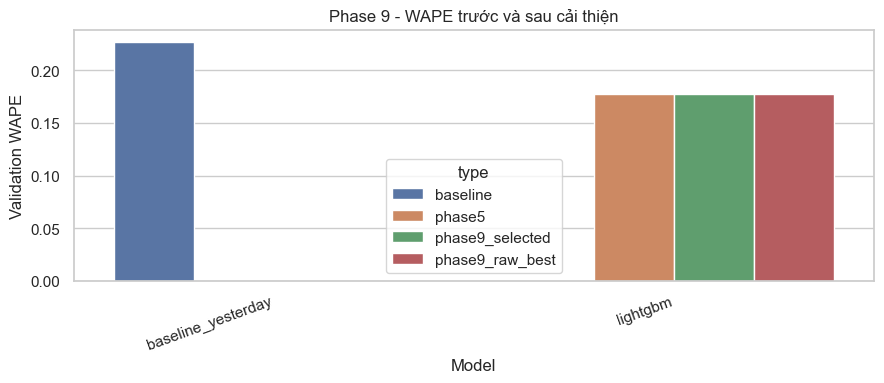

In [92]:
# Phase 9 - Cell 21 - Biểu đồ WAPE trước và sau cải thiện
plot_wape = pd.DataFrame([
    {'model': 'baseline_yesterday', 'wape': baseline_wape, 'type': 'baseline'},
    {'model': phase5_best_model_name, 'wape': phase5_best_wape, 'type': 'phase5'},
    {'model': phase9_best_model_name, 'wape': phase9_best_wape, 'type': 'phase9_selected'},
    {'model': raw_best_row['model_name'], 'wape': raw_best_row['wape'], 'type': 'phase9_raw_best'},
]).drop_duplicates(['model', 'type'])

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=plot_wape, x='model', y='wape', hue='type', ax=ax)
ax.set_title('Phase 9 - WAPE trước và sau cải thiện')
ax.set_xlabel('Model')
ax.set_ylabel('Validation WAPE')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase9_wape_before_after.png', dpi=150)
plt.show()


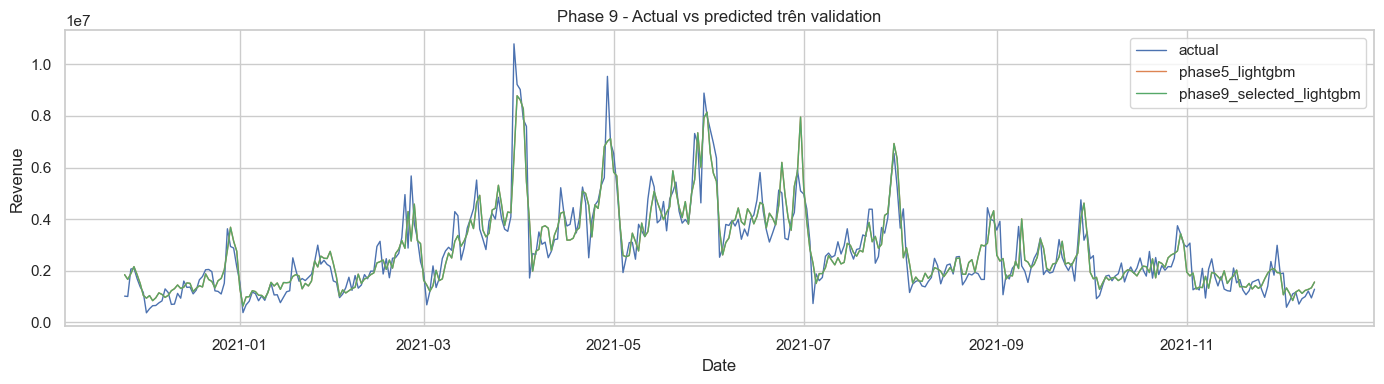

In [93]:
# Phase 9 - Cell 22 - Biểu đồ actual vs predicted trên validation
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(compare_df[DATE_COL], compare_df[TARGET_COL], label='actual', linewidth=1)
ax.plot(compare_df[DATE_COL], compare_df['phase5_best_prediction'], label=f'phase5_{phase5_best_model_name}', linewidth=1)
ax.plot(compare_df[DATE_COL], compare_df['phase9_best_prediction'], label=f'phase9_selected_{phase9_best_model_name}', linewidth=1)
ax.set_title('Phase 9 - Actual vs predicted trên validation')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase9_actual_vs_predicted.png', dpi=150)
plt.show()


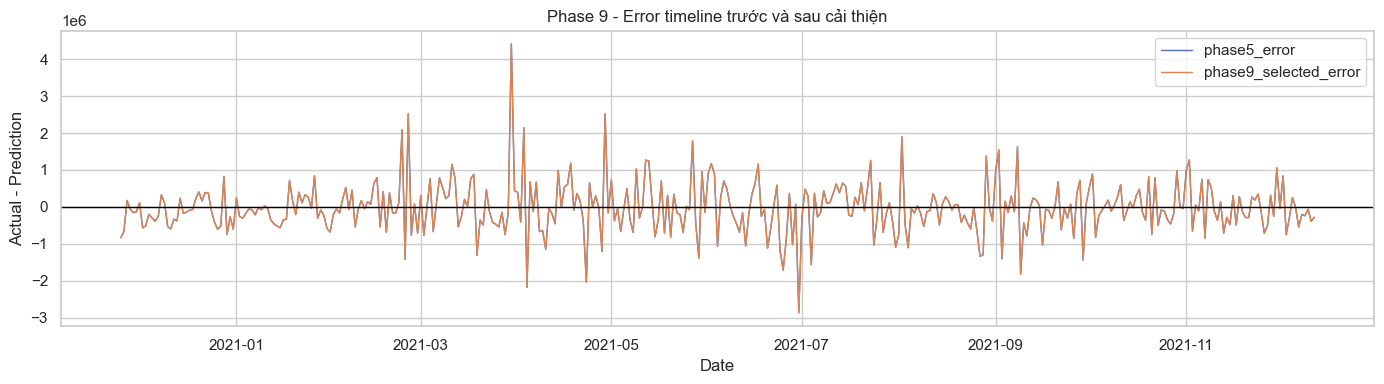

In [94]:
# Phase 9 - Cell 23 - Biểu đồ error timeline
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(compare_df[DATE_COL], compare_df['phase5_error'], label='phase5_error', linewidth=1)
ax.plot(compare_df[DATE_COL], compare_df['phase9_error'], label='phase9_selected_error', linewidth=1)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Phase 9 - Error timeline trước và sau cải thiện')
ax.set_xlabel('Date')
ax.set_ylabel('Actual - Prediction')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase9_error_timeline_before_after.png', dpi=150)
plt.show()


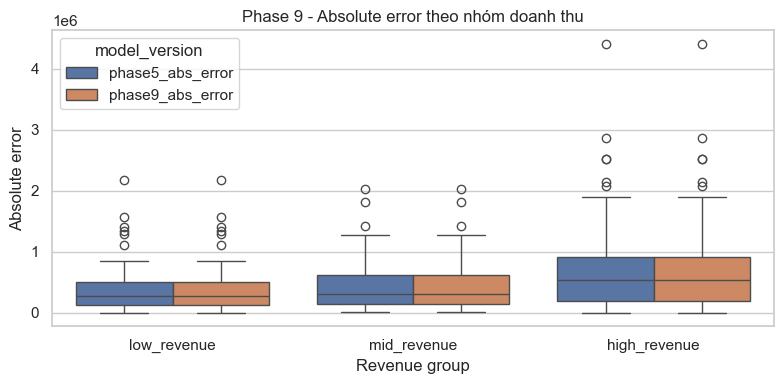

In [95]:
# Phase 9 - Cell 24 - Boxplot absolute error theo nhóm doanh thu
plot_error_group = compare_df.melt(
    id_vars=['revenue_group'],
    value_vars=['phase5_abs_error', 'phase9_abs_error'],
    var_name='model_version',
    value_name='abs_error'
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=plot_error_group, x='revenue_group', y='abs_error', hue='model_version', ax=ax)
ax.set_title('Phase 9 - Absolute error theo nhóm doanh thu')
ax.set_xlabel('Revenue group')
ax.set_ylabel('Absolute error')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase9_abs_error_by_revenue_group.png', dpi=150)
plt.show()


In [96]:
# Phase 9 - Cell 25 - Kiểm tra kết quả Phase 9
phase9_expected_tables = [
    'phase9_problem_diagnosis.csv',
    'phase9_candidate_catalog.csv',
    'phase9_tuning_results.csv',
    'phase9_improved_predictions_validation.csv',
    'phase9_improved_model_summary.csv',
    'phase9_error_comparison.csv',
    'phase9_error_by_revenue_group.csv',
    'phase9_error_by_weekday.csv',
    'phase9_calendar_rescue_comparison.csv',
]

for file_name in phase9_expected_tables:
    assert (MODEL_TABLE_DIR / file_name).exists(), f'Thiếu {file_name}'

assert 'selected_for_phase10' in phase9_tuning_results.columns, 'Thiếu cột selected_for_phase10.'
assert phase9_tuning_results['selected_for_phase10'].sum() == 1, 'Phase 9 phải chọn đúng một model cho Phase 10.'
assert int(phase9_tuning_results.loc[phase9_tuning_results['selected_for_phase10'], 'negative_prediction_count'].iloc[0]) == 0, 'Model được chọn có prediction âm trên validation.'
assert str(phase9_improved_model_summary.loc[phase9_improved_model_summary['item'] == 'selection_reason', 'value'].iloc[0]) != '', 'Thiếu lý do chọn model.'
assert 'test' not in phase9_tuning_results.columns, 'Phase 9 không được dùng test để tuning.'

phase9_done = pd.DataFrame([
    {'item': 'candidate_count', 'value': len(candidate_specs)},
    {'item': 'phase5_best_model', 'value': phase5_best_model_name},
    {'item': 'phase9_selected_model', 'value': phase9_best_model_name},
    {'item': 'raw_best_candidate', 'value': raw_best_row['model_name']},
    {'item': 'phase9_selected_feature_set', 'value': phase9_best_feature_set},
    {'item': 'phase9_selected_wape', 'value': phase9_best_wape},
    {'item': 'material_improvement', 'value': material_improvement},
    {'item': 'test_used_for_tuning', 'value': False},
])

print(phase9_done.to_string(index=False))


                       item                value
            candidate_count                    5
          phase5_best_model             lightgbm
      phase9_selected_model             lightgbm
         raw_best_candidate             lightgbm
phase9_selected_feature_set selected_features_21
       phase9_selected_wape             0.177316
       material_improvement                False
       test_used_for_tuning                False


## Kết luận Phase 9 - Cải thiện model

### 1. Phase này trả lời câu hỏi gì?

Phase 9 kiểm tra xem có thể cải thiện model tốt nhất từ Phase 5 hay không. Nguyên tắc quan trọng là chỉ tuning trên validation, không dùng test để chọn model. Test phải được giữ lại cho Phase 10 để đánh giá cuối cùng.

Phase này không chọn model mới chỉ vì metric nhích nhẹ. Với validation khoảng vài trăm ngày, một thay đổi rất nhỏ có thể chỉ là dao động tự nhiên. Vì vậy notebook đặt luật chọn model khá thận trọng.

### 2. Luật chọn model

Candidate Phase 9 chỉ được chọn nếu:

- Validation WAPE giảm ít nhất **0.003** so với model Phase 5.
- Candidate không vi phạm các kiểm tra phụ như prediction âm hoặc làm nhóm calendar/Sunday tệ hơn theo rule hiện tại.
- Candidate vẫn được giải thích rõ ràng và không dùng test trong quá trình tuning.

Ngưỡng `0.003` nghĩa là model mới phải giảm WAPE ít nhất 0.3 điểm phần trăm. Nếu cải thiện nhỏ hơn ngưỡng này, notebook giữ model Phase 5 để báo cáo trung thực.

### 3. Các hướng cải thiện đã thử

Phase 9 thử các nhóm candidate chính:

- **Reference LightGBM**: giữ đúng model tốt nhất từ Phase 5 để làm mốc so sánh.
- **Regularized LightGBM**: tăng regularization để model bớt linh hoạt, hy vọng giảm lỗi ở nhóm ngày bất thường.
- **Slow-learning LightGBM**: dùng learning rate nhỏ hơn và nhiều cây hơn, kết hợp early stopping.
- **Cyclic calendar rescue**: thêm `is_sunday`, `is_monday`, `dow_sin`, `dow_cos`, `month_sin`, `month_cos` để xử lý pattern theo tuần/tháng tốt hơn.

Các candidate này xuất phát trực tiếp từ kết luận Phase 7: Sunday và nhóm low revenue là vùng yếu, nên calendar và regularization là hai hướng hợp lý để thử trước.

### 4. WAPE early stopping được dùng như thế nào?

Với candidate có early stopping, notebook dùng WAPE làm metric dừng train để nhất quán với metric chính:

- Chia train nội bộ thành 85% đầu và 15% cuối theo thời gian.
- Train tạm trên 85% đầu.
- Đo WAPE trên 15% cuối train.
- Nếu WAPE không cải thiện sau 50 rounds, LightGBM dừng lại.
- Lấy `best_iteration` tại điểm WAPE tốt nhất.
- Refit lại model trên 100% train với `n_estimators = best_iteration`.
- Sau đó mới predict validation.

Cách này giúp early stopping không làm candidate bị thiệt vì chỉ học 85% train. Model cuối của mỗi candidate vẫn được học trên toàn bộ train trước khi so sánh validation.

### 5. Kết quả Phase 9

Kết quả thực tế là không candidate nào cải thiện validation WAPE đủ rõ so với LightGBM Phase 5:

- Model Phase 5 LightGBM có validation WAPE khoảng **17.73%**.
- Candidate tốt nhất theo bảng Phase 9 vẫn là reference `lightgbm`.
- `material_improvement = False`.
- Vì không có candidate nào giảm WAPE đủ **0.003**, Phase 9 giữ model mốc từ Phase 5.

Đây không phải thất bại của notebook. Đây là một kết luận hợp lệ: tuning đã được thử có kiểm soát, nhưng chưa tạo ra cải thiện đủ tin cậy để thay model.

### 6. Bài học từ Phase 9

Các candidate regularized/calendar có thể giúp một vài nhóm nhỏ, nhưng chưa giải quyết gốc lỗi lớn nhất: ngày doanh thu spike/drop mạnh. Những ngày này thường cần thêm tín hiệu ngoài lịch sử doanh thu, ví dụ promotion, holiday, campaign, payday, hoặc shock features.

Vì vậy hướng cải thiện tiếp theo nếu muốn giảm lỗi mạnh hơn là:

- Bổ sung feature event/promotion/holiday nếu có dữ liệu.
- Tạo shock features như khoảng cách giữa lag 1 ngày và rolling 7/28 ngày.
- Theo dõi riêng low-revenue WAPE và weekday WAPE khi chọn candidate.

Phase 10 sẽ dùng kết quả Phase 9 để chốt model cuối. Vì Phase 9 không có cải thiện đáng kể, model cuối vẫn là LightGBM Phase 5.


## Phase 10 - Chọn model cuối

### Mục tiêu

- Chọn model cuối từ kết quả Phase 9.
- Train lại model cuối trên train + validation.
- Đánh giá một lần trên test, không tuning tiếp bằng test.


In [97]:
# Phase 10 - Cell 1 - Load dữ liệu và output Phase 9
import json
from lightgbm import LGBMRegressor

train_df = pd.read_csv(MODEL_TABLE_DIR / 'modeling_train_dataset.csv', parse_dates=[DATE_COL])
validation_df = pd.read_csv(MODEL_TABLE_DIR / 'modeling_validation_dataset.csv', parse_dates=[DATE_COL])
test_df = pd.read_csv(MODEL_TABLE_DIR / 'modeling_test_dataset.csv', parse_dates=[DATE_COL])
phase9_tuning_results = pd.read_csv(MODEL_TABLE_DIR / 'phase9_tuning_results.csv')
phase9_improved_model_summary = pd.read_csv(MODEL_TABLE_DIR / 'phase9_improved_model_summary.csv')
phase4_baseline_metrics = pd.read_csv(MODEL_TABLE_DIR / 'phase4_baseline_metrics.csv')
phase4_baseline_predictions = pd.read_csv(MODEL_TABLE_DIR / 'phase4_baseline_predictions.csv', parse_dates=[DATE_COL])

print('train:', train_df.shape)
print('validation:', validation_df.shape)
print('test:', test_df.shape)


train: (2871, 24)
validation: (383, 24)
test: (384, 24)


In [98]:
# Phase 10 - Cell 2 - Đọc model được chọn từ Phase 9
phase9_summary_lookup = dict(zip(phase9_improved_model_summary['item'], phase9_improved_model_summary['value']))
final_model_name = phase9_summary_lookup['phase9_best_model']
validation_wape = float(phase9_summary_lookup['phase9_best_wape'])
final_feature_set = phase9_summary_lookup.get('phase9_best_feature_set', 'selected_features_21')

selected_phase9_rows = phase9_tuning_results[phase9_tuning_results['model_name'] == final_model_name].copy()
assert len(selected_phase9_rows) == 1, f'Không tìm thấy đúng một dòng params cho model cuối: {final_model_name}'
selected_phase9_row = selected_phase9_rows.iloc[0]

print('final_model_name:', final_model_name)
print('final_feature_set:', final_feature_set)
print('validation_wape_from_phase9:', validation_wape)


final_model_name: lightgbm
final_feature_set: selected_features_21
validation_wape_from_phase9: 0.17731573417720944


In [99]:
# Phase 10 - Cell 3 - Tạo calendar feature nếu model cuối cần
if final_feature_set == 'selected_features_cyclic_calendar':
    train_df = add_cyclic_calendar_features(train_df)
    validation_df = add_cyclic_calendar_features(validation_df)
    test_df = add_cyclic_calendar_features(test_df)
    final_selected_features = selected_features + [
        col for col in CYCLIC_CALENDAR_FEATURES if col not in selected_features
    ]
elif final_feature_set == 'selected_features_21':
    final_selected_features = selected_features.copy()
else:
    raise ValueError(f'Feature set không hỗ trợ: {final_feature_set}')

print('final_feature_count:', len(final_selected_features))


final_feature_count: 21


In [100]:
# Phase 10 - Cell 4 - Tạo train+validation và test input
train_validation_df = (
    pd.concat([train_df, validation_df], ignore_index=True)
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)

X_train_validation = train_validation_df[final_selected_features].copy()
y_train_validation = train_validation_df[TARGET_COL].copy()
X_test = test_df[final_selected_features].copy()
y_test = test_df[TARGET_COL].copy()

print('train + validation:', X_train_validation.shape)
print('test:', X_test.shape)


train + validation: (3254, 21)
test: (384, 21)


In [101]:
# Phase 10 - Cell 5 - Tạo lại model cuối từ params Phase 9
final_model_params = json.loads(selected_phase9_row['params_json'])
final_best_iteration = int(selected_phase9_row.get('best_iteration', final_model_params.get('n_estimators', 300)))

if final_best_iteration > 0:
    final_model_params['n_estimators'] = final_best_iteration

final_model = LGBMRegressor(**final_model_params)

print('Final model params dùng ở Phase 10:')
print(final_model_params)


Final model params dùng ở Phase 10:
{'n_estimators': 300, 'learning_rate': 0.05, 'random_state': 42, 'n_jobs': -1, 'verbosity': -1}


In [102]:
# Phase 10 - Cell 6 - Train final model trên train + validation
final_model.fit(X_train_validation, y_train_validation)
print(final_model)


LGBMRegressor(learning_rate=0.05, n_estimators=300, n_jobs=-1, random_state=42,
              verbosity=-1)

In [103]:
# Phase 10 - Cell 7 - Dự báo test và ghép baseline
phase10_final_model_test_predictions = test_df[[DATE_COL, TARGET_COL]].copy()
phase10_final_model_test_predictions['final_model_prediction'] = final_model.predict(X_test)

test_baseline = phase4_baseline_predictions[
    phase4_baseline_predictions['dataset'] == 'test'
][[DATE_COL, 'yesterday_baseline']].copy()
phase10_final_model_test_predictions = phase10_final_model_test_predictions.merge(test_baseline, on=DATE_COL, how='left')

print(phase10_final_model_test_predictions.head().to_string(index=False))


      Date    Revenue  final_model_prediction  yesterday_baseline
2021-12-13 1112918.62            1.374343e+06          1285064.15
2021-12-14 1821860.68            1.241871e+06          1112918.62
2021-12-15 1773908.51            1.404787e+06          1821860.68
2021-12-16 1771984.63            1.461267e+06          1773908.51
2021-12-17 1463605.82            1.684932e+06          1771984.63

In [104]:
# Phase 10 - Cell 8 - Tính lỗi trên test
phase10_final_model_test_predictions['final_model_error'] = (
    phase10_final_model_test_predictions[TARGET_COL] -
    phase10_final_model_test_predictions['final_model_prediction']
)
phase10_final_model_test_predictions['final_model_abs_error'] = phase10_final_model_test_predictions['final_model_error'].abs()
phase10_final_model_test_predictions['baseline_error'] = (
    phase10_final_model_test_predictions[TARGET_COL] -
    phase10_final_model_test_predictions['yesterday_baseline']
)
phase10_final_model_test_predictions['baseline_abs_error'] = phase10_final_model_test_predictions['baseline_error'].abs()
phase10_final_model_test_predictions['final_model_better_than_baseline'] = (
    phase10_final_model_test_predictions['final_model_abs_error'] <
    phase10_final_model_test_predictions['baseline_abs_error']
)

phase10_final_model_test_predictions.to_csv(MODEL_TABLE_DIR / 'phase10_final_model_test_predictions.csv', index=False, encoding='utf-8-sig')
print(phase10_final_model_test_predictions.head().to_string(index=False))


      Date    Revenue  final_model_prediction  yesterday_baseline  final_model_error  final_model_abs_error  baseline_error  baseline_abs_error  final_model_better_than_baseline
2021-12-13 1112918.62            1.374343e+06          1285064.15     -261424.395990          261424.395990      -172145.53           172145.53                             False
2021-12-14 1821860.68            1.241871e+06          1112918.62      579989.583238          579989.583238       708942.06           708942.06                              True
2021-12-15 1773908.51            1.404787e+06          1821860.68      369121.861186          369121.861186       -47952.17            47952.17                             False
2021-12-16 1771984.63            1.461267e+06          1773908.51      310717.449960          310717.449960        -1923.88             1923.88                             False
2021-12-17 1463605.82            1.684932e+06          1771984.63     -221325.807987          221325.807987   

In [105]:
# Phase 10 - Cell 9 - Tính metric test của final model
final_test_error = phase10_final_model_test_predictions[TARGET_COL] - phase10_final_model_test_predictions['final_model_prediction']
final_test_abs_error = final_test_error.abs()

final_test_metric_row = {
    'dataset': 'test',
    'model_type': 'final_model',
    'model_name': final_model_name,
    'row_count': len(phase10_final_model_test_predictions),
    'mae': final_test_abs_error.mean(),
    'rmse': np.sqrt((final_test_error ** 2).mean()),
    'wape': final_test_abs_error.sum() / phase10_final_model_test_predictions[TARGET_COL].sum(),
}

print(pd.DataFrame([final_test_metric_row]).to_string(index=False))


dataset  model_type model_name  row_count           mae          rmse    wape
   test final_model   lightgbm        384 549729.789368 763915.059108 0.17495


In [106]:
# Phase 10 - Cell 10 - Tạo bảng metric validation/test
metric_rows = [
    final_test_metric_row,
    {
        'dataset': 'validation',
        'model_type': 'final_model_candidate',
        'model_name': final_model_name,
        'row_count': len(validation_df),
        'mae': selected_phase9_row['mae'],
        'rmse': selected_phase9_row['rmse'],
        'wape': validation_wape,
    },
]

for dataset in ['validation', 'test']:
    row = phase4_baseline_metrics[
        (phase4_baseline_metrics['dataset'] == dataset) &
        (phase4_baseline_metrics['baseline'] == 'yesterday_baseline')
    ].iloc[0]
    metric_rows.append({
        'dataset': dataset,
        'model_type': 'baseline',
        'model_name': 'yesterday_baseline',
        'row_count': row['row_count'],
        'mae': row['mae'],
        'rmse': row['rmse'],
        'wape': row['wape'],
    })

phase10_final_model_metrics = pd.DataFrame(metric_rows).sort_values(['dataset', 'wape']).reset_index(drop=True)
phase10_final_model_metrics.to_csv(MODEL_TABLE_DIR / 'phase10_final_model_metrics.csv', index=False, encoding='utf-8-sig')
print(phase10_final_model_metrics.to_string(index=False))


   dataset            model_type         model_name  row_count           mae         rmse     wape
      test           final_model           lightgbm        384 549729.789368 7.639151e+05 0.174950
      test              baseline yesterday_baseline        384 710548.024557 1.060668e+06 0.226130
validation final_model_candidate           lightgbm        383 490332.437051 6.964900e+05 0.177316
validation              baseline yesterday_baseline        383 628529.946005 9.779895e+05 0.227291


In [107]:
# Phase 10 - Cell 11 - Lưu feature cuối cùng
phase10_final_feature_list = pd.DataFrame({
    'selected_order': range(1, len(final_selected_features) + 1),
    'feature': final_selected_features,
    'feature_set': final_feature_set,
})
phase10_final_feature_list.to_csv(MODEL_TABLE_DIR / 'phase10_final_feature_list.csv', index=False, encoding='utf-8-sig')
print(phase10_final_feature_list.to_string(index=False))


 selected_order                       feature          feature_set
              1  Gross_Profit_rolling_7d_mean selected_features_21
              2  Gross_Margin_rolling_7d_mean selected_features_21
              3      Revenue_rolling_28d_mean selected_features_21
              4                Revenue_lag_1d selected_features_21
              5         Revenue_pct_change_7d selected_features_21
              6            page_views_lag_14d selected_features_21
              7                     cos_month selected_features_21
              8 Gross_Profit_rolling_28d_mean selected_features_21
              9                          year selected_features_21
             10                is_month_start selected_features_21
             11       Revenue_rolling_7d_mean selected_features_21
             12 Gross_Margin_rolling_28d_mean selected_features_21
             13           Gross_Margin_lag_7d selected_features_21
             14           Gross_Margin_lag_1d selected_feature

In [108]:
# Phase 10 - Cell 12 - Tạo summary model cuối
final_test_wape = phase10_final_model_metrics[
    (phase10_final_model_metrics['dataset'] == 'test') &
    (phase10_final_model_metrics['model_type'] == 'final_model')
]['wape'].iloc[0]
final_test_mae = phase10_final_model_metrics[
    (phase10_final_model_metrics['dataset'] == 'test') &
    (phase10_final_model_metrics['model_type'] == 'final_model')
]['mae'].iloc[0]
baseline_test_wape = phase10_final_model_metrics[
    (phase10_final_model_metrics['dataset'] == 'test') &
    (phase10_final_model_metrics['model_type'] == 'baseline')
]['wape'].iloc[0]

negative_prediction_count = int((phase10_final_model_test_predictions['final_model_prediction'] < 0).sum())
std_ratio_pred_vs_actual = phase10_final_model_test_predictions['final_model_prediction'].std() / phase10_final_model_test_predictions[TARGET_COL].std()
test_win_rate_vs_baseline = phase10_final_model_test_predictions['final_model_better_than_baseline'].mean()
validation_test_wape_gap = final_test_wape - validation_wape
material_improvement_report = str(phase9_summary_lookup.get('material_improvement', False)).lower() == 'true'
selection_reason_report = phase9_summary_lookup.get('selection_reason', '')

phase10_final_model_summary = pd.DataFrame([
    {'item': 'final_model', 'value': final_model_name},
    {'item': 'training_data_used', 'value': 'train + validation'},
    {'item': 'test_used_for_tuning', 'value': False},
    {'item': 'selected_feature_count', 'value': len(final_selected_features)},
    {'item': 'final_feature_set', 'value': final_feature_set},
    {'item': 'phase9_material_improvement', 'value': material_improvement_report},
    {'item': 'phase9_selection_reason', 'value': selection_reason_report},
    {'item': 'validation_wape', 'value': validation_wape},
    {'item': 'test_wape', 'value': final_test_wape},
    {'item': 'test_mae', 'value': final_test_mae},
    {'item': 'baseline_test_wape', 'value': baseline_test_wape},
    {'item': 'beats_baseline_on_test', 'value': bool(final_test_wape < baseline_test_wape)},
    {'item': 'wape_gap_test_minus_validation', 'value': validation_test_wape_gap},
    {'item': 'negative_prediction_count', 'value': negative_prediction_count},
    {'item': 'std_ratio_pred_vs_actual', 'value': std_ratio_pred_vs_actual},
    {'item': 'test_win_rate_vs_baseline', 'value': test_win_rate_vs_baseline},
    {'item': 'strength', 'value': 'Được chọn bằng validation và kiểm tra một lần trên test.'},
    {'item': 'weakness', 'value': 'Vẫn có thể sai mạnh ở các ngày doanh thu biến động bất thường; Phase 9 không nhận cải thiện nhỏ là cải thiện thật.'},
    {'item': 'remaining_risk', 'value': 'Cần theo dõi distribution shift giữa train, validation và test khi báo cáo.'},
])

phase10_final_model_summary.to_csv(MODEL_TABLE_DIR / 'phase10_final_model_summary.csv', index=False, encoding='utf-8-sig')
print(phase10_final_model_summary.to_string(index=False))


                          item                                                                                                              value
                   final_model                                                                                                           lightgbm
            training_data_used                                                                                                 train + validation
          test_used_for_tuning                                                                                                              False
        selected_feature_count                                                                                                                 21
             final_feature_set                                                                                               selected_features_21
   phase9_material_improvement                                                                                              

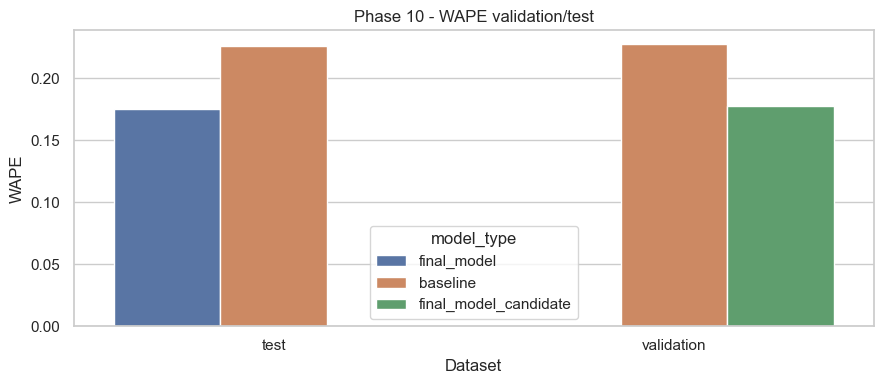

In [109]:
# Phase 10 - Cell 13 - Biểu đồ metric validation/test
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=phase10_final_model_metrics, x='dataset', y='wape', hue='model_type', ax=ax)
ax.set_title('Phase 10 - WAPE validation/test')
ax.set_xlabel('Dataset')
ax.set_ylabel('WAPE')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase10_wape_validation_test.png', dpi=150)
plt.show()


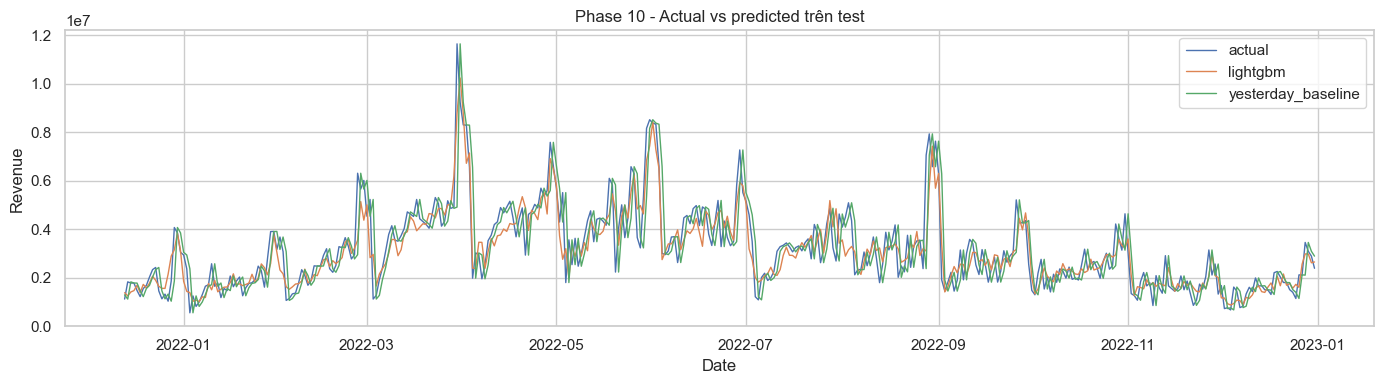

In [110]:
# Phase 10 - Cell 14 - Actual vs predicted trên test
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(phase10_final_model_test_predictions[DATE_COL], phase10_final_model_test_predictions[TARGET_COL], label='actual', linewidth=1)
ax.plot(phase10_final_model_test_predictions[DATE_COL], phase10_final_model_test_predictions['final_model_prediction'], label=final_model_name, linewidth=1)
ax.plot(phase10_final_model_test_predictions[DATE_COL], phase10_final_model_test_predictions['yesterday_baseline'], label='yesterday_baseline', linewidth=1)
ax.set_title('Phase 10 - Actual vs predicted trên test')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase10_actual_vs_predicted_test.png', dpi=150)
plt.show()


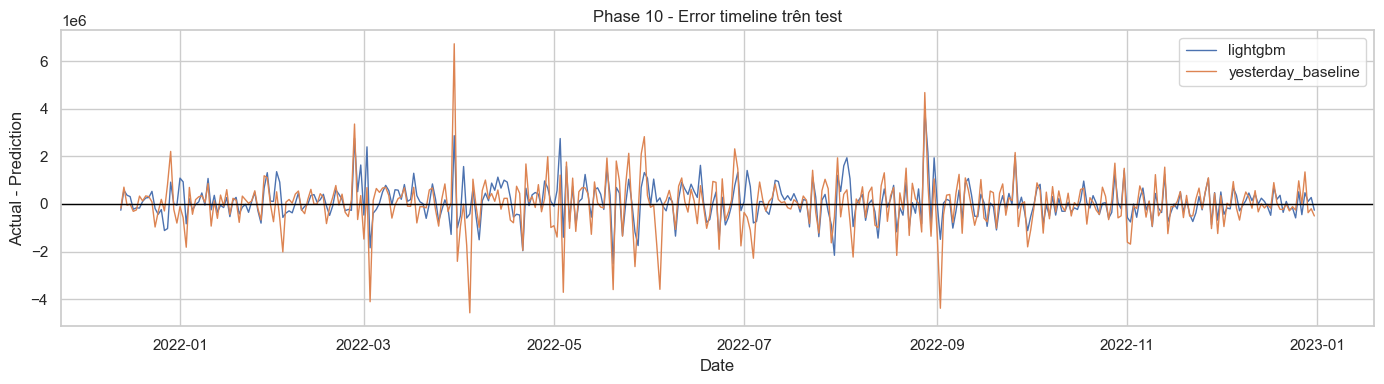

In [111]:
# Phase 10 - Cell 15 - Error timeline trên test
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(phase10_final_model_test_predictions[DATE_COL], phase10_final_model_test_predictions['final_model_error'], label=final_model_name, linewidth=1)
ax.plot(phase10_final_model_test_predictions[DATE_COL], phase10_final_model_test_predictions['baseline_error'], label='yesterday_baseline', linewidth=1)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Phase 10 - Error timeline trên test')
ax.set_xlabel('Date')
ax.set_ylabel('Actual - Prediction')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase10_error_timeline_test.png', dpi=150)
plt.show()


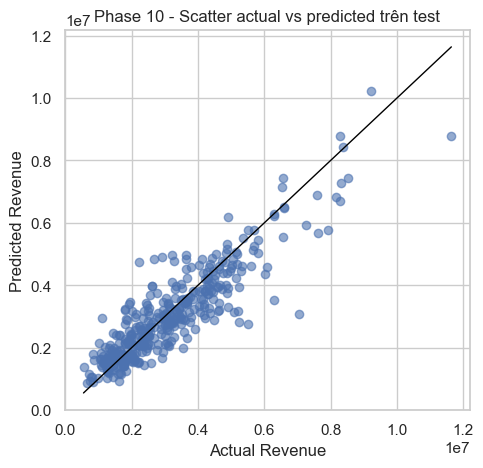

In [112]:
# Phase 10 - Cell 16 - Scatter actual vs predicted trên test
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(phase10_final_model_test_predictions[TARGET_COL], phase10_final_model_test_predictions['final_model_prediction'], alpha=0.6)
min_value = min(phase10_final_model_test_predictions[TARGET_COL].min(), phase10_final_model_test_predictions['final_model_prediction'].min())
max_value = max(phase10_final_model_test_predictions[TARGET_COL].max(), phase10_final_model_test_predictions['final_model_prediction'].max())
ax.plot([min_value, max_value], [min_value, max_value], color='black', linewidth=1)
ax.set_title('Phase 10 - Scatter actual vs predicted trên test')
ax.set_xlabel('Actual Revenue')
ax.set_ylabel('Predicted Revenue')
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase10_scatter_actual_predicted_test.png', dpi=150)
plt.show()


In [113]:
# Phase 10 - Cell 17 - Kiểm tra kết quả Phase 10
assert (MODEL_TABLE_DIR / 'phase10_final_model_test_predictions.csv').exists(), 'Thiếu phase10_final_model_test_predictions.csv'
assert (MODEL_TABLE_DIR / 'phase10_final_model_metrics.csv').exists(), 'Thiếu phase10_final_model_metrics.csv'
assert (MODEL_TABLE_DIR / 'phase10_final_feature_list.csv').exists(), 'Thiếu phase10_final_feature_list.csv'
assert (MODEL_TABLE_DIR / 'phase10_final_model_summary.csv').exists(), 'Thiếu phase10_final_model_summary.csv'
assert negative_prediction_count == 0, 'Model cuối có prediction âm trên test.'
assert len(phase10_final_feature_list) == len(final_selected_features), 'Final feature list không khớp feature set của model cuối.'
assert str(phase10_final_model_summary.loc[phase10_final_model_summary['item'] == 'test_used_for_tuning', 'value'].iloc[0]).lower() == 'false', 'Test không được dùng để tuning.'

phase10_done = pd.DataFrame([
    {'item': 'final_model', 'value': final_model_name},
    {'item': 'final_feature_set', 'value': final_feature_set},
    {'item': 'final_feature_count', 'value': len(final_selected_features)},
    {'item': 'test_wape', 'value': final_test_wape},
    {'item': 'baseline_test_wape', 'value': baseline_test_wape},
    {'item': 'beats_baseline_on_test', 'value': bool(final_test_wape < baseline_test_wape)},
    {'item': 'test_used_for_tuning', 'value': False},
])

print(phase10_done.to_string(index=False))


                  item                value
           final_model             lightgbm
     final_feature_set selected_features_21
   final_feature_count                   21
             test_wape              0.17495
    baseline_test_wape              0.22613
beats_baseline_on_test                 True
  test_used_for_tuning                False


## Kết luận Phase 10 - Chọn model cuối

### 1. Phase này trả lời câu hỏi gì?

Phase 10 là bước chốt model cuối để báo cáo. Đến phase này, notebook không tuning thêm nữa. Mục tiêu là lấy model đã được chọn bằng validation, train lại trên nhiều dữ liệu hơn, rồi đánh giá đúng một lần trên test.

Test set chỉ được dùng một lần vì test đại diện cho dữ liệu tương lai chưa thấy. Nếu dùng test để chọn hyperparameter hoặc chọn model, kết quả test sẽ không còn là đánh giá khách quan nữa.

### 2. Model cuối là gì?

Model cuối là **LightGBM** với **21 selected features**.

Vì Phase 9 không tìm được candidate cải thiện đủ rõ, notebook giữ model mốc từ Phase 5. Sau đó model được train lại trên **train + validation** để tận dụng nhiều dữ liệu lịch sử hơn trước khi dự báo test.

### 3. Kết quả validation và test

Các metric chính:

- Validation WAPE của final candidate: **17.73%**.
- Test WAPE của final model: **17.50%**.
- Baseline `yesterday_baseline` trên test: **22.61%** WAPE.
- Test MAE của final model khoảng **549,730/ngày**.
- Model không có prediction âm trên test.
- `test_used_for_tuning = False`.

Điều này cho thấy model cuối tốt hơn baseline rõ ràng trên test. Chênh lệch WAPE giữa test và validation còn hơi tốt hơn trên test, nên chưa thấy dấu hiệu overfit rõ từ validation sang test.

### 4. Ý nghĩa kinh doanh

WAPE test **17.50%** có thể hiểu đơn giản là: tổng sai số tuyệt đối của model trên giai đoạn test bằng khoảng 17.50% tổng doanh thu thực tế của giai đoạn đó.

So với baseline **22.61%**, model giúp giảm khoảng **5.12 điểm phần trăm WAPE**. Đây là cải thiện có ý nghĩa vì baseline đã là một cách dự báo hợp lý cho time series ngắn hạn: lấy doanh thu ngày hôm trước.

### 5. Vì sao không chọn model khác ở Phase 10?

Phase 10 không chọn lại model bằng test. Quyết định model đã được đưa ra ở Phase 9 bằng validation. Test chỉ trả lời câu hỏi: model đã chọn có hoạt động ổn trên giai đoạn tương lai không?

Kết quả test cho thấy câu trả lời là có: final model vẫn thắng baseline và test WAPE không xấu hơn validation WAPE.

### 6. Rủi ro còn lại

Model vẫn có một hạn chế quan trọng: prediction có xu hướng mượt hơn thực tế. `std_ratio_pred_vs_actual` trên test khoảng **0.873**, nghĩa là độ biến động của prediction thấp hơn độ biến động của Revenue thật.

Nói cách khác, model dự báo mức trung bình và pattern thường ngày khá ổn, nhưng vẫn có thể chưa bắt tốt các ngày tăng/giảm đột biến. Đây cũng khớp với kết luận Phase 7-9.

Nếu tiếp tục cải thiện sau Phase 10, ưu tiên không nên là tuning nhỏ thêm, mà nên bổ sung feature giải thích biến động bất thường như promotion, holiday, campaign, payday hoặc shock features.


## Phase 11 - Chuẩn bị báo cáo model

### Mục tiêu

- Tổng hợp output Phase 1-10 thành bảng và biểu đồ dùng trực tiếp cho báo cáo.
- Không train lại, không tuning, không chọn lại model.
- Nhắc rõ test set chỉ được dùng một lần ở Phase 10.


In [114]:
# Phase 11 - Cell 1 - Load input báo cáo
phase11_required_files = {
    'phase1_problem_definition': MODEL_TABLE_DIR / 'phase1_problem_definition.csv',
    'phase3_split_summary': MODEL_TABLE_DIR / 'phase3_split_summary.csv',
    'phase4_best_baseline_summary': MODEL_TABLE_DIR / 'phase4_best_baseline_summary.csv',
    'phase6_metric_policy': MODEL_TABLE_DIR / 'phase6_metric_policy.csv',
    'phase8_feature_importance': MODEL_TABLE_DIR / 'phase8_feature_importance.csv',
    'phase9_improved_model_summary': MODEL_TABLE_DIR / 'phase9_improved_model_summary.csv',
    'phase10_final_model_metrics': MODEL_TABLE_DIR / 'phase10_final_model_metrics.csv',
    'phase10_final_feature_list': MODEL_TABLE_DIR / 'phase10_final_feature_list.csv',
    'phase10_final_model_summary': MODEL_TABLE_DIR / 'phase10_final_model_summary.csv',
}
missing_phase11_inputs = [name for name, path in phase11_required_files.items() if not path.exists()]
assert not missing_phase11_inputs, f'Missing Phase 11 inputs: {missing_phase11_inputs}'

phase1_problem_definition = pd.read_csv(phase11_required_files['phase1_problem_definition'])
phase3_split_summary = pd.read_csv(phase11_required_files['phase3_split_summary'])
phase4_best_baseline_summary = pd.read_csv(phase11_required_files['phase4_best_baseline_summary'])
phase6_metric_policy = pd.read_csv(phase11_required_files['phase6_metric_policy'])
phase8_feature_importance = pd.read_csv(phase11_required_files['phase8_feature_importance'])
phase9_improved_model_summary = pd.read_csv(phase11_required_files['phase9_improved_model_summary'])
phase10_final_model_metrics = pd.read_csv(phase11_required_files['phase10_final_model_metrics'])
phase10_final_feature_list = pd.read_csv(phase11_required_files['phase10_final_feature_list'])
phase10_final_model_summary = pd.read_csv(phase11_required_files['phase10_final_model_summary'])

def lookup_item(df, item, default=None):
    match = df.loc[df['item'] == item, 'value']
    return match.iloc[0] if len(match) else default

metric_main = phase6_metric_policy.loc[phase6_metric_policy['role'] == 'main', 'metric'].iloc[0]
baseline_model_name_report = lookup_item(phase4_best_baseline_summary, 'best_baseline_by_validation_wape', 'yesterday_baseline')
final_model_name_report = lookup_item(phase10_final_model_summary, 'final_model')
final_feature_count_report = int(lookup_item(phase10_final_model_summary, 'selected_feature_count', len(phase10_final_feature_list)))

print('metric_main:', metric_main)
print('baseline:', baseline_model_name_report)
print('final_model:', final_model_name_report)
print('final_feature_count:', final_feature_count_report)


metric_main: WAPE
baseline: yesterday_baseline
final_model: lightgbm
final_feature_count: 21


In [115]:
# Phase 11 - Cell 2 - Tạo bảng metric báo cáo
phase11_metric_report_table = phase10_final_model_metrics.copy()
phase11_metric_report_table['wape_pct'] = phase11_metric_report_table['wape'] * 100
phase11_metric_report_table['mae_rounded'] = phase11_metric_report_table['mae'].round(2)
phase11_metric_report_table['rmse_rounded'] = phase11_metric_report_table['rmse'].round(2)
phase11_metric_report_table.to_csv(MODEL_TABLE_DIR / 'phase11_metric_report_table.csv', index=False, encoding='utf-8-sig')

final_test_metric = phase10_final_model_metrics[
    (phase10_final_model_metrics['dataset'] == 'test') &
    (phase10_final_model_metrics['model_type'] == 'final_model')
].iloc[0]
baseline_test_metric = phase10_final_model_metrics[
    (phase10_final_model_metrics['dataset'] == 'test') &
    (phase10_final_model_metrics['model_type'] == 'baseline')
].iloc[0]
final_validation_metric = phase10_final_model_metrics[
    (phase10_final_model_metrics['dataset'] == 'validation') &
    (phase10_final_model_metrics['model_type'].str.contains('final_model'))
].iloc[0]
baseline_validation_metric = phase10_final_model_metrics[
    (phase10_final_model_metrics['dataset'] == 'validation') &
    (phase10_final_model_metrics['model_type'] == 'baseline')
].iloc[0]

print(phase11_metric_report_table.to_string(index=False))


   dataset            model_type         model_name  row_count           mae         rmse     wape  wape_pct  mae_rounded  rmse_rounded
      test           final_model           lightgbm        384 549729.789368 7.639151e+05 0.174950 17.495016    549729.79     763915.06
      test              baseline yesterday_baseline        384 710548.024557 1.060668e+06 0.226130 22.613018    710548.02    1060668.39
validation final_model_candidate           lightgbm        383 490332.437051 6.964900e+05 0.177316 17.731573    490332.44     696490.05
validation              baseline yesterday_baseline        383 628529.946005 9.779895e+05 0.227291 22.729120    628529.95     977989.45


In [116]:
# Phase 11 - Cell 3 - Tạo bảng summary model báo cáo
split_summary_text = '; '.join(
    f"{row.dataset}: {row.actual_start} to {row.actual_end} ({row.row_count} rows)"
    for row in phase3_split_summary.itertuples(index=False)
)
test_wape_improvement = baseline_test_metric['wape'] - final_test_metric['wape']
test_wape_improvement_pct_vs_baseline = test_wape_improvement / baseline_test_metric['wape'] * 100

phase11_model_report_summary = pd.DataFrame([
    {'item': 'business_goal', 'value': lookup_item(phase1_problem_definition, 'business_goal')},
    {'item': 'problem_type', 'value': lookup_item(phase1_problem_definition, 'problem_type')},
    {'item': 'target', 'value': lookup_item(phase1_problem_definition, 'target')},
    {'item': 'grain', 'value': lookup_item(phase1_problem_definition, 'grain')},
    {'item': 'split_summary', 'value': split_summary_text},
    {'item': 'baseline_model', 'value': baseline_model_name_report},
    {'item': 'final_model', 'value': final_model_name_report},
    {'item': 'final_feature_count', 'value': final_feature_count_report},
    {'item': 'main_metric', 'value': metric_main},
    {'item': 'validation_wape_final_model', 'value': final_validation_metric['wape']},
    {'item': 'validation_wape_baseline', 'value': baseline_validation_metric['wape']},
    {'item': 'test_wape_final_model', 'value': final_test_metric['wape']},
    {'item': 'test_wape_baseline', 'value': baseline_test_metric['wape']},
    {'item': 'test_wape_improvement_abs', 'value': test_wape_improvement},
    {'item': 'test_wape_improvement_pct_vs_baseline', 'value': test_wape_improvement_pct_vs_baseline},
    {'item': 'test_mae_final_model', 'value': final_test_metric['mae']},
    {'item': 'test_rmse_final_model', 'value': final_test_metric['rmse']},
    {'item': 'beats_baseline_on_test', 'value': bool(final_test_metric['wape'] < baseline_test_metric['wape'])},
    {'item': 'test_used_for_tuning', 'value': False},
    {'item': 'strength', 'value': lookup_item(phase10_final_model_summary, 'strength')},
    {'item': 'weakness', 'value': lookup_item(phase10_final_model_summary, 'weakness')},
    {'item': 'remaining_risk', 'value': lookup_item(phase10_final_model_summary, 'remaining_risk')},
])
phase11_model_report_summary.to_csv(MODEL_TABLE_DIR / 'phase11_model_report_summary.csv', index=False, encoding='utf-8-sig')
print(phase11_model_report_summary.to_string(index=False))


                                 item                                                                                                                                   value
                        business_goal                                                                                                              Dự báo doanh thu theo ngày
                         problem_type                                                                                                                              Regression
                               target                                                                                                                                 Revenue
                                grain                                                                                                                         1 dòng = 1 ngày
                        split_summary train: 2013-01-15 to 2020-11-24 (2871 rows); validation: 2020-11-25 to 2021-12-12 (383 rows)

In [117]:
# Phase 11 - Cell 4 - Tạo bảng feature importance báo cáo
phase11_feature_report_table = phase8_feature_importance.head(10).merge(
    phase10_final_feature_list[['feature', 'feature_set']],
    on='feature',
    how='left'
)
phase11_feature_report_table['in_final_feature_list'] = phase11_feature_report_table['feature_set'].notna()
phase11_feature_report_table.to_csv(MODEL_TABLE_DIR / 'phase11_feature_report_table.csv', index=False, encoding='utf-8-sig')
print(phase11_feature_report_table.to_string(index=False))


                      feature  importance  importance_share  rank          feature_set  in_final_feature_list
                 day_of_month         914          0.101556     1 selected_features_21                   True
        Revenue_pct_change_7d         800          0.088889     2 selected_features_21                   True
               Revenue_lag_1d         712          0.079111     3 selected_features_21                   True
              Revenue_lag_28d         687          0.076333     4 selected_features_21                   True
              Revenue_diff_1d         620          0.068889     5 selected_features_21                   True
          Gross_Profit_lag_1d         502          0.055778     6 selected_features_21                   True
           page_views_lag_14d         486          0.054000     7 selected_features_21                   True
     Revenue_rolling_28d_mean         478          0.053111     8 selected_features_21                   True
Gross_Marg

In [118]:
# Phase 11 - Cell 5 - Tạo kết luận ngắn cho báo cáo
phase11_report_conclusion = pd.DataFrame([
    {
        'section': 'performance',
        'text': (
            f"Final model {final_model_name_report} reached test WAPE {final_test_metric['wape'] * 100:.2f}%, "
            f"baseline {baseline_model_name_report} reached {baseline_test_metric['wape'] * 100:.2f}%, "
            f"improving {test_wape_improvement_pct_vs_baseline:.2f}% versus baseline."
        ),
    },
    {
        'section': 'model_selection',
        'text': 'The final model was selected using validation; the test set was used once in Phase 10 for final evaluation.',
    },
    {'section': 'strength', 'text': str(lookup_item(phase10_final_model_summary, 'strength'))},
    {'section': 'weakness', 'text': str(lookup_item(phase10_final_model_summary, 'weakness'))},
    {'section': 'remaining_risk', 'text': str(lookup_item(phase10_final_model_summary, 'remaining_risk'))},
])
phase11_report_conclusion.to_csv(MODEL_TABLE_DIR / 'phase11_report_conclusion.csv', index=False, encoding='utf-8-sig')
print(phase11_report_conclusion.to_string(index=False))


        section                                                                                                                         text
    performance Final model lightgbm reached test WAPE 17.50%, baseline yesterday_baseline reached 22.61%, improving 22.63% versus baseline.
model_selection                  The final model was selected using validation; the test set was used once in Phase 10 for final evaluation.
       strength                                                                     Được chọn bằng validation và kiểm tra một lần trên test.
       weakness           Vẫn có thể sai mạnh ở các ngày doanh thu biến động bất thường; Phase 9 không nhận cải thiện nhỏ là cải thiện thật.
 remaining_risk                                                  Cần theo dõi distribution shift giữa train, validation và test khi báo cáo.


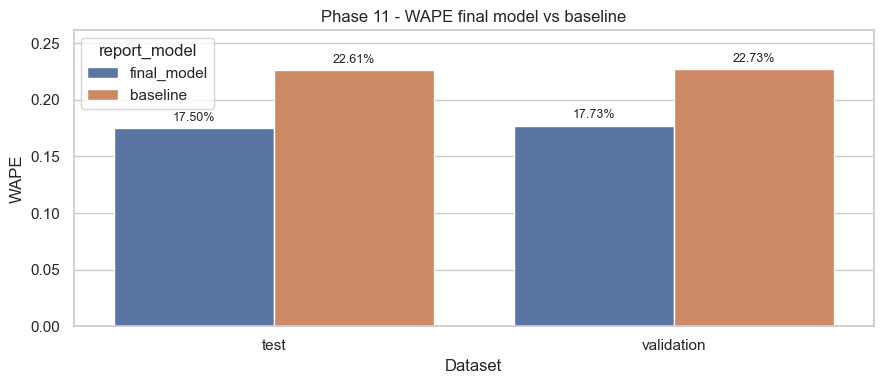

In [119]:
# Phase 11 - Cell 6 - Biểu đồ WAPE final model vs baseline
plot_metric = phase11_metric_report_table.copy()
plot_metric['report_model'] = np.where(plot_metric['model_type'] == 'baseline', 'baseline', 'final_model')
plot_metric = plot_metric[plot_metric['dataset'].isin(['validation', 'test'])].copy()

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=plot_metric, x='dataset', y='wape', hue='report_model', ax=ax)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{bar.get_height() * 100:.2f}%' if np.isfinite(bar.get_height()) else '' for bar in container],
        padding=3,
        fontsize=9,
    )
ax.set_title('Phase 11 - WAPE final model vs baseline')
ax.set_xlabel('Dataset')
ax.set_ylabel('WAPE')
ax.margins(y=0.15)
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase11_metric_summary.png', dpi=150)
plt.show()


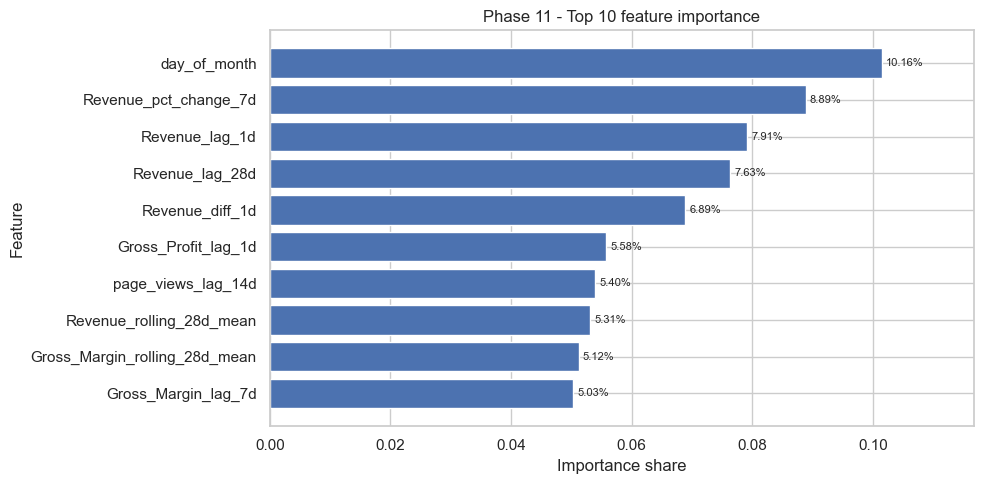

In [120]:
# Phase 11 - Cell 7 - Biểu đồ top 10 feature importance
plot_features = phase11_feature_report_table.sort_values('importance_share')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(plot_features['feature'], plot_features['importance_share'])
ax.bar_label(bars, labels=[f'{v * 100:.2f}%' for v in plot_features['importance_share']], padding=3, fontsize=8)
ax.set_title('Phase 11 - Top 10 feature importance')
ax.set_xlabel('Importance share')
ax.set_ylabel('Feature')
ax.margins(x=0.15)
plt.tight_layout()
plt.savefig(MODEL_FIG_DIR / 'phase11_top_feature_importance.png', dpi=150)
plt.show()


In [121]:
# Phase 11 - Cell 8 - Pipeline overview cho báo cáo
phase11_pipeline_overview = pd.DataFrame([
    {'phase': '0', 'name': 'Setup', 'report_message': 'Import libraries and load feature engineering input.'},
    {'phase': '1', 'name': 'Problem definition', 'report_message': 'Define Revenue target, daily grain, and feature set.'},
    {'phase': '2', 'name': 'Modeling table', 'report_message': 'Create clean modeling table and handle missing values.'},
    {'phase': '3', 'name': 'Time split', 'report_message': 'Split train/validation/test by time.'},
    {'phase': '4', 'name': 'Baseline', 'report_message': f'Use {baseline_model_name_report} as comparison baseline.'},
    {'phase': '5', 'name': 'Initial ML model', 'report_message': 'Train initial ML model on train and evaluate validation.'},
    {'phase': '6', 'name': 'Metric policy', 'report_message': f'Use {metric_main} as the main metric.'},
    {'phase': '7', 'name': 'Error analysis', 'report_message': 'Analyze top errors by time, weekday, and revenue group.'},
    {'phase': '8', 'name': 'Model explanation', 'report_message': 'Explain model using feature importance.'},
    {'phase': '9', 'name': 'Improvement', 'report_message': 'Tune LightGBM and test calendar rescue on validation.'},
    {'phase': '10', 'name': 'Final evaluation', 'report_message': 'Train final model and evaluate test once.'},
])
phase11_pipeline_overview.to_csv(MODEL_TABLE_DIR / 'phase11_pipeline_overview.csv', index=False, encoding='utf-8-sig')

display(phase11_pipeline_overview)


,phase,name,report_message
0,0,Setup,Import libraries and load feature engineering ...
1,1,Problem definition,"Define Revenue target, daily grain, and featur..."
2,2,Modeling table,Create clean modeling table and handle missing...
3,3,Time split,Split train/validation/test by time.
4,4,Baseline,Use yesterday_baseline as comparison baseline.
5,5,Initial ML model,Train initial ML model on train and evaluate v...
6,6,Metric policy,Use WAPE as the main metric.
7,7,Error analysis,"Analyze top errors by time, weekday, and reven..."
8,8,Model explanation,Explain model using feature importance.
9,9,Improvement,Tune LightGBM and test calendar rescue on vali...


In [122]:
# Phase 11 - Cell 9 - Kiểm tra kết quả Phase 11
phase11_expected_tables = [
    'phase11_model_report_summary.csv',
    'phase11_metric_report_table.csv',
    'phase11_feature_report_table.csv',
    'phase11_report_conclusion.csv',
    'phase11_pipeline_overview.csv',
]
phase11_expected_figures = [
    'phase11_metric_summary.png',
    'phase11_top_feature_importance.png',
]

for file_name in phase11_expected_tables:
    assert (MODEL_TABLE_DIR / file_name).exists(), f'Missing {file_name}'
for file_name in phase11_expected_figures:
    assert (MODEL_FIG_DIR / file_name).exists(), f'Missing {file_name}'

assert {'final_model', 'baseline'} <= set(plot_metric['report_model']), 'Metric report is missing final_model or baseline.'
assert str(phase11_model_report_summary.loc[phase11_model_report_summary['item'] == 'test_used_for_tuning', 'value'].iloc[0]).lower() == 'false', 'Phase 11 must not use test for tuning.'

phase11_done = pd.DataFrame([
    {'item': 'report_tables', 'value': len(phase11_expected_tables)},
    {'item': 'report_figures', 'value': len(phase11_expected_figures)},
    {'item': 'final_model', 'value': final_model_name_report},
    {'item': 'baseline_model', 'value': baseline_model_name_report},
    {'item': 'test_wape_final_model', 'value': final_test_metric['wape']},
    {'item': 'test_wape_baseline', 'value': baseline_test_metric['wape']},
])
print(phase11_done.to_string(index=False))


                 item              value
        report_tables                  5
       report_figures                  2
          final_model           lightgbm
       baseline_model yesterday_baseline
test_wape_final_model            0.17495
   test_wape_baseline            0.22613


## Kết luận Phase 11

- Phase 11 đã tạo các bảng và biểu đồ dùng trực tiếp cho báo cáo model.
- Final model, test WAPE, baseline WAPE và mức cải thiện được lấy từ `phase10_final_model_metrics.csv` sau khi chạy lại Phase 10.
- Các output chính gồm bảng summary, bảng metric, bảng top feature, kết luận ngắn, pipeline overview dạng table và 2 biểu đồ báo cáo.
- Điểm mạnh: model được chọn bằng validation và test chỉ dùng một lần ở Phase 10.
- Rủi ro còn lại: model vẫn có thể sai mạnh ở các ngày doanh thu biến động bất thường hoặc khi distribution shift.


## Completed modeling notebook through Phase 11

- Phase 0 setup and loaded feature engineering input.
- Phase 1 defined the problem, target, grain, feature set, and split plan.
- Phase 2 created the clean modeling table and handled missing values.
- Phase 3 split train/validation/test by time.
- Phase 4 built baseline models.
- Phase 5 trained the initial ML model on validation.
- Phase 6 selected WAPE as the main metric.
- Phase 7 analyzed best model errors on validation.
- Phase 8 explained the model using feature importance.
- Phase 9 tuned the model on validation.
- Phase 10 selected the final model and evaluated test once.
- Phase 11 prepared report-ready tables and figures.
